In [ ]:
# path guard: run from the repo root even if this notebook is opened inside experiments/
import os
if os.path.basename(os.getcwd()) == "experiments":
    os.chdir("..")



> **This notebook is dedicated to the `ts_actions_observations` dataset** -- a different, more complex task, not a win-stay/lose-shift variant. It's a sibling to `fsc_tinyrnn_pipeline.ipynb`, sharing the same setup and core pipeline (through §9), but starting its own findings/comparison sections from §10 onward, and its own `fitted_models_ts/` results tree -- kept separate on purpose, since this task has nothing in common with the WSLS family beyond the fitting machinery. The task itself isn't fully understood yet; §1 loads the raw data without assuming what it means.
# FSC ↔ tinyRNN pipeline

Two independent ways of extracting a **minimal, interpretable model of decision-making**
from the same behavioral data:

1. **Finite State Controller (FSC)** — Nicoletti & Celani, *"Decoding behavior with
   minimal and interpretable agent models"* (2026). A discrete-state controller fit by
   MAPSO (particle-swarm) + gradient descent.
   Code: [`FSC-inference-MAPSO`](https://github.com/giorgionicoletti/FSC-inference-MAPSO)
2. **tinyRNN** — Ji-An, Benna & Mattar, *"Discovering cognitive strategies with tiny
   recurrent neural networks"* (Nature, 2025). A small GRU trained with the paper's
   official nested cross-validation procedure to find the smallest RNN that explains
   the behavior.
   Code: [`tinyRNN`](https://github.com/cgc/tinyRNN)

## A note on fidelity
Both repos are vendored (git-cloned) rather than reimplemented, and the training /
inference calls below follow the authors' own example notebooks / experiment scripts
as closely as possible, so that nothing about *how* the models are fit is invented here.


- **Everything from Section 4 on** is analysis code we write ourselves, organised by
  question rather than by model: each section asks one thing and answers it for the FSC and
  the RNN side by side.
  Where it touches the FSC's internal dynamics (the belief-state decoder), it is a
  direct implementation of the same forward-filtering recursion the library itself
  computes inside `inference.loss` (see Section 4.1), not a new model.

## Reproducibility — how someone else runs this
The two upstream repos are **not** committed to this project's repo; Section 0 `git clone`s
them fresh (`--depth 1`) into `FSC-inference-MAPSO/` and `tinyRNN/`. So a fresh checkout of
this project is just the notebook, the `wsls_actions_observations.npz` data, and the
`fitted_models/` artifacts — you run Section 0 once and the libraries appear locally.

The **only** modifications made to those cloned libraries are two automated patches that
Section 0 applies itself (idempotently) each run:
1. `path_settings.py` — replace the upstream hardcoded Windows `MODEL_SAVE_PATH` with a
   local relative path, so the notebook is portable.
2. `datasets/SimpleDataset.py` — a one-line upstream bug fix for variable-length sessions.

Because both patches live in the notebook (not hand-edits made outside it), a fresh clone +
run reproduces them exactly — nothing about the fitted models depends on manual edits.
The `fitted_models/` directory ships the already-fit results (FSC sweep + the full RNN
nested-CV) so you can explore Sections 2.3/3.3 onward without re-running the (slow) fits;
delete it (or flip the `FORCE_*` toggles) to regenerate from scratch.

## Requirements
Python ≥3.10, and (installed in Section 0): `torch`, `numpy`, `scipy`, `pandas`,
`scikit-learn`, `statsmodels`, `numba`, `networkx`, `joblib`, `matplotlib`, `tqdm`.
tinyRNN training is CPU-friendly for small hidden sizes but will be much faster on GPU
for larger sweeps / real datasets — hence this notebook is meant to be run on your own
machine or Colab rather than in-chat.


## 0. Setup — clone repos, install dependencies, patch paths

In [156]:

# Clone both repos (skips if already present, e.g. re-running this cell)
import os, subprocess

REPOS = {
    "FSC-inference-MAPSO": "https://github.com/giorgionicoletti/FSC-inference-MAPSO.git",
    "tinyRNN": "https://github.com/cgc/tinyRNN.git",
}
for name, url in REPOS.items():
    if not os.path.isdir(name):
        subprocess.run(["git", "clone", "--depth", "1", url, name], check=True)
    else:
        print(f"{name} already present, skipping clone.")


FSC-inference-MAPSO already present, skipping clone.
tinyRNN already present, skipping clone.


In [157]:

# Install dependencies (skip/comment out any you already have, e.g. torch with CUDA)
import sys
%pip install -q torch numpy scipy pandas scikit-learn statsmodels numba networkx joblib matplotlib tqdm


Note: you may need to restart the kernel to use updated packages.


In [158]:

# --- Patch 1: point tinyRNN's MODEL_SAVE_PATH at a local relative folder -----------
# The repo ships with a hardcoded Windows path (D:\...); we override it so the
# notebook is portable. This is exactly the kind of thing path_settings.py is meant
# for (the file is literally called "user-specific settings").
path_settings_file = "tinyRNN/path_settings.py"
with open(path_settings_file) as f:
    content = f.read()
content = content.replace(
    r"MODEL_SAVE_PATH = Path('D:\\cognitive_dynamics\\saved_model')",
    "MODEL_SAVE_PATH = Path('./files/saved_model')",
)
with open(path_settings_file, "w") as f:
    f.write(content)
print("Patched tinyRNN/path_settings.py -> MODEL_SAVE_PATH = ./files/saved_model")


Patched tinyRNN/path_settings.py -> MODEL_SAVE_PATH = ./files/saved_model


In [159]:

# --- Patch 2: upstream bug fix in SimpleDataset.py ---------------------------------
# SimpleDataset._behav_to_tensor computes `invalid = value == -1` on a per-session
# array of length `trial_count`, then does `mask[b, invalid] = 0` where `mask`'s
# second axis has length `trial_num` (the length of the LONGEST session, used for
# padding). Whenever a session is shorter than the longest one (i.e. real behavioral
# data with variable trial counts per session), the boolean array length doesn't
# match the array being indexed and this throws an IndexError.
# Fix: index with `idxs[invalid]` (idxs = np.arange(trial_count)) instead of `invalid`
# directly, so the boolean mask is applied to the correct sub-range.
simple_dataset_file = "tinyRNN/datasets/SimpleDataset.py"
with open(simple_dataset_file) as f:
    content = f.read()
buggy = "                invalid = value == -1\n                mask[b, invalid] = 0"
fixed = "                invalid = value == -1\n                mask[b, idxs[invalid]] = 0"
if buggy in content:
    content = content.replace(buggy, fixed)
    with open(simple_dataset_file, "w") as f:
        f.write(content)
    print("Patched tinyRNN/datasets/SimpleDataset.py (variable-length-session bug fix).")
elif fixed in content:
    print("SimpleDataset.py already patched.")
else:
    print("WARNING: expected code not found — SimpleDataset.py may have changed upstream. "
          "If you hit an IndexError in Section 3, look for the 'invalid'/'mask' lines "
          "in datasets/SimpleDataset.py and apply the same fix by hand.")


SimpleDataset.py already patched.


In [160]:
import sys, os
import pickle
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# --- Cross-version pickle compat -------------------------------------------------------
# The det_init model summaries were saved with a newer pandas whose string-dtype arrays
# reduce to a 2-tuple state (dtype, values); this pandas' native __setstate__ expects a
# 3-tuple and raises NotImplementedError (only bites §6.6b, which loads BOTH datasets'
# fitted models). Teach StringArray to accept the 2-tuple form, then delegate. No-op for
# same-version pickles (random_init), so it is safe to always install.
import numpy as _np
import pandas.core.arrays.string_ as _pd_str
from pandas.core.arrays._mixins import NDArrayBacked as _NDArrayBacked

def _compat_string_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], _np.ndarray):
        state = (state[0], state[1], {})           # -> (dtype, values, meta) this build expects
    return _NDArrayBacked.__setstate__(self, state)

_pd_str.StringArray.__setstate__ = _compat_string_setstate

# --- Both repos define top-level modules with the SAME NAME ('utils', and for FSC
# also 'parametrizations'/'MAPSO'/'environments'/'DiscreteObs'). They can't both sit
# on sys.path at the same time without one shadowing the other, so we switch between
# them explicitly (using absolute paths, since cwd changes later when we `os.chdir`
# into tinyRNN in Section 3).
FSC_SRC = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING_MODULE_NAMES = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    if TINYRNN_ROOT in sys.path:
        sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:
        sys.path.insert(0, FSC_SRC)
    for mod in list(sys.modules):
        if mod.split(".")[0] in _COLLIDING_MODULE_NAMES:
            del sys.modules[mod]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:
        sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path:
        sys.path.insert(0, TINYRNN_ROOT)
    for mod in list(sys.modules):
        if mod.split(".")[0] in _COLLIDING_MODULE_NAMES:
            del sys.modules[mod]

_use_fsc_path()
import FSC as fsc_lib   # from FSC-inference-MAPSO

print("Imports OK")

Imports OK



## 1. Data input

**Canonical format used throughout this notebook:** a list of *sessions* (a session =
one continuous behavioral episode / recording block). Each session is a `dict`:

```python
{
    "actions":      [...],   # length-T sequence, one action per trial
    "observations": [...],   # length-T sequence, one observation per trial
    "reward":       [...],   # OPTIONAL, length-T sequence
}
```

Values can be ints, strings, or floats-that-are-really-categories — they get encoded
into integer indices in Section 1.2. Sessions can have **different lengths** (that's
the whole point of the bug fix in Section 0).

**This format is _ours_, not something either repo requires.** The two libraries want
*different* native formats (the FSC wants a list of `{"actions", "observations"}` dicts;
tinyRNN wants a dict of columns plus a little spec). This `sessions` list-of-dicts is just a
single convenient intake layer we chose; Sections 2 and 3 convert it into each repo's own
format. There are other ways to feed the data — this is simply a clean one.

Three ways to get your data into this format — **use whichever matches what you have**:
- **1.1a** — already have a list of dicts like the above (e.g. built from a pickle /
  your own loader) → skip straight to Section 1.2.
- **1.1b** — a long-format CSV: one row per trial, with a session-id column, an
  action column, an observation column, and (optionally) a reward column.
- **1.1c** — no real data yet → generates a small synthetic task so you can run the
  whole notebook end to end and sanity-check the pipeline before plugging in real data.

Only run **one** of 1.1a/1.1b/1.1c.


In [161]:
# --- 1.1a -- Load the dataset ---------------------------------------------------------
# Only one dataset so far for this task; kept as a dict (not a bare path) so this stays
# structurally identical to the main notebook's §1.1a if more variants show up later.
DATASET = "ts"
_DATASET_FILES = {
    "ts": "datasets/ts_actions_observations.npz",
}
DATA_PATH = _DATASET_FILES[DATASET]

# What this task actually IS is not yet known (name "TS" unconfirmed, waiting on
# clarification) -- so unlike the main notebook, we do NOT assume what action/observation
# values mean here. actions are in {-1,+1}, observations in {0,1} (confirmed by direct
# inspection), but any semantic label ("win"/"lose" etc.) would be a guess. Leave neutral
# until confirmed; the FSC's likelihood convention note from the main notebook (does
# action[t] depend on observation[t] or vice versa) also needs re-checking once we know
# what generated this data, not assumed to carry over.
raw = np.load(DATA_PATH)
raw_actions = raw["actions"]
raw_observations = raw["observations"]

N_SESSIONS_TO_USE = 1000    # cap: subsamples if the file has more sessions, uses all if fewer
n_total = raw_actions.shape[0]
n_use = n_total if N_SESSIONS_TO_USE is None else min(N_SESSIONS_TO_USE, n_total)
idx = np.arange(n_total) if n_use == n_total \
      else np.random.default_rng(0).choice(n_total, n_use, replace=False)

sessions = [
    {"actions": raw_actions[i], "observations": raw_observations[i]}
    for i in idx
]
print(f"Dataset '{DATASET}': loaded {len(sessions)} of {n_total} sessions, "
      f"{raw_actions.shape[1]} trials each")


Dataset 'ts': loaded 1000 of 1000 sessions, 200 trials each


In [162]:

# # --- 1.1b — Long-format CSV ---------------------------------------------------------
# def load_sessions_from_long_csv(csv_path, session_col, action_col, obs_col, reward_col=None):
#     '''One row per trial. Groups rows by `session_col`, preserving row order within
#     each session (does NOT re-sort by any timestamp — make sure your CSV rows are
#     already in trial order within each session).'''
#     df = pd.read_csv(csv_path)
#     sessions = []
#     for _, g in df.groupby(session_col, sort=False):
#         session = {
#             "actions": g[action_col].to_numpy(),
#             "observations": g[obs_col].to_numpy(),
#         }
#         if reward_col is not None:
#             session["reward"] = g[reward_col].to_numpy()
#         sessions.append(session)
#     return sessions

# # Example (edit paths/column names for your file, then uncomment):
# # sessions = load_sessions_from_long_csv(
# #     "my_behavior.csv",
# #     session_col="session_id", action_col="action", obs_col="observation", reward_col="reward",
# # )


In [163]:

# # --- 1.1c — Synthetic demo data (OPTIONAL — for testing the pipeline only) ---------
# # A simple 2-action / 3-observation task with real trial-to-trial structure (so the
# # FSC / RNN have something non-trivial to find), used only so you can run this
# # notebook end-to-end before you have real data wired in. Comment this cell out once
# # you're using 1.1a or 1.1b.
# def generate_synthetic_demo_sessions(n_sessions=40, min_T=40, max_T=80, seed=0):
#     rng = np.random.default_rng(seed)
#     sessions = []
#     for _ in range(n_sessions):
#         T = rng.integers(min_T, max_T)
#         obs = rng.integers(0, 3, size=T)          # 3 possible observations
#         actions = np.zeros(T, dtype=int)
#         reward = np.zeros(T, dtype=int)
#         counter = 0
#         for t in range(T):
#             counter += obs[t]
#             actions[t] = counter % 2               # parity-check-style rule
#             reward[t] = int(actions[t] == (obs[t] % 2))
#         sessions.append({"actions": actions, "observations": obs, "reward": reward})
#     return sessions

# sessions = generate_synthetic_demo_sessions()
# print(f"Loaded {len(sessions)} synthetic demo sessions "
#       f"(lengths range {min(len(s['actions']) for s in sessions)}-"
#       f"{max(len(s['actions']) for s in sessions)})")


In [164]:

# --- 1.2 — Encoding values from whatever format they are in to integer indices (0,1,2,...) -------------------
def encode_sessions(sessions):
    '''Builds ActSpace/ObsSpace (sorted unique values) and returns integer-encoded
    sessions, so both the FSC and RNN pipelines use IDENTICAL trial-by-trial encoding
    (important later for comparing FSC states to RNN hidden states at matched trials).'''
    all_actions = np.concatenate([np.asarray(s["actions"]) for s in sessions])
    all_obs = np.concatenate([np.asarray(s["observations"]) for s in sessions])
    has_reward = all("reward" in s for s in sessions)

    ActSpace = np.array(sorted(set(all_actions.tolist())))
    ObsSpace = np.array(sorted(set(all_obs.tolist())))
    act_to_idx = {v: i for i, v in enumerate(ActSpace)}
    obs_to_idx = {v: i for i, v in enumerate(ObsSpace)}

    encoded = []
    for s in sessions:
        e = {
            "actions": np.array([act_to_idx[a] for a in s["actions"]], dtype=int),
            "observations": np.array([obs_to_idx[o] for o in s["observations"]], dtype=int),
        }
        if has_reward:
            e["reward"] = np.asarray(s["reward"], dtype=float)
        encoded.append(e)
    return encoded, ActSpace, ObsSpace, has_reward

encoded_sessions, ActSpace, ObsSpace, HAS_REWARD = encode_sessions(sessions)
A, Y = len(ActSpace), len(ObsSpace)
print(f"A (num actions) = {A}, Y (num observations) = {Y}, reward available: {HAS_REWARD}")
print(f"ActSpace = {ActSpace}")
print(f"ObsSpace = {ObsSpace}")


A (num actions) = 2, Y (num observations) = 2, reward available: False
ActSpace = [-1  1]
ObsSpace = [0 1]


In [165]:
# --- 1.3 — Fit / validation / test split of SESSIONS (not trials) -------------------
# The FSC side needs held-out data twice in Section 2: to pick the best of several random
# MAPSO restarts per M, AND to pick M* itself. Selecting on data the model was fit on
# would be circular, and reusing ONE held-out set for both selection and the final reported
# number would make that number optimistic. So we use three disjoint splits: fit (train the
# FSC), validation (choose restart + M*), test (report only -- never touched by selection).
# The RNN side ignores this; it runs its own nested CV internally in Section 3.
rng = np.random.default_rng(0)
n_sessions = len(encoded_sessions)
perm = rng.permutation(n_sessions)
n_test = max(1, int(0.2 * n_sessions))
n_val  = max(1, int(0.2 * n_sessions))
test_idx = set(perm[:n_test].tolist())
val_idx  = set(perm[n_test:n_test + n_val].tolist())
train_sessions = [s for i, s in enumerate(encoded_sessions) if i not in test_idx and i not in val_idx]
val_sessions   = [s for i, s in enumerate(encoded_sessions) if i in val_idx]
test_sessions  = [s for i, s in enumerate(encoded_sessions) if i in test_idx]
print(f"{len(train_sessions)} fit, {len(val_sessions)} validation, {len(test_sessions)} test sessions")

600 fit, 200 validation, 200 test sessions


## 2. Finite State Controller inference

"Inference" here means working **backwards from the behavior to the machine that produced it** —
you watch the choices and recover the little state-machine that would generate them. We follow the
repo's own demo (`FSC-inference-MAPSO/notebooks/ParityChecker_to_FSC.ipynb`): convert the sessions
into the FSC's native format (a list of `{"actions", "observations"}` dicts), then for each
candidate number of memory states `M`, fit an `FSC` with the MAPSO search (configured via
`set_inference_params`).

Model selection over `M` (Sections 2.1-2.2) uses the fit/validation/test split from 1.3: fit
several random restarts per `M` on the FIT set, keep the best per `M` on the VALIDATION set, then
pick `M*` by parsimony — the smallest `M` whose validation loss is within noise of the best (on
this data every `M` ties, so the smallest wins). The TEST set is only ever *reported*, never used
to choose anything.

In [166]:
def sessions_to_fsc_trajectories(sessions):
    return [{"actions": s["actions"], "observations": s["observations"]} for s in sessions]

fsc_train_trajectories = sessions_to_fsc_trajectories(train_sessions)
fsc_val_trajectories   = sessions_to_fsc_trajectories(val_sessions)
fsc_test_trajectories  = sessions_to_fsc_trajectories(test_sessions)

In [167]:
# --- 2.1 -- Sweep the number of memory states M (best-of-N fits) ---------------------
# Goal: find out how many internal states the FSC actually needs. We fit one FSC for each
# candidate M (2..8) and compare them.
#
# Why we fit each M several times ("restarts"): MAPSO -- the algorithm that fits the FSC --
# is a randomized search (a swarm of candidate solutions that drift toward lower error), so
# two runs on the same data can land in slightly different spots. On this near-deterministic
# task every run is nearly perfect, but the odd unlucky run misjudges a few rare trials and
# skews the comparison. So we fit each M five times and keep the single best fit -- the same
# thing the authors' MouseBandits demo does.
#
# Why we judge "best" on validation, not training, data: training score can be circular
# (a restart can fit its own training noise well without generalizing), so held-out
# performance is the principled choice regardless of whether training scores happen to
# separate the runs too -- worth checking directly for this dataset rather than assuming
# WSLS's reason (every fit tying on training) carries over.
#
# The knobs below: N_EPOCHS_MAPSO = how long each fit searches (60 is comfortably past where
# the error stops improving -- see 2.1b); N_RESTARTS = how many times we refit per M;
# FSC_SWEEP_SEED = makes the sweep reproducible (MAPSO uses NumPy's global randomness, so we
# reseed before each fit). MAPSO has no early-stop setting, so we simply cap its iterations.
# This cell builds and pickles FSC objects, so the FSC repo must be the active import
# path (Section 3+ switches sys.path to tinyRNN and purges these modules). Re-assert FSC
# mode here so the cell is safe to run in any order -- pickling a model whose classes came
# from a since-purged module fails with "not the same object as FSC.FSC".
_use_fsc_path()
import FSC as fsc_lib
import torch, json, hashlib

# WHY THIS CELL USED TO TAKE ~5 MINUTES EVEN WHEN EVERYTHING WAS CACHED, AND WHAT FIXES IT
# ----------------------------------------------------------------------------------------
# Loading a fitted FSC is cheap (~1.4s to unpickle a ~4MB file). The cost was compute_loss:
# the FSC likelihood is a pure-Python per-timestep loop of tiny torch ops (DiscreteObs/
# inference.py), and this cell called it 14 times every run (val + test, for all 7 M's),
# ~17s each on 200x200-trial splits. Two independent fixes, neither of which touches the
# committed .pkl files or needs anything re-fitted:
#   (b) _fsc_to_cpu: the fitted models carry their tensors on the MPS (Apple GPU) backend,
#       where per-op kernel-launch overhead dominates a 2x2 matmul. Moving them to CPU makes
#       one compute_loss ~50x faster (16.8s -> 0.3s) with a BIT-IDENTICAL loss. (Same reason
#       3.2 keeps the RNN on CPU.) rho is a softmax-of-psi property, so moving psi moves it too.
#   (a) a tiny per-M sidecar (fsc_sweep_M{M}.losses.json) caching the val/test scalars, keyed
#       to a hash of BOTH the model params AND the val/test trajectories -- so a refit or a
#       changed split invalidates it automatically and it can never be silently stale. Older
#       fits simply have no sidecar yet; the first run computes once (now fast) and writes it.

def _fsc_to_cpu(model):
    """Move a fitted/loaded FSC's torch tensors onto the CPU so compute_loss stops paying
    MPS per-op overhead. theta/zeta/psi are plain attributes; rho derives from psi. Numerically
    identical, just faster -- and idempotent, so it is safe to call on any model, old or new."""
    gp = model.GPModel
    if isinstance(gp.theta, torch.Tensor): gp.theta = gp.theta.cpu()
    if isinstance(gp.zeta,  torch.Tensor): gp.zeta  = gp.zeta.cpu()
    if isinstance(model.psi, torch.Tensor): model.psi = model.psi.cpu()
    if getattr(model, "inferencer", None) is not None:
        model.inferencer.device = torch.device("cpu")
    return model

def _arr_sig(*arrays):
    h = hashlib.sha1()
    for a in arrays:
        if isinstance(a, torch.Tensor): a = a.detach().cpu().numpy()
        h.update(np.ascontiguousarray(np.asarray(a)).tobytes())
    return h.hexdigest()[:16]

def _traj_sig(trajs):
    return _arr_sig(*[np.asarray(t[k]).astype(np.int64)
                      for t in trajs for k in ("actions", "observations")])

def _fsc_val_test_losses(model, cache_path):
    """Return (val_loss, test_loss), reading a JSON sidecar next to `cache_path` when it is
    still valid (matches this model's params AND this val/test split), else computing on CPU
    and writing it. This is the 'something extra stored' -- created lazily, never embedded in
    the .pkl, so pre-existing fits need no migration."""
    side = cache_path[:-4] + ".losses.json" if cache_path.endswith(".pkl") else cache_path + ".losses.json"
    sig = "|".join((_arr_sig(model.GPModel.theta, model.GPModel.zeta, model.psi),
                    _traj_sig(fsc_val_trajectories), _traj_sig(fsc_test_trajectories)))
    if os.path.exists(side):
        try:
            d = json.load(open(side))
            if d.get("sig") == sig:
                return float(d["val"]), float(d["test"])
        except Exception:
            pass   # unreadable/legacy sidecar -> recompute and overwrite
    v = float(model.compute_loss(fsc_val_trajectories))
    t = float(model.compute_loss(fsc_test_trajectories))
    with open(side + ".tmp", "w") as f:
        json.dump({"val": v, "test": t, "sig": sig}, f)
    os.replace(side + ".tmp", side)
    return v, t

FSC_SWEEP_SEED = 0
M_CANDIDATES = [2, 3, 4, 5, 6, 7, 8]
N_PARTICLES_MAPSO = 50
N_EPOCHS_MAPSO = 60
N_RESTARTS = 5

FORCE_REFIT_FSC_SWEEP = False # <-- set to True (or delete the cache dir) to force a fresh fit
FSC_SWEEP_CACHE_DIR = f"fitted_models_ts/{DATASET}/fsc/sweep"
os.makedirs(FSC_SWEEP_CACHE_DIR, exist_ok=True)

def fit_one_fsc(M, seed, trajectories):
    """One MAPSO fit of an M-state FSC on `trajectories`, seeded for reproducibility."""
    np.random.seed(seed)
    MemSpace = np.array([f"M{i}" for i in range(M)])
    model = fsc_lib.FSC(
        M=M, A=A, Y=Y, mode="inference", policy_model="softmax",
        policy_params={"theta": None, "zeta": None}, psi=None,
        ActSpace=np.arange(A), MemSpace=MemSpace, ObsSpace=np.arange(Y),
    )
    model.set_inference_params(
        use_gradient=False, use_MAPSO=True, trainable_parameters="all",
        n_particles_MAPSO=N_PARTICLES_MAPSO, NEpochs_MAPSO=N_EPOCHS_MAPSO,
        dynamic_topology_MAPSO=True,
        num_neighbors_init_MAPSO=N_PARTICLES_MAPSO, num_neighbors_final_MAPSO=N_PARTICLES_MAPSO,
        num_neighbors_mid_MAPSO=2,
        init_particles_MAPSO={"distribution": "normal", "mean": 0, "std": 1},
        init_velocities_MAPSO={"distribution": "uniform", "vmin": -0.01, "vmax": 0.01},
        print_params=False,
    )
    model.fit(trajectories, verbose_MAPSO=False, verbose_epochs_MAPSO=False)
    return _fsc_to_cpu(model)   # evaluate the restart-selection loss on CPU (fast, identical)

fitted_fscs = {}
fsc_val_losses = {}
fsc_test_losses = {}

for M in M_CANDIDATES:
    cache_path = os.path.join(FSC_SWEEP_CACHE_DIR, f"fsc_sweep_M{M}.pkl")
    _have_cache = (not FORCE_REFIT_FSC_SWEEP and os.path.exists(cache_path)
                   and os.path.getsize(cache_path) > 0)   # 0 bytes = aborted dump -> refit
    if _have_cache:
        print(f"M={M}: loading cached best-of-{N_RESTARTS} fit from {cache_path}")
        with open(cache_path, "rb") as f:
            model = pickle.load(f)
        _fsc_to_cpu(model)   # committed fits carry MPS tensors; CPU eval is ~50x faster, identical
    else:
        print(f"=== Fitting FSC with M={M}: {N_RESTARTS} MAPSO restarts, keeping the best on validation ===")
        candidates = []
        for r in range(N_RESTARTS):
            cand = fit_one_fsc(M, seed=FSC_SWEEP_SEED + 100 * M + r, trajectories=fsc_train_trajectories)
            v = float(cand.compute_loss(fsc_val_trajectories))
            candidates.append((v, cand))
            print(f"   restart {r}: validation loss = {v:.4f}")
        v_best, model = min(candidates, key=lambda t: t[0])
        print(f"   -> kept the restart with validation loss {v_best:.4f}")
        # Write via temp file + atomic rename: if the dump raises, the real cache file is
        # never created/truncated (a 0-byte cache turns into EOFError on the next run).
        with open(cache_path + ".tmp", "wb") as f:
            pickle.dump(model, f)
        os.replace(cache_path + ".tmp", cache_path)

    fitted_fscs[M] = model
    fsc_val_losses[M], fsc_test_losses[M] = _fsc_val_test_losses(model, cache_path)
    print(f"M={M}: validation loss={fsc_val_losses[M]:.4f}, held-out TEST loss={fsc_test_losses[M]:.4f}")


M=2: loading cached best-of-5 fit from fitted_models_ts/ts/fsc/sweep/fsc_sweep_M2.pkl
M=2: validation loss=51.1715, held-out TEST loss=51.5676
M=3: loading cached best-of-5 fit from fitted_models_ts/ts/fsc/sweep/fsc_sweep_M3.pkl
M=3: validation loss=37.1372, held-out TEST loss=37.5072
M=4: loading cached best-of-5 fit from fitted_models_ts/ts/fsc/sweep/fsc_sweep_M4.pkl
M=4: validation loss=37.1327, held-out TEST loss=37.5030
M=5: loading cached best-of-5 fit from fitted_models_ts/ts/fsc/sweep/fsc_sweep_M5.pkl
M=5: validation loss=37.9261, held-out TEST loss=38.2832
M=6: loading cached best-of-5 fit from fitted_models_ts/ts/fsc/sweep/fsc_sweep_M6.pkl
M=6: validation loss=37.3349, held-out TEST loss=37.7144
M=7: loading cached best-of-5 fit from fitted_models_ts/ts/fsc/sweep/fsc_sweep_M7.pkl
M=7: validation loss=37.2350, held-out TEST loss=37.6001
M=8: loading cached best-of-5 fit from fitted_models_ts/ts/fsc/sweep/fsc_sweep_M8.pkl
M=8: validation loss=46.2308, held-out TEST loss=46.3582

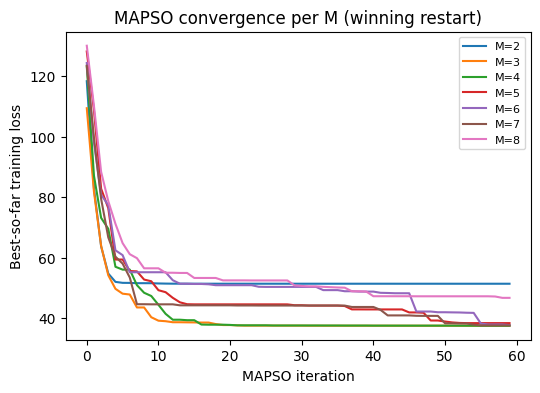

In [168]:
# --- 2.1b -- Diagnostic: did MAPSO plateau before N_EPOCHS_MAPSO? -------------------
# The FSC-inference-MAPSO library has NO built-in early stopping / patience for MAPSO
# (checked its source: the PSO loop in MAPSO.py always runs the full n_iterations, with
# no break-on-no-improvement condition -- by design, since its S3/S4 strategies rely on
# late-stage mutation and "jumping out" to escape local optima, which a naive patience
# check could cut off too early). tinyRNN's RNN training (Section 3) is different: it
# already has real early stopping via 'early_stop_counter' in the base_config.
#
# This curve is where N_EPOCHS_MAPSO in 2.1 comes from: find where the slowest M in your
# sweep flattens, add headroom, cap there. If you change M_CANDIDATES or swap in harder
# data, re-read this plot and retune N_EPOCHS_MAPSO (then FORCE_REFIT / delete the
# affected files in FSC_SWEEP_CACHE_DIR to refit at the new budget).
plt.figure(figsize=(6, 4))
for M in M_CANDIDATES:
    history = fitted_fscs[M].losses_epochs["train"]
    plt.plot(history, label=f"M={M}")
plt.xlabel("MAPSO iteration")
plt.ylabel("Best-so-far training loss")
plt.title("MAPSO convergence per M (winning restart)")
plt.legend(fontsize=8)
plt.show()

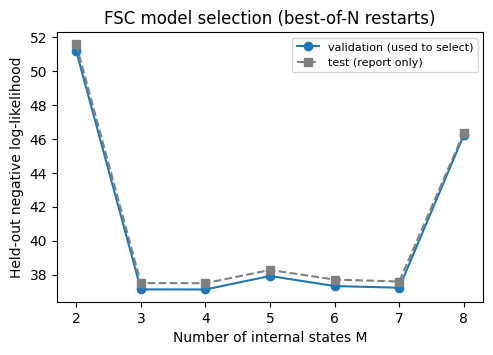

Validation loss is tied across M (all ~37.1327); parsimonious pick within 0.01 -> M* = 3
Per-M held-out TEST loss (report only, NOT used for selection):
   M=2: test = 51.5676
   M=3: test = 37.5072
   M=4: test = 37.5030
   M=5: test = 38.2832
   M=6: test = 37.7144
   M=7: test = 37.6001
   M=8: test = 46.3582


In [169]:
# --- 2.2 -- Model selection: validation is tied across M, so parsimony decides --------
Ms = sorted(fsc_val_losses)

plt.figure(figsize=(5.5, 3.5))
plt.plot(Ms, [fsc_val_losses[m] for m in Ms], "o-", label="validation (used to select)")
plt.plot(Ms, [fsc_test_losses[m] for m in Ms], "s--", c="gray", label="test (report only)")
plt.xlabel("Number of internal states M")
plt.ylabel("Held-out negative log-likelihood")
plt.title("FSC model selection (best-of-N restarts)")
plt.legend(fontsize=8)
plt.show()

# What to read off this plot -- generic, not assuming any particular shape in advance:
#
# If validation loss ties across several M (within TOL below), parsimony decides: take the
# SMALLEST M within noise of the best. That was the WSLS notebook's story (every M>=2 tied at
# the ~0.693-nat floor set by the unpredictable first trial). It is NOT automatically this
# dataset's story -- check the actual per-M numbers printed below before assuming a tie. If M
# clearly matters here (loss keeps improving well past M=2), the elbow itself -- not a forced
# minimum -- is the real M*.
#
# The gap between validation and test curves is worth reading directly too, rather than
# assuming it means the same thing it meant for WSLS (there, test spikes traced back to a
# single rare "lapse" trial in an otherwise near-deterministic rule -- that explanation doesn't
# transfer here without checking).
val_min = min(fsc_val_losses.values())
TOL = 0.01
M_STAR = min(m for m in fsc_val_losses if fsc_val_losses[m] <= val_min + TOL)
print(f"Validation loss is tied across M (all ~{val_min:.4f}); parsimonious pick within {TOL} -> M* = {M_STAR}")
print("Per-M held-out TEST loss (report only, NOT used for selection):")
for m in Ms:
    print(f"   M={m}: test = {fsc_test_losses[m]:.4f}")

Loading cached best_fsc from fitted_models_ts/ts/fsc/best_fsc_M3.pkl


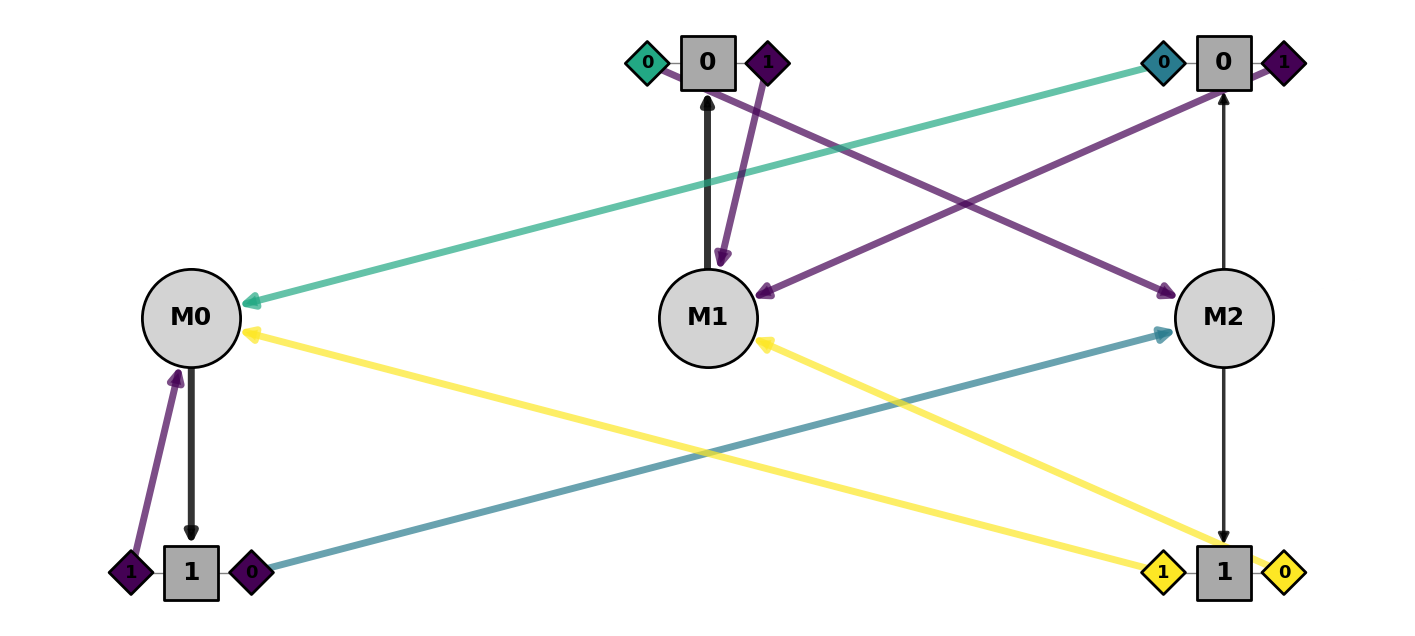

In [170]:
# --- 2.3 -- Refit M* on ALL data (best-of-N) and plot the FSC diagram ----------------
# The final interpretable model uses ALL sessions (no held-out at this stage -- we want the
# best possible fit for the diagram + the Sections 4-9 analysis), so restarts here are ranked by
# their fit loss on all data. Cached like 2.1; FORCE_REFIT_BEST_FSC / deleting the file refits.
FORCE_REFIT_BEST_FSC = False
FSC_SAVE_DIR = f"fitted_models_ts/{DATASET}/fsc/"
best_fsc_cache_path = os.path.join(FSC_SAVE_DIR, f"best_fsc_M{M_STAR}.pkl")

if not FORCE_REFIT_BEST_FSC and os.path.exists(best_fsc_cache_path):
    print(f"Loading cached best_fsc from {best_fsc_cache_path}")
    with open(best_fsc_cache_path, "rb") as f:
        best_fsc = pickle.load(f)
else:
    fsc_all_trajectories = sessions_to_fsc_trajectories(encoded_sessions)
    best_loss_all, best_fsc = None, None
    for r in range(N_RESTARTS):
        cand = fit_one_fsc(M_STAR, seed=FSC_SWEEP_SEED + 10000 + r, trajectories=fsc_all_trajectories)
        L = float(cand.compute_loss(fsc_all_trajectories))
        print(f"   restart {r}: all-data fit loss = {L:.4f}")
        if best_loss_all is None or L < best_loss_all:
            best_loss_all, best_fsc = L, cand
    print(f"   -> kept the restart with all-data fit loss {best_loss_all:.4f}")
    best_fsc.set_mode("generation")
    best_fsc.save(FSC_SAVE_DIR, filename=f"best_fsc_M{M_STAR}.pkl")

best_fsc.set_mode("generation")
obs_colors = plt.cm.Set2(np.linspace(0, 1, Y))
# hide_unused_actions=True drops the action branches with pi(a|m)=0 and the observation
# nodes hanging off them, instead of drawing them with no edges attached.
ax = best_fsc.plot_FSC(observation_node_colors=obs_colors, th_action_probs=1e-3,
                       th_mem_transitions=1e-3, hide_unused_actions=True)
plt.show()


## 3. tinyRNN training

Uses the repo's own `datasets.SimpleDataset` (their built-in generic-data entry
point) and the exact same training call
(`training_experiments.training.behavior_cv_training_config_combination`) used in the
paper's demo script `training_experiments/exp_monkeyV_minimal.py`: nested
cross-validation (outer folds = test sets, inner folds = train/val split) with
multiple random seeds per fold, sweeping `hidden_dim`. Model selection (picking the
smallest hidden size not significantly worse than larger ones) uses the paper's own
`analyzing_experiments.analyzing_perf.select_final_rnn_perf`.

**This will be slow-ish on CPU for real data / larger sweeps.** `outer_splits=5,
inner_splits=4, seed_num=2` (the paper's own minimal-demo defaults) means `5*4*2 =
40` models trained *per hidden_dim value*. Reduce these for a quick check, restore
them for a paper-faithful run.


In [171]:

_use_tinyrnn_path()
os.chdir("tinyRNN")   # training.py assumes it's run from the repo root (path_settings, data_path.json)

from datasets import Dataset
from agents import Agent
from training_experiments.training import behavior_cv_training_config_combination
from analyzing_experiments.analyzing_perf import select_final_rnn_perf


In [172]:
# --- 3.1 -- Build SimpleDataset files (RNN trains on fit+val, HOLDS OUT test) --------
# The RNN must hold out the SAME test set as the FSC, so Section 8 can compare them on
# identical trials. So it trains on fit+val only; test_sessions is untouched until 3.5.
input_format = [
    dict(name="action", one_hot_classes=A),
    dict(name="observation", one_hot_classes=Y),
]
if HAS_REWARD:
    input_format.append(dict(name="reward"))
INPUT_DIM = sum(fmt.get("one_hot_classes", 1) for fmt in input_format)

os.makedirs("files/SimpleDatasetInput", exist_ok=True)
def make_rnn_spec(session_list, filename):
    """Write a SimpleDataset input file for `session_list`, return its behav_data_spec.
    Reused for the training set (3.1), all sessions (3.4), and the test set (3.4)."""
    data = {"action": [s["actions"] for s in session_list],
            "observation": [s["observations"] for s in session_list]}
    if HAS_REWARD:
        data["reward"] = [s["reward"] for s in session_list]
    fpath = f"files/SimpleDatasetInput/{filename}"
    joblib.dump(data, fpath)
    return {"dataset": "Simple", "data": fpath, "input_format": input_format,
            "output_dim": A, "target_name": "action"}

behav_data_spec = make_rnn_spec(train_sessions + val_sessions, "behavior_train.pkl")

# Stamp which dataset this file holds. behavior_train.pkl has ONE fixed name and is overwritten
# every time you switch DATASET, so scripts/train_rnn_parallel.py (the parallel trainer) has no
# other way to tell whether the data on disk matches the --dataset it was told to train. Without
# this it would happily train, say, random_init's data into the exp_det_init/ folder and you'd
# never know. The script refuses to run if this stamp disagrees with its --dataset argument.
with open("files/SimpleDatasetInput/behavior_train.dataset", "w") as _f:
    _f.write(DATASET)
print(f"RNN trains on {len(train_sessions) + len(val_sessions)} sessions (fit+val); "
      f"{len(test_sessions)} test sessions held out.")
print(f"input_dim = {INPUT_DIM}   output_dim (A) = {A}")

RNN trains on 800 sessions (fit+val); 200 test sessions held out.
input_dim = 4   output_dim (A) = 2


In [173]:

# --- 3.2 -- Official nested-CV training sweep over hidden_dim -----------------------
# Caching is already handled by tinyRNN itself: `_train_one_agent` (training_experiments/
# training.py) checks for a 'temp_summary.pkl' in each model's folder under
# MODEL_SAVE_PATH (tinyRNN/files/saved_model/, set in Patch 1) and skips straight to
# loading it if present. So re-running this cell only trains configs that aren't
# finished yet -- it won't redo completed (hidden_dim, outer_fold, inner_fold, seed)
# combinations.
#
# FORCE_RETRAIN_RNN below is the same kind of override toggle as FORCE_REFIT_FSC_SWEEP /
# FORCE_REFIT_BEST_FSC in Section 2: pure notebook-level file deletion using tinyRNN's
# own `path_settings.MODEL_SAVE_PATH`, run *before* calling the library's (unmodified)
# `behavior_cv_training_config_combination`. It does not touch any vendored tinyRNN
# code -- same as the FSC caching, it's just I/O wrapped around the library call.
FORCE_RETRAIN_RNN = False # <-- set to True to wipe this experiment's cache and retrain everything

# L1 penalty on the RNN's recurrent weights. tinyRNN treats l1_weight as a hyperparameter it
# can select over, and it already lives in every model's folder name, so changing it NEVER
# overwrites fits at another l1. We go one step further and give each non-baseline l1 its OWN
# experiment folder + committed archive (exp_<dataset>_l1-<l1>), so you can keep several l1
# values side by side for one dataset and select between them in §3.3 -- change L1_WEIGHT,
# re-run §3.2-§3.4, and the old l1's weights stay put. (The baseline 1e-5 keeps the historical
# name exp_<dataset> so the already-committed fits are still found and reused -- no retrain.)
L1_BASELINE = 1e-5
L1_WEIGHT   = 1e-5     # <-- try e.g. 1e-4 to train + keep a second, separately-selectable l1
EXP_FOLDER  = f"exp_{DATASET}" if L1_WEIGHT == L1_BASELINE else f"exp_{DATASET}_l1-{L1_WEIGHT:g}"

# WHERE THE RNN FITS LIVE, AND WHY THERE ARE TWO COPIES
# -----------------------------------------------------
# tinyRNN reads/writes its fits under tinyRNN/files/saved_model/ (MODEL_SAVE_PATH, set by
# Patch 1). That path is inside the vendored clone, which .gitignore excludes -- so fits left
# there alone are LOCAL ONLY and a fresh clone would retrain the whole sweep from scratch
# (hours). So we keep a committed copy under fitted_models/<dataset>/rnn/, mirroring what the
# FSC side already does with fitted_models/<dataset>/fsc/, and sync the two here:
#   - restore: archive -> live, if the live cache is missing (i.e. right after a clone)
#   - archive: live -> archive, after training, so the fits get committed
import shutil
RNN_LIVE_DIR    = f"files/saved_model/{EXP_FOLDER}"          # cwd is tinyRNN/ in this section
RNN_ARCHIVE_DIR = f"../fitted_models_ts/{DATASET}/rnn/{EXP_FOLDER}"

if FORCE_RETRAIN_RNN:
    # Delete BOTH copies -- deleting only the live one would just be undone by the restore below.
    for _d, _label in ((RNN_LIVE_DIR, "live cache"), (RNN_ARCHIVE_DIR, "committed archive")):
        if os.path.isdir(_d):
            shutil.rmtree(_d)
            print(f"Deleted {_label} at {_d}")
    print("Every hidden_dim/fold/seed combo below will retrain from scratch.")
elif os.path.isdir(RNN_ARCHIVE_DIR) and not os.path.isdir(RNN_LIVE_DIR):
    shutil.copytree(RNN_ARCHIVE_DIR, RNN_LIVE_DIR)
    print(f"Restored committed RNN fits: {RNN_ARCHIVE_DIR} -> {RNN_LIVE_DIR}\n"
          f"(nothing below will retrain; delete that folder or set FORCE_RETRAIN_RNN to redo them)")

# Early stopping: 'early_stop_counter' below IS real patience-based early stopping
# (RNNAgentTrainer.py stops once validation loss hasn't improved for that many epochs),
# using the paper's own default of 200. Unlike MAPSO on the FSC side, this is already
# as fast as the paper's authors made it -- lower it only if you want to trade fidelity
# for speed.
HIDDEN_DIM_CANDIDATES = [1, 2, 3, 4, 5, 6, 7, 8]   # RNN sizes to try (the paper sweeps a range)
# We start at hidden_dim=1 here, but the FSC sweep in 2.1 starts at M=2 -- deliberate, not an
# inconsistency. An FSC with 1 memory state has NO memory: a single state can't be
# history-dependent, so it's a dead baseline we skip. A GRU with 1 hidden unit is different --
# that unit is a CONTINUOUS number updated each trial, so it can still carry information (slide
# toward "play A" vs "play B"). One continuous unit is a real model; one discrete state is not.
# So the two x-axes just start at different points; the FSC-vs-RNN overlay in 3.5 begins at M=2 / H=1.

base_config = {
    ### dataset info
    "dataset": "Simple",
    "behav_format": "tensor",
    "behav_data_spec": behav_data_spec,
    ### model info
    "agent_type": "RNN",
    "rnn_type": "GRU",
    "input_dim": INPUT_DIM,
    "hidden_dim": 2,           # overwritten by config_ranges below
    "output_dim": A,
    "device": "cpu",           # set to "cuda" if you have a GPU
    "output_h0": True,
    "trainable_h0": False,
    "readout_FC": True,
    "one_hot": False,
    ### training info for one model
    "lr": 0.005,
    "l1_weight": L1_WEIGHT,
    "weight_decay": 0,
    "penalized_weight": "rec",
    "max_epoch_num": 2000,        # paper default; lower this for a quick smoke test
    "early_stop_counter": 200,
    ### training info for many models on dataset (paper's own nested-CV settings)
    "outer_splits": 5,
    "inner_splits": 4,
    "seed_num": 2,
    ### additional training info
    "save_model_pass": "minimal",
    "training_diagnose": None,
    "exp_folder": EXP_FOLDER,
}
config_ranges = {
    "rnn_type": ["GRU"],
    "hidden_dim": HIDDEN_DIM_CANDIDATES,
    "readout_FC": [True],
    "l1_weight": [L1_WEIGHT],
}

# HOW THIS CELL RUNS THE SWEEP
# ----------------------------
# n_jobs below is a no-op for RNNs: agent_pool_auto_train (training_experiments/training.py)
# hard-overrides it back to 1 whenever agent_type == 'RNN'. So the library call on its own is
# single-process however large a number you pass. That's upstream's choice, not our bug.
#
# The fits ARE independent across hidden_dim, though. So by default this cell first farms them
# out to one OS process per size (scripts/train_rnn_parallel.py), and only then calls the
# library exactly as before -- by which point every config is already finished, so tinyRNN just
# loads them and skips. Same configs, same folders, same results, ~8x faster on a 10-core Mac.
# Nothing to run by hand: executing the notebook top to bottom gets you the parallel path.
#
# Set PARALLEL_TRAIN = False to go straight through the library, single-process.
#
# DON'T reach for the GPU: these models are tiny (hidden_dim <= 8, input_dim 4), so MPS/CUDA is
# SLOWER than CPU here (measured ~1.4x slower on an M-series Mac -- per-step kernel-launch
# overhead swamps a 4x4 matmul). tinyRNN also runs the net in float64 (RNNAgent calls .double()),
# which Apple's MPS backend cannot do at all. Parallel CPU processes are the real speedup.
PARALLEL_TRAIN = True

if PARALLEL_TRAIN:
    import subprocess
    # cwd is tinyRNN/ here (cell 3.0 chdir'd in); the script resolves the repo root from its own
    # __file__, so it doesn't care where it's called from.
    cmd = [sys.executable, os.path.join("..", "scripts", "train_rnn_parallel.py"),
           "--dataset", DATASET, "--l1", repr(L1_WEIGHT),
           "--dims", *[str(h) for h in HIDDEN_DIM_CANDIDATES]]
    print("Farming the sweep out to one process per hidden_dim:\n  " + " ".join(cmd) + "\n")
    if subprocess.run(cmd).returncode != 0:
        print("\nParallel trainer failed -- falling back to the library's single-process path.\n"
              "(See train_<dataset>_h<dim>.log for why.)")
    else:
        print("\nParallel training finished; the library call below will just load the fits.\n")

behavior_cv_training_config_combination(base_config, config_ranges, n_jobs=8, verbose_level=1)

# Mirror the finished fits out to the committed archive, so a fresh clone (or a teammate)
# doesn't repeat this. Byte-identical when nothing retrained, so git sees no change.
if os.path.isdir(RNN_LIVE_DIR):
    os.makedirs(os.path.dirname(RNN_ARCHIVE_DIR), exist_ok=True)
    if os.path.isdir(RNN_ARCHIVE_DIR):
        shutil.rmtree(RNN_ARCHIVE_DIR)
    shutil.copytree(RNN_LIVE_DIR, RNN_ARCHIVE_DIR)
    _n = sum(len(f) for _, _, f in os.walk(RNN_ARCHIVE_DIR))
    print(f"\nArchived {_n} files to {RNN_ARCHIVE_DIR} (commit these).")

Farming the sweep out to one process per hidden_dim:
  /Users/nawaf/Desktop/Vs code/FSC-Experimentations/.venv/bin/python ../scripts/train_rnn_parallel.py --dataset ts --l1 1e-05 --dims 1 2 3 4 5 6 7 8

dataset=ts  dims=[1, 2, 3, 4, 5, 6, 7, 8]  l1=1e-05  -> 8 parallel processes (10 cores)
Training into exp_ts/. Already-finished configs are skipped automatically.

  launch hidden_dim=1  (log: train_ts_h1.log)
  launch hidden_dim=2  (log: train_ts_h2.log)
  launch hidden_dim=3  (log: train_ts_h3.log)
  launch hidden_dim=4  (log: train_ts_h4.log)
  launch hidden_dim=5  (log: train_ts_h5.log)
  launch hidden_dim=6  (log: train_ts_h6.log)
  launch hidden_dim=7  (log: train_ts_h7.log)
  launch hidden_dim=8  (log: train_ts_h8.log)
  hidden_dim=1 finished: FAILED (exit 1)
  hidden_dim=2 finished: FAILED (exit 1)
  hidden_dim=3 finished: FAILED (exit 1)
  hidden_dim=4 finished: FAILED (exit 1)
  hidden_dim=5 finished: FAILED (exit 1)
  hidden_dim=6 finished: FAILED (exit 1)
  hidden_dim=7 fini


8 size(s) FAILED: [1, 2, 3, 4, 5, 6, 7, 8]. See train_ts_h<dim>.log



Archived 1648 files to ../fitted_models_ts/ts/rnn/exp_ts (commit these).


Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 1827.68it/s]


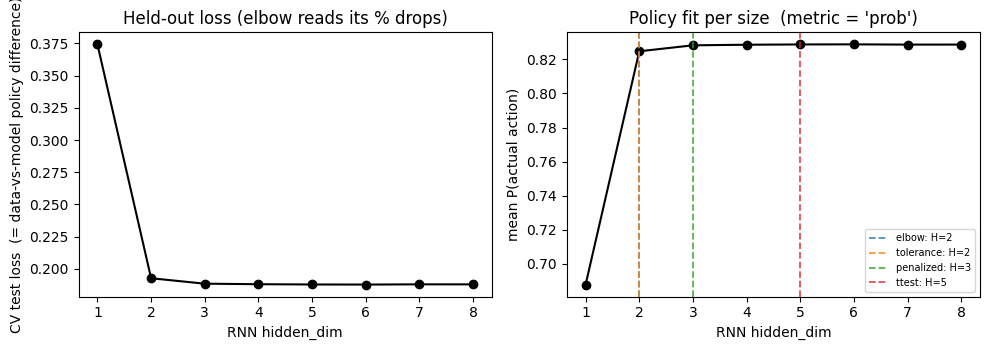

Selected hidden_dim: H* = 2   (rule='elbow', metric='prob', elbow='relative')

What each rule would pick:
   elbow     : H = 2  <- driving H_STAR
   tolerance : H = 2
   penalized : H = 3
   ttest     : H = 5

Per-size cross-validated performance:
 hidden_dim  less_than_former  test_loss
          1                 1   0.374323
          2                 1   0.192628
          3                 1   0.188390
          4                 1   0.187980
          5                 1   0.187778
          6                 0   0.187703
          7                 0   0.187888
          8                 0   0.187861


In [174]:
# --- 3.3 -- Model selection: smallest RNN whose extra units still improve the POLICY ----
# WHAT CHANGED, AND WHY
# ---------------------
# The paper's rule (select_final_rnn_perf -> get_dim_from_perf) picks the LARGEST hidden_dim
# whose cross-validated test loss is significantly lower (paired t-test over outer folds,
# p<0.05) than EVERY smaller size. On near-deterministic data that t-test flags a
# behaviorally-trivial loss improvement as "significant", so it OVER-selects (H*=5 on random_init,
# which is really a 1-2 dim strategy; det_init picks 8 over 4 at p=0.029 -- see 11).
#
# We keep the paper's pick computed and reported (H_STAR_TTEST) for fidelity, but the size that
# actually drives the downstream analysis is chosen by an explicit fit-vs-complexity rule -- the
# same philosophy the FSC side already uses in 2.2 (smallest M within tolerance of the best).
#
# THE METRIC -- the model's POLICY, not its accuracy.
# ---------------------------------------------------
# We score each hidden_dim by the probability its POLICY assigns to the action that actually
# happened, per held-out trial: mean P(actual action) = exp(-cross-validated test_loss). This is
# the "P(action | history)" quantity -- how well the model's decision POLICY matches the real
# choices -- and the cross-validated loss is exactly the difference between the data and the model
# (held-out cross-entropy = KL(data policy || model policy) up to a constant). So selecting on this
# IS selecting on the data-vs-model policy difference.
#   NOT accuracy (argmax match): two different policies that both pick the right top action score
#   identical accuracy, so on near-deterministic data accuracy SATURATES (~0.995-1.00 for every
#   size) and can't separate them. That is why "acc" is available but not the default.
#
# THE ELBOW IS RELATIVE, on purpose.
# ----------------------------------
# When every size is near-perfect (this project's regime), a real improvement looks tiny in
# absolute terms but large in relative terms: on random_init, H1->H2 is +0.003 in probability yet
# a 37% cut in held-out loss. So the elbow keeps adding a unit while it still cuts the held-out
# LOSS by at least ELBOW_DELTA (a FRACTION), and stops at the first unit that doesn't. This is
# scale-free -- it doesn't collapse to the smallest model just because the probabilities are all
# near 1.0. Set ELBOW_MODE="absolute" to threshold the raw metric gain instead.
import pandas as pd

# THE FOUR SELECTION RULES -- pick one via SELECTION_RULE. Ordered least -> most permissive
# (i.e. smallest -> largest H*). All four are computed and printed every run so you can compare;
# only SELECTION_RULE drives the downstream H_STAR.
#   "elbow"     -- Add a unit only while it still improves the held-out fit ENOUGH (see ELBOW_MODE);
#                  stop at the first unit that doesn't. Picks the smallest size that captures the
#                  real gains. BEST DEFAULT for "smallest sufficient model".
#   "penalized" -- argmin over H of  loss(H) + PENALTY_LAMBDA*H  (AIC/BIC style). One knob dials fit
#                  vs size continuously: bigger lambda -> smaller model. Use when you want a single
#                  tunable complexity cost rather than a stopping rule.
#   "tolerance" -- Smallest H whose loss is within TOL_DELTA (a fraction) of the BEST size's loss
#                  -- a horizontal line at best*(1+TOL_DELTA), take the first size under it. More
#                  permissive than elbow: it only asks "close enough to the best?", not "did each
#                  unit earn its place?". Use when you'll accept a larger model if it's near-best.
#   "ttest"     -- The tinyRNN paper's ORIGINAL rule: largest H significantly better (paired t-test
#                  over CV folds, p<0.05) than EVERY smaller H. Most permissive; over-selects on
#                  near-flat curves (that's the behaviour we moved away from). Kept for fidelity.
# Rough guide: elbow/penalized = parsimony; tolerance = "near-best is fine"; ttest = reproduce paper.
# On random_init they give: elbow=2, penalized=2, tolerance=4, ttest=5.

# ---- knobs -------------------------------------------------------------------------
SEL_METRIC     = "prob"     # "prob" (mean P(actual action) = policy fit) or "acc" (argmax match; saturates)
SELECTION_RULE = "elbow"    # which rule sets H_STAR: "elbow" | "tolerance" | "penalized" | "ttest"
ELBOW_MODE     = "relative" # "relative" -> next unit must cut held-out loss by >= ELBOW_DELTA (a fraction)
                            # "absolute" -> next unit must raise the metric by >= ELBOW_DELTA (in [0,1])
ELBOW_DELTA    = 0.10       # relative: 0.10 = a unit must cut CV loss >=10% to be worth adding
                            # absolute: 0.10 = a unit must add >=0.10 of the metric to be worth adding
TOL_DELTA      = 0.10       # tolerance band: smallest size within this fraction of the BEST (min) loss
PENALTY_LAMBDA = 0.001      # penalized (AIC-flavoured): argmin over H of  CV_loss(H) + PENALTY_LAMBDA*H (nats/unit)
# ------------------------------------------------------------------------------------

def select_rnn_size(dim_est, metric="prob", elbow_mode="relative", elbow_delta=0.10,
                    tol_delta=0.10, penalty_lambda=0.001):
    """Pick a hidden_dim from a per-size performance table under four rules.

    dim_est needs 'hidden_dim' and 'test_loss' (and 'test_acc' if metric='acc'). Returns a dict:
    metric_name, H (sizes), score (metric per size, higher=better, in [0,1]), loss (CV test loss),
    the pick under each rule, and 'rel_gain' (fractional loss cut the next unit buys, for auditing).
    """
    d = dim_est.sort_values("hidden_dim").reset_index(drop=True)
    H = d["hidden_dim"].to_numpy().astype(int)
    loss = d["test_loss"].to_numpy(float)
    if metric == "acc" and "test_acc" in d.columns:
        score = d["test_acc"].to_numpy(float); mname = "CV test accuracy"
    else:
        score = np.exp(-loss); mname = "mean P(actual action)"
    # fractional loss reduction the NEXT unit buys at each size (nan at the last size)
    rel_gain = np.full(len(H), np.nan)
    rel_gain[:-1] = (loss[:-1] - loss[1:]) / np.where(loss[:-1] > 0, loss[:-1], np.nan)
    # ELBOW -- keep adding a unit while it improves the fit ENOUGH; stop at the first that doesn't.
    # If every unit keeps paying off -> largest size; if the curve is flat/worsens from the start
    # ("all sizes roughly equal") -> the SMALLEST, which is the parsimonious answer.
    elbow = int(H[-1])
    for k in range(len(H) - 1):
        improve = rel_gain[k] if elbow_mode == "relative" else (score[k + 1] - score[k])
        if not (improve >= elbow_delta):     # nan-safe: a worse/tied next size stops us here
            elbow = int(H[k]); break
    # TOLERANCE BAND -- smallest size within tol_delta (fraction) of the BEST (min) held-out loss.
    tol = int(H[int(np.argmax(loss <= float(np.min(loss)) * (1.0 + tol_delta)))])
    # PENALIZED (AIC-flavoured) -- charge penalty_lambda nats of loss per unit, take the best net.
    pen = int(H[int(np.argmin(loss + penalty_lambda * H))])
    return {"metric_name": mname, "H": H, "score": score, "loss": loss, "rel_gain": rel_gain,
            "elbow": elbow, "tolerance": tol, "penalized": pen, "elbow_mode": elbow_mode}

# tinyRNN computes accuracy by loading each fold's data; if that path isn't available here we
# fall back gracefully (the "prob" metric never needs it -- it comes straight from test_loss).
try:
    perf, summary, dim_est = select_final_rnn_perf(EXP_FOLDER, return_dim_est=True, verbose=False,
                                                   include_acc=(SEL_METRIC == "acc"))
except Exception as _e:
    print(f"select_final_rnn_perf(include_acc={SEL_METRIC=='acc'}) failed ({_e!r}); retrying without accuracy.")
    perf, summary, dim_est = select_final_rnn_perf(EXP_FOLDER, return_dim_est=True, verbose=False)
if SEL_METRIC == "acc" and "test_acc" not in dim_est.columns:
    print("No cross-validated test_acc available -> switching SEL_METRIC to 'prob'.")
    SEL_METRIC = "prob"

# The paper's own pick (t-test dimensionality) -- KEPT for fidelity/reporting, exactly as before.
improved = dim_est.loc[dim_est["less_than_former"] == 1, "hidden_dim"]
H_STAR_TTEST = int(improved.max()) if len(improved) else int(dim_est["hidden_dim"].min())

sel = select_rnn_size(dim_est, metric=SEL_METRIC, elbow_mode=ELBOW_MODE, elbow_delta=ELBOW_DELTA,
                      tol_delta=TOL_DELTA, penalty_lambda=PENALTY_LAMBDA)
picks = {"elbow": sel["elbow"], "tolerance": sel["tolerance"],
         "penalized": sel["penalized"], "ttest": H_STAR_TTEST}

# --- plot: the loss curve (what "policy difference" really is) next to the metric + every pick ---
_d = dim_est.sort_values("hidden_dim")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax1.plot(_d["hidden_dim"], _d["test_loss"], "o-", c="k")
ax1.set_xlabel("RNN hidden_dim"); ax1.set_ylabel("CV test loss  (= data-vs-model policy difference)")
ax1.set_title("Held-out loss (elbow reads its % drops)")

H, score = sel["H"], sel["score"]
ax2.plot(H, score, "o-", c="k")
_col = {"elbow": "C0", "tolerance": "C1", "penalized": "C2", "ttest": "C3"}
for _rule, _h in picks.items():
    ax2.axvline(_h, ls="--", lw=1.3, c=_col[_rule], alpha=.8, label=f"{_rule}: H={_h}")
ax2.set_xlabel("RNN hidden_dim"); ax2.set_ylabel(sel["metric_name"])
ax2.set_title(f"Policy fit per size  (metric = '{SEL_METRIC}')")
ax2.legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

# --- OPTIONAL: manually override the selected size ----------------------------------
# Set H_STAR_OVERRIDE to any already-trained hidden_dim to force it; leave None to use the rule
# named in SELECTION_RULE. (6.6b re-derives each dataset's own H* independently and ignores this.)
H_STAR_OVERRIDE = None

if H_STAR_OVERRIDE is not None:
    _trained = {int(h) for h in dim_est["hidden_dim"]}
    assert int(H_STAR_OVERRIDE) in _trained, \
        f"no trained model at hidden_dim={H_STAR_OVERRIDE}; trained sizes: {sorted(_trained)}"
    H_STAR = int(H_STAR_OVERRIDE)
    print(f"MANUALLY OVERRIDDEN to H* = {H_STAR} (rule '{SELECTION_RULE}' would give {picks.get(SELECTION_RULE, H_STAR_TTEST)})")
else:
    H_STAR = picks[SELECTION_RULE]
    print(f"Selected hidden_dim: H* = {H_STAR}   (rule='{SELECTION_RULE}', metric='{SEL_METRIC}', elbow='{ELBOW_MODE}')")

print("\nWhat each rule would pick:")
for _rule, _h in picks.items():
    _star = "  <- driving H_STAR" if (_rule == SELECTION_RULE and H_STAR_OVERRIDE is None) else ""
    print(f"   {_rule:<10s}: H = {_h}{_star}")

_cols = ["hidden_dim", "less_than_former", "test_loss"] + (["test_acc"] if "test_acc" in dim_est.columns else [])
print("\nPer-size cross-validated performance:")
print(_d[_cols].to_string(index=False))


In [175]:
# --- 3.3b -- Is the size choice trustworthy? Stress-test the selector ----------------
# Four independent checks that H_STAR is a defensible size, not an artifact of one threshold
# or one CV split -- this is the "run a lot of tests on the choosing" part:
#   1. threshold stability  -- does the pick sit on a WIDE band of the delta knob?
#   2. fold bootstrap       -- resample the CV folds; is the pick a solid mode, not a coin-flip?
#   3. sanity bounds        -- parsimony pick must not exceed the paper's (permissive) t-test pick.
#   4. gain audit           -- print the per-unit loss cut so the elbow is checkable by eye.
_d    = dim_est.sort_values("hidden_dim").reset_index(drop=True)
H     = _d["hidden_dim"].to_numpy().astype(int)
_loss = _d["test_loss"].to_numpy(float)
_facc = np.array([np.asarray(x, float) for x in _d["agg_test_acc"]]) if "agg_test_acc" in _d.columns else None

def _elbow_pick(loss_vec, acc_vec=None, delta=ELBOW_DELTA):
    """The driving elbow, reduced to arrays so the bootstrap/sweep test the SAME rule that set H_STAR."""
    loss_vec = np.asarray(loss_vec, float)
    sc = np.asarray(acc_vec, float) if (SEL_METRIC == "acc" and acc_vec is not None) else np.exp(-loss_vec)
    rg = (loss_vec[:-1] - loss_vec[1:]) / np.where(loss_vec[:-1] > 0, loss_vec[:-1], np.nan)
    pick = int(H[-1])
    for k in range(len(H) - 1):
        imp = rg[k] if ELBOW_MODE == "relative" else (sc[k + 1] - sc[k])
        if not (imp >= delta):
            pick = int(H[k]); break
    return pick

# TEST 1 -- threshold stability. Vary "how much a unit must buy" and see where each rule lands.
print(f"TEST 1 -- pick vs the delta knob (ELBOW_MODE='{ELBOW_MODE}'; want: long stretches with no change)\n")
_sweep = [0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50] if ELBOW_MODE == "relative" else [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
_rows = []
for _dl in _sweep:
    _s = select_rnn_size(dim_est, metric=SEL_METRIC, elbow_mode=ELBOW_MODE, elbow_delta=_dl,
                         tol_delta=_dl, penalty_lambda=PENALTY_LAMBDA)
    _rows.append({"delta": _dl, "elbow": _s["elbow"], "tolerance": _s["tolerance"]})
print(pd.DataFrame(_rows).to_string(index=False))
if SELECTION_RULE in ("elbow", "tolerance"):
    _hi = 0.6 if ELBOW_MODE == "relative" else 0.05
    _grid = np.linspace(_hi / 500, _hi, 500)
    if SELECTION_RULE == "elbow":
        _picks = np.array([_elbow_pick(_loss, _facc, delta=d) for d in _grid])
    else:
        _picks = np.array([select_rnn_size(dim_est, metric=SEL_METRIC, elbow_mode=ELBOW_MODE,
                                           elbow_delta=d, tol_delta=d, penalty_lambda=PENALTY_LAMBDA)["tolerance"]
                           for d in _grid])
    _i = int(np.argmin(np.abs(_grid - ELBOW_DELTA))); _here = int(_picks[_i]); _same = _picks == _here
    _lo = _i
    while _lo > 0 and _same[_lo - 1]:
        _lo -= 1
    _up = _i
    while _up < len(_grid) - 1 and _same[_up + 1]:
        _up += 1
    _nchg = int(np.sum(_picks[1:] != _picks[:-1]))
    print(f"\nAt your {SELECTION_RULE} knob = {ELBOW_DELTA:g}, the pick is H={_here}, holding across the whole "
          f"band [{_grid[_lo]:.3f}, {_grid[_up]:.3f}] (wider = not balanced on a knife-edge).")
    print(f"Over the scanned range the pick takes {len(set(_picks.tolist()))} distinct value(s), "
          f"{_nchg} transition(s) -- fewer = more stable.")

# TEST 2 -- bootstrap over CV outer folds. agg_test_loss holds the per-outer-fold losses; resample
# folds with replacement, re-run the driving elbow each time -> a DISTRIBUTION of H*.
_fl = np.array([np.asarray(x, float) for x in _d["agg_test_loss"]]) if "agg_test_loss" in _d.columns else None
if _fl is not None and _fl.ndim == 2 and _fl.shape[1] >= 2:
    print(f"\nTEST 2 -- bootstrap over {_fl.shape[1]} CV outer folds: elbow-pick distribution\n")
    _rng = np.random.default_rng(0); _nf = _fl.shape[1]; _boot = []
    for _ in range(2000):
        _ix = _rng.integers(0, _nf, _nf)
        _boot.append(_elbow_pick(_fl[:, _ix].mean(1), None if _facc is None else _facc[:, _ix].mean(1)))
    _boot = np.array(_boot)
    for _h in H:
        _f = np.mean(_boot == _h)
        if _f > 0:
            print(f"   H={_h}: {100*_f:5.1f}%  " + "#" * int(round(_f * 40)))
    print(f"   -> modal elbow size = {int(np.bincount(_boot).argmax())}   (chosen H* = {H_STAR})")
else:
    print("\nTEST 2 -- skipped (need per-fold losses with >=2 folds).")

# TEST 3 -- sanity bounds.
print("\nTEST 3 -- sanity bounds")
_trained = sorted(int(h) for h in H)
assert H_STAR in _trained, f"H*={H_STAR} is not a trained size {_trained}"
print(f"   H*={H_STAR} is a trained size {_trained}: PASS")
print(f"   H*({H_STAR}) <= paper t-test H({H_STAR_TTEST}): "
      f"{'PASS' if H_STAR <= H_STAR_TTEST else 'NOTE -- parsimony pick is LARGER than the t-test pick, unusual'}")

# TEST 4 -- gain audit. Print the metric, the absolute step, and the FRACTIONAL loss cut the next
# unit buys, so the (relative) elbow cut is auditable by eye.
_s = select_rnn_size(dim_est, metric=SEL_METRIC, elbow_mode=ELBOW_MODE, elbow_delta=ELBOW_DELTA,
                     tol_delta=TOL_DELTA, penalty_lambda=PENALTY_LAMBDA)
_thr = f">= {ELBOW_DELTA:g} loss-cut" if ELBOW_MODE == "relative" else f">= {ELBOW_DELTA:g} metric-gain"
print(f"\nTEST 4 -- per added unit (elbow keeps a unit while the next unit buys {_thr})\n")
for _k in range(len(H)):
    _abs = "     -   " if _k == 0 else f"{_s['score'][_k] - _s['score'][_k-1]:+.4f}"
    _rel = "    -  " if (_k == len(H) - 1 or np.isnan(_s['rel_gain'][_k])) else f"{100*_s['rel_gain'][_k]:+5.1f}%"
    _mark = "   <- elbow H*" if H[_k] == _s["elbow"] else ""
    print(f"   H={H[_k]}: {_s['metric_name']} = {_s['score'][_k]:.4f}   abs {_abs}   next-unit loss cut {_rel}{_mark}")


TEST 1 -- pick vs the delta knob (ELBOW_MODE='relative'; want: long stretches with no change)

 delta  elbow  tolerance
  0.02      3          3
  0.05      2          2
  0.10      2          2
  0.15      2          2
  0.20      2          2
  0.30      2          2
  0.50      1          2

At your elbow knob = 0.1, the pick is H=2, holding across the whole band [0.023, 0.485] (wider = not balanced on a knife-edge).
Over the scanned range the pick takes 4 distinct value(s), 3 transition(s) -- fewer = more stable.

TEST 2 -- bootstrap over 5 CV outer folds: elbow-pick distribution

   H=2: 100.0%  ########################################
   -> modal elbow size = 2   (chosen H* = 2)

TEST 3 -- sanity bounds
   H*=2 is a trained size [1, 2, 3, 4, 5, 6, 7, 8]: PASS
   H*(2) <= paper t-test H(5): PASS

TEST 4 -- per added unit (elbow keeps a unit while the next unit buys >= 0.1 loss-cut)

   H=1: mean P(actual action) = 0.6878   abs      -      next-unit loss cut +48.5%
   H=2: mean P(a

In [176]:

# --- 3.4 -- Load the best H*-sized model and extract hidden-state trajectories ------
# Picks, among all (outer_fold, inner_fold, seed) runs at hidden_dim=H_STAR, the one
# with the lowest combined train+val loss (mirrors 'compete_from_keys' logic used
# internally by select_final_rnn_perf for picking a single instance per fold).
h_star_rows = summary[summary["hidden_dim"] == H_STAR].copy() if "hidden_dim" in summary.columns \
    else summary[summary["config"].apply(lambda c: c["hidden_dim"] == H_STAR)].copy()
h_star_rows = h_star_rows.sort_values("trainval_loss")
best_row = h_star_rows.iloc[0]
best_model_path = best_row["model_path"]
print("Loading best model from:", best_model_path)

rnn_config = dict(base_config)
rnn_config.update({"hidden_dim": H_STAR, "seed": 0})
best_agent = Agent("RNN", config=rnn_config)
best_agent.load(str(best_model_path))

# (a) Hidden-state trajectories on ALL sessions (for the Sections 5 and 7 representation analysis).
#     One deterministic forward pass -- given fixed weights the hidden state is fully determined.
spec_all = make_rnn_spec(encoded_sessions, "behavior_all.pkl")
dt_all = Dataset("Simple", behav_data_spec=spec_all).behav_to(rnn_config)
data_all = dt_all.get_behav_data(range(dt_all.batch_size), rnn_config)
rnn_hidden_states = best_agent.forward(data_all, standard_output=True)["internal"]

# (b) Per-trial P(actual action) on the held-out TEST sessions (for the Section 8 comparison).
#     pointwise_loss gives per-trial -log P(actual action); exp(-that) = the probability.
spec_test = make_rnn_spec(test_sessions, "behavior_test.pkl")
dt_test = Dataset("Simple", behav_data_spec=spec_test).behav_to(rnn_config)
data_test = dt_test.get_behav_data(range(dt_test.batch_size), rnn_config)
rnn_test_out = best_agent.forward(data_test, standard_output=True, pointwise_loss=True)
rnn_test_probs = [np.exp(-np.asarray(b)) for b in rnn_test_out["behav_loss"]]

print(f"Hidden states for {len(rnn_hidden_states)} sessions "
      f"(e.g. session 0 shape = {rnn_hidden_states[0].shape}); "
      f"per-trial test probs for {len(rnn_test_probs)} sessions.")
os.chdir("..")   # back to the notebook's working directory


Loading best model from: exp_ts/rnn_type-GRU.hidden_dim-2.readout_FC-True.l1_weight-1e-05/outerfold0_innerfold0_seed0
Total batch size: 1000
Total batch size: 200
Hidden states for 1000 sessions (e.g. session 0 shape = (201, 2)); per-trial test probs for 200 sessions.


## 4. Reading out both models' internals

Sections 2 and 3 fit each model with its own library. **Everything from here on is our own
code**, and it's organised by *question* rather than by model: each section asks one thing and
answers it for the FSC and the RNN side by side, so the two are always compared on the same
trials with the same convention.

This first section is the plumbing that makes that possible — the per-trial readout of "what is
this model thinking" for each side:

| | FSC | RNN |
|---|---|---|
| the internal state | belief over `M` memory states | hidden vector of `H` numbers |
| where it comes from | forward-filtering (4.1) | one forward pass (3.4) + a by-hand stepper (4.2–4.3) |

One asymmetry to keep in mind, because it recurs: these two are *not* the same kind of object.
The FSC's belief is a probability distribution over named discrete states; the RNN's hidden state
is an unlabelled point in continuous space. §7's probe is what turns that from a problem into a
result.

### 4.1 Reading out the FSC's internal state, trial by trial

In [177]:

def decode_fsc_belief_states(fsc, actions, observations):
    '''Forward-filtering belief b_t(m) = P(memory state = m | actions[:t], observations[:t]),
    for t = 0..T (b_0 = rho, the prior; b_T = belief after the last trial).
    `fsc` must be in 'generation' mode (so get_TMat()/get_rho() return numpy arrays).
    Returns array of shape (T+1, M).'''
    T_mat = fsc.get_TMat()   # shape (Y, M, M, A): axes (obs, prev_mem, next_mem, action)
    rho = np.asarray(fsc.get_rho())
    M = fsc.M

    beliefs = np.zeros((len(actions) + 1, M))
    beliefs[0] = rho
    b = rho.copy()
    for t in range(len(actions)):
        a_t, y_t = int(actions[t]), int(observations[t])
        step = T_mat[y_t, :, :, a_t]     # (prev_mem, next_mem)
        b_new = b @ step                 # sum_m b[m] * step[m, m']
        total = b_new.sum()
        b = b_new / total if total > 0 else np.ones(M) / M   # degenerate fallback
        beliefs[t + 1] = b
    return beliefs

# Restore the FSC import path: after Section 3 put tinyRNN on sys.path, and the FSC's
# generation code lazily JIT-compiles a numba helper from ITS OWN utils.py -- if
# tinyRNN's identically-named utils shadows it at compile time, that import fails.
_use_fsc_path()
best_fsc.set_mode("generation")
fsc_belief_states = [
    decode_fsc_belief_states(best_fsc, s["actions"], s["observations"])
    for s in encoded_sessions
]
print(f"Decoded FSC belief-state trajectories for {len(fsc_belief_states)} sessions, "
      f"e.g. session 0 shape = {fsc_belief_states[0].shape}")

# sanity check: same (T+1) length convention as the RNN's hidden states (output_h0=True)
mismatches = [i for i in range(len(encoded_sessions))
              if fsc_belief_states[i].shape[0] != rnn_hidden_states[i].shape[0]]
print("Sessions with mismatched lengths (should be empty):", mismatches)


Decoded FSC belief-state trajectories for 1000 sessions, e.g. session 0 shape = (201, 3)
Sessions with mismatched lengths (should be empty): []


In [178]:
# --- 4.2 -- Pull the trained GRU weights out into plain numpy -------------------------
# Why by hand? Two things we need later are simply not exposed by the library:
#   (a) the update / reset / new GATE values at each trial (§9.1) -- nn.GRU computes them
#       internally and returns only the resulting hidden state; and
#   (b) AUTOREGRESSIVE generation (§6.2) -- feeding the RNN its OWN sampled action back in
#       as the next input. RNNAgent.forward() is teacher-forced: it always consumes the
#       real action, so it can't generate.
# Both need a single-step function we control. So we re-implement one GRU step in numpy
# from the trained weights, and verify in 4.3 that it matches the library exactly.
#
# WHICH GRU: network_models.py uses torch's OFFICIAL nn.GRU when rnn_type='GRU' (the custom
# GRUCell in custom_rnn_layers.py is only used for SGRU/MIGRU/PNR/...), so we follow nn.GRU's
# equations and its (reset, update, new) chunk order.
#
# H_STAR (from 3.3) is the model the main FSC-vs-RNN comparison uses. H_TO_COMPARE is a
# separate SIZE SUB-STUDY that runs through §5.3, §6 and §9 alongside the main line.
# For this dataset the size-selection rules actively disagree (elbow/tolerance->2,
# penalized->3 = the FSC's own M*, ttest->5 -- see §3.3), so comparing a few sizes
# side by side is directly useful here, not just illustrative. Currently [2, 4, 8];
# worth reconsidering once the H* disagreement above is better understood.
H_TO_COMPARE = [2, 4, 8]

def extract_gru_params(agent):
    """Trained torch weights -> plain numpy. nn.GRU packs the three gates into a single
    matrix, stacked along axis 0 in the order (reset, update, new)."""
    net = agent.model
    p = {k: v.detach().cpu().numpy() for k, v in net.rnn.named_parameters()}
    return {"W_ih": p["weight_ih_l0"], "W_hh": p["weight_hh_l0"],
            "b_ih": p["bias_ih_l0"],   "b_hh": p["bias_hh_l0"],
            "lin_W": net.lin.weight.detach().cpu().numpy(),
            "lin_b": net.lin.bias.detach().cpu().numpy(),
            "H": net.hidden_dim}

_use_tinyrnn_path()
os.chdir("tinyRNN")          # MODEL_SAVE_PATH is relative, so loading needs repo-root as cwd
from agents import Agent
from datasets import Dataset

rnn_params_folds = {}        # {H: [params, ...]} -- every run at that size, best loss first
rnn_params = {}              # {H: params}        -- just the best run at that size
rnn_ref_hidden = {}          # {H: [...]}         -- a library forward pass, to check 4.3 against

for H in H_TO_COMPARE:
    rows = summary[summary["hidden_dim"] == H].sort_values("trainval_loss")
    cfg = dict(base_config); cfg.update({"hidden_dim": H, "seed": 0})
    plist = []
    for _, r in rows.iterrows():
        ag = Agent("RNN", config=cfg)
        ag.load(str(r["model_path"]))
        plist.append(extract_gru_params(ag))
    rnn_params_folds[H] = plist
    rnn_params[H] = plist[0]

    ag = Agent("RNN", config=cfg)
    ag.load(str(rows.iloc[0]["model_path"]))
    spec_chk = make_rnn_spec(encoded_sessions[:3], "behavior_check.pkl")
    dt_chk = Dataset("Simple", behav_data_spec=spec_chk).behav_to(cfg)
    data_chk = dt_chk.get_behav_data(range(dt_chk.batch_size), cfg)
    rnn_ref_hidden[H] = ag.forward(data_chk, standard_output=True)["internal"]
    print(f"H={H}: {len(plist)} runs, best = {rows.iloc[0]['model_path']}")

os.chdir("..")
_use_fsc_path()              # everything downstream is pure numpy + the FSC

Total batch size: 3
H=2: 5 runs, best = exp_ts/rnn_type-GRU.hidden_dim-2.readout_FC-True.l1_weight-1e-05/outerfold0_innerfold0_seed0
Total batch size: 3
H=4: 5 runs, best = exp_ts/rnn_type-GRU.hidden_dim-4.readout_FC-True.l1_weight-1e-05/outerfold0_innerfold1_seed1
Total batch size: 3
H=8: 5 runs, best = exp_ts/rnn_type-GRU.hidden_dim-8.readout_FC-True.l1_weight-1e-05/outerfold0_innerfold1_seed1


In [179]:
# --- 4.3 -- One GRU step, written out, with the gates exposed ------------------------
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def _softmax(z):
    z = np.asarray(z, dtype=float); z = z - z.max()
    e = np.exp(z); return e / e.sum()

def gru_step(h, x, P):
    """One step of torch's nn.GRU, spelled out so the gates are visible:
         r = sigmoid(W_ir x + b_ir + W_hr h + b_hr)        'reset'
         z = sigmoid(W_iz x + b_iz + W_hz h + b_hz)        'update'
         n = tanh(W_in x + b_in + r * (W_hn h + b_hn))     'new'
         h' = (1 - z) * n + z * h
    Returns (new hidden state, dict of the three gate vectors, each length H).
    How to read them: z ~ 1 => hold the old state, z ~ 0 => overwrite it with n.
    r gates how much of the old state is allowed into the proposal n."""
    H = P["H"]
    gi = P["W_ih"] @ x + P["b_ih"]
    gh = P["W_hh"] @ h + P["b_hh"]
    r = _sigmoid(gi[:H]    + gh[:H])
    z = _sigmoid(gi[H:2*H] + gh[H:2*H])
    n = np.tanh( gi[2*H:]  + r * gh[2*H:])
    return (1 - z) * n + z * h, {"reset": r, "update": z, "new": n}

def rnn_encode_input(a, y):
    """One trial's input vector: one-hot(action) then one-hot(observation) -- exactly the
    order §3.1's `input_format` concatenates them in."""
    x = np.zeros(A + Y); x[a] = 1.0; x[A + y] = 1.0
    return x

def rnn_action_probs(h, P):
    """The readout: P(action | hidden state) = softmax(Linear(h))."""
    return _softmax(h @ P["lin_W"].T + P["lin_b"])

# --- verify the by-hand step against the library's own forward pass -------------------
# h0 is all-zeros because §3.2 sets trainable_h0=False (network_models.py then fixes
# h0 = torch.zeros). If this check ever fails, nothing below can be trusted.
print("Max |by-hand - library| over a full session's hidden states:")
for H in H_TO_COMPARE:
    P = rnn_params[H]
    s = encoded_sessions[0]
    h = np.zeros(P["H"]); hs = [h.copy()]
    for t in range(len(s["actions"])):
        h, _ = gru_step(h, rnn_encode_input(int(s["actions"][t]), int(s["observations"][t])), P)
        hs.append(h.copy())
    diff = np.abs(np.array(hs) - rnn_ref_hidden[H][0]).max()
    print(f"   H={H}:  {diff:.2e}   {'OK' if diff < 1e-9 else 'MISMATCH -- investigate'}")

Max |by-hand - library| over a full session's hidden states:
   H=2:  6.11e-16   OK
   H=4:  6.66e-16   OK
   H=8:  7.77e-16   OK


In [180]:
# --- 4.4 -- Trial-by-trial alignment: raw data, side by side, for one example session ------
# This TABLE is just an illustrative peek -- one session, so you can eyeball the FSC's belief and
# the RNN's hidden numbers changing together trial by trial. The table itself isn't used
# downstream, but the arrays behind it (fsc_belief_states, rnn_hidden_states) ARE the raw material
# for the occupancy check (5.1), the PCA (5.2), and the linear probe (Section 7).
example_idx = 0
acts = encoded_sessions[example_idx]["actions"]
obs = encoded_sessions[example_idx]["observations"]

alignment_table = pd.DataFrame({
    "trial": np.arange(len(rnn_hidden_states[example_idx])),
    "action": np.concatenate([[np.nan], acts]),
    "observation": np.concatenate([[np.nan], obs]),
    **{f"fsc_belief_m{m}": fsc_belief_states[example_idx][:, m] for m in range(M_STAR)},
    **{f"rnn_hidden_h{h}": rnn_hidden_states[example_idx][:, h] for h in range(H_STAR)},
})
alignment_table

,trial,action,observation,fsc_belief_m0,fsc_belief_m1,fsc_belief_m2,rnn_hidden_h0,rnn_hidden_h1
0,0,NaN,NaN,1.285678e-08,2.151442e-05,9.999785e-01,0.000000,0.000000
1,1,0.0,0.0,9.999557e-01,8.688888e-07,4.338641e-05,0.567086,-0.010379
2,2,1.0,1.0,1.000000e+00,3.802641e-15,6.783744e-09,-0.231920,0.981507
3,3,1.0,0.0,1.286612e-07,3.419898e-09,9.999999e-01,-0.221823,0.196599
4,4,1.0,1.0,1.000000e+00,6.770490e-13,3.361049e-08,-0.235067,0.978762
...,...,...,...,...,...,...,...,...
196,196,0.0,1.0,2.684261e-20,1.000000e+00,1.542269e-10,-0.979638,0.153564
197,197,0.0,1.0,2.707841e-23,1.000000e+00,1.542269e-10,-0.969515,0.160554
198,198,0.0,0.0,5.363513e-08,1.233654e-08,9.999999e-01,-0.173461,0.149779
199,199,0.0,1.0,3.348460e-21,1.000000e+00,2.929213e-17,-0.979336,0.171759


## 5. How much memory does each model use, and what does it encode?

Both models were fit at a size the selectors chose (`M*` and `H*`), and both selectors are known
to over-pick on near-deterministic data. So the question is the same for each: **of the capacity
it was given, how much does it actually use — and what does the used part represent?**

The two get the same treatment, in the same order, with the same labels
(`combo_labels` = the previous `(action, outcome)` pair):

| | FSC (5.1) | RNN (5.2, 5.3) |
|---|---|---|
| how much is used | occupancy of each memory state | PCA spectrum / participation ratio |
| what it encodes | state × `(prev action, prev outcome)` crosstab | k-means clusters × the same crosstab |

### 5.1 How much of the FSC's memory does it actually use?
`M*` states were fit, but a model can be fit with M states and still behave, in practice,
like it only needs a handful. We check directly: take the most-likely state (argmax of
the belief) at each trial across every session, and see how much of the probability mass
each state actually carries -- then check what those heavily-used states correspond to in
the real (previous action, previous outcome) history.

> **Caveat:** "occupancy" below only counts a state when it's the single most-likely one
> (the argmax). But the FSC actually uses the FULL belief when predicting an action, not just
> the top guess -- so a state that's never in first place but consistently sits at, say, 30%
> could still be shaping every prediction. Low occupancy means "rarely the top guess", not
> necessarily "doing nothing". (Doesn't change anything here -- M*=2 and both states are heavily
> used with no overlap -- but keep it in mind for a bigger M.)

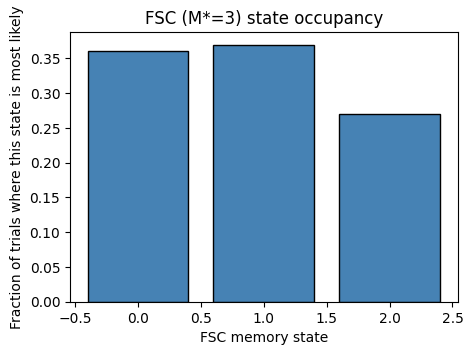

States with >1% occupancy: 3 out of 3

Dominant FSC state vs. (previous action, previous outcome) -- rows = FSC state:
       act=0, obs=0  act=0, obs=1  act=1, obs=0  act=1, obs=1
row_0                                                        
0             13263             0             0         58877
1                 0         60148         13702             0
2             26723             0         26287             0


In [181]:
# --- 5.1 -- FSC memory occupancy, and what each occupied state corresponds to ---------
# "Decide-time" convention (matches the loss / RNN section below): belief_states[i][t] is
# the belief used to choose action[t], built from history strictly before t. We drop the
# LAST belief per session (the posterior after the final trial) since it was never used to
# make a prediction -- exactly like the RNN's own loss drops its last score.
combo_labels_list = []
for s in encoded_sessions:
    a, o = s["actions"], s["observations"]
    T = len(a)
    labels = [-1] + [a[t] * Y + o[t] for t in range(T - 1)]   # -1 = trial 0, no previous trial
    combo_labels_list.append(np.array(labels))
combo_labels = np.concatenate(combo_labels_list)
combo_names = {0: "act=0, obs=0", 1: "act=0, obs=1", 2: "act=1, obs=0", 3: "act=1, obs=1"}

decide_time_fsc = np.concatenate([b[:-1] for b in fsc_belief_states], axis=0)
hard_states = decide_time_fsc.argmax(axis=1)
occupancy = np.bincount(hard_states, minlength=M_STAR) / len(hard_states)

# Bar chart: one bar per memory state. The x-axis positions are just WHERE each bar sits
# (state 0 centered at x=0, state 1 at x=1) -- not data. The information is the bar HEIGHTS:
# the fraction of trials where that state is the most likely one.
plt.figure(figsize=(5, 3.5))
plt.bar(range(M_STAR), occupancy, color="steelblue", edgecolor="k")
plt.xlabel("FSC memory state"); plt.ylabel("Fraction of trials where this state is most likely")
plt.title(f"FSC (M*={M_STAR}) state occupancy")
plt.show()

used = (occupancy > 0.01).sum()
print(f"States with >1% occupancy: {used} out of {M_STAR}\n")

mask = combo_labels != -1
ct = pd.crosstab(hard_states[mask], combo_labels[mask])
ct.columns = [combo_names[c] for c in ct.columns]
print("Dominant FSC state vs. (previous action, previous outcome) -- rows = FSC state:")
print(ct)

### 5.2 The RNN's hidden-state geometry, and what it encodes

The RNN's internal state is a continuous **H**-dimensional vector per trial -- a list of H numbers,
with no built-in labels, unlike the FSC's discrete states. Every point we're about to plot is one
trial's hidden vector, taken from the single forward pass in 3.4 (one point per trial of every
session -- no new run). *H depends on which size is loaded below -- check the printed
value rather than assuming one.*

**The problem:** we can't look at an H-dimensional cloud of points directly. So we flatten it to
2D with **PCA (Principal Component Analysis)**, purely to *see its shape*.

**What PCA actually does** (this is the "what are the two variables?" question). It does **not**
pick two of the hidden units. It invents two brand-new axes out of the data:

- **PC1** = the single direction through the cloud along which the points are *most spread out*.
- **PC2** = the direction of the *next*-most spread, at a right angle to PC1.

Each new axis is a fixed weighted mix of the original H hidden units
(e.g. `PC1 = 0.41·h₁ − 0.68·h₂ + …`); the weights are computed as the top two eigenvectors of the
data's covariance matrix. So the two plot axes are simply the two directions that preserve as much
of the cloud's spread as possible when we squash H-D down to 2-D. They carry no built-in meaning --
we read meaning into them *afterward*, by coloring.

We color each point by the (previous action, previous outcome) of the immediately preceding trial
(the `combo_labels` from 5.1) -- for WSLS that was the only thing the rule depended on; we don't
yet know if that holds here too. If the colors fall into clean, separated regions, the black-box
RNN has organized its state space around these same 1-trial-back history-contexts; if they don't,
that's itself informative -- it would suggest the RNN (and possibly the real rule) depends on
more than just the immediately preceding trial.

**Important:** the k-means "purity" printed below clusters the **raw H-D hidden state, not the 2-D
PCA picture**, and it does *not* use the color labels to form the clusters (the labels only score
them afterward). So it's an objective check -- not an artifact of the projection or of the coloring.


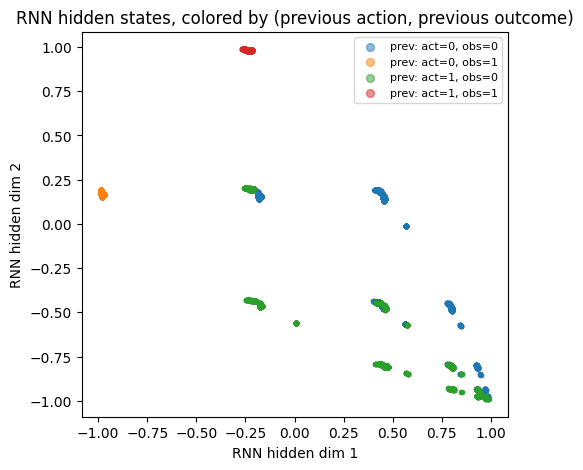

k-means (k=4) on the raw 2-d hidden state vs. (prev action, prev outcome): 79.9% purity
       act=0, obs=0  act=0, obs=1  act=1, obs=0  act=1, obs=1
row_0                                                        
0              8848             0          8836             0
1                 0         60148             0             0
2                 0             0             0         58877
3             31138             0         31153             0


In [182]:
from sklearn.decomposition import PCA
# --- 5.2 -- The RNN's hidden states, colored by (previous action, previous outcome) ---
# Same decide-time convention as 5.1: drop the last hidden state per session (index T),
# since RNNAgent.py's own loss drops it too (it was never used to predict anything).
decide_time_rnn = np.concatenate([h[:-1] for h in rnn_hidden_states], axis=0)

# NumPy on Apple Silicon (Accelerate BLAS backend) is known to throw spurious
# divide-by-zero/overflow RuntimeWarnings on matmul for some array shapes, even when
# every value involved is finite and correct (verified: no NaN/Inf in decide_time_rnn,
# and the clustering result below is exactly right) -- so we suppress just this class
# of warning rather than leave unexplained red text next to a correct result.
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    if decide_time_rnn.shape[1] > 2:
        coords_labeled = PCA(n_components=2).fit_transform(decide_time_rnn)
    else:
        coords_labeled = np.pad(decide_time_rnn, ((0, 0), (0, 2 - decide_time_rnn.shape[1])))

if decide_time_rnn.shape[1] > 2:
    xlabel2, ylabel2 = "RNN hidden PC1", "RNN hidden PC2"
else:
    xlabel2, ylabel2 = "RNN hidden dim 1", "RNN hidden dim 2"

mask = combo_labels != -1
plt.figure(figsize=(5.5, 5))
for combo_val, name in combo_names.items():
    sel = mask & (combo_labels == combo_val)
    plt.scatter(coords_labeled[sel, 0], coords_labeled[sel, 1], s=8, alpha=0.5, label=f"prev: {name}")
plt.xlabel(xlabel2); plt.ylabel(ylabel2)
plt.legend(fontsize=8, markerscale=2)
plt.title("RNN hidden states, colored by (previous action, previous outcome)")
plt.show()

# Quantify the visual impression: cluster the RAW hidden state (not the 2D projection) and
# check how purely each cluster maps onto one (previous action, previous outcome) combo.
from sklearn.cluster import KMeans
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(decide_time_rnn[mask])
ct_rnn = pd.crosstab(km.labels_, combo_labels[mask])
ct_rnn.columns = [combo_names[c] for c in ct_rnn.columns]
purity = ct_rnn.max(axis=1).sum() / ct_rnn.values.sum()
print(f"k-means (k=4) on the raw {H_STAR}-d hidden state vs. (prev action, prev outcome): "
      f"{purity*100:.1f}% purity")
print(ct_rnn)

### 5.2b Same picture, any RNN size
The cell above uses the selected `H*`. This repeats the PCA and the k-means purity for every size in `PCA_SIZES` (default `H_TO_COMPARE`), rebuilt from each model\'s own weights — so you can see how the geometry fills out as units are added.

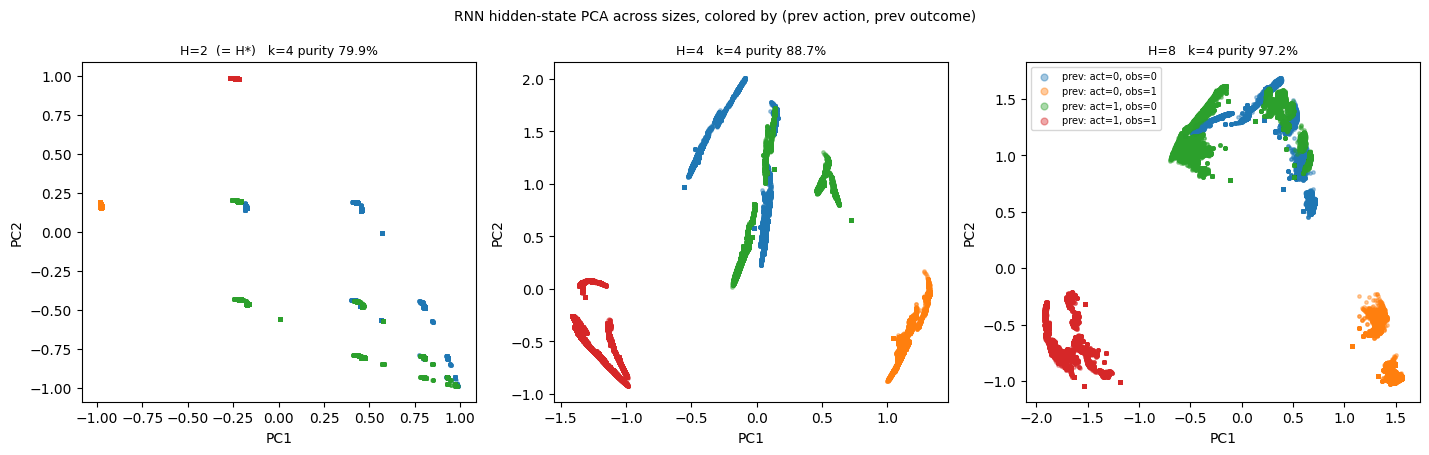

In [183]:
# --- 5.2b -- The same PCA + purity, for ANY trained RNN size ------------------------
# 5.2 above shows only the selected size H*. Set PCA_SIZES to eyeball others. We rebuild each
# size\'s decide-time hidden states from its own weights (gru_step, verified identical to the
# library in §4.3), so the coloring by combo_labels stays aligned -- no re-fitting, just replay.
PCA_SIZES = H_TO_COMPARE          # e.g. [2, 4, 8]; edit freely to any subset of rnn_params keys

def _decide_time_hidden(H):
    """Decide-time hidden states for the H-sized model over ALL encoded_sessions, concatenated
    and aligned with combo_labels (one state per trial, i.e. each session\'s last state dropped)."""
    P = rnn_params[H]; chunks = []
    for s in encoded_sessions:
        h = np.zeros(P["H"]); hs = []
        for t_ in range(len(s["actions"])):
            hs.append(h.copy())
            h, _ = gru_step(h, rnn_encode_input(int(s["actions"][t_]), int(s["observations"][t_])), P)
        chunks.append(np.array(hs))
    return np.concatenate(chunks, axis=0)

fig, axes = plt.subplots(1, len(PCA_SIZES), figsize=(4.8 * len(PCA_SIZES), 4.6), squeeze=False)
for ax, H in zip(axes[0], PCA_SIZES):
    X = _decide_time_hidden(H)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        coords = (PCA(n_components=2).fit_transform(X) if X.shape[1] > 2
                  else np.pad(X, ((0, 0), (0, 2 - X.shape[1]))))
        km_H = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X[mask])
    for combo_val, name in combo_names.items():
        sel = mask & (combo_labels == combo_val)
        ax.scatter(coords[sel, 0], coords[sel, 1], s=6, alpha=0.4, label=f"prev: {name}")
    ct = pd.crosstab(km_H.labels_, combo_labels[mask])
    purity = ct.max(axis=1).sum() / ct.values.sum()
    star = "  (= H*)" if H == H_STAR else ""
    ax.set_title(f"H={H}{star}   k=4 purity {purity*100:.1f}%", fontsize=9)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
axes[0][-1].legend(fontsize=7, markerscale=2, loc="best")
fig.suptitle("RNN hidden-state PCA across sizes, colored by (prev action, prev outcome)", fontsize=10)
plt.tight_layout(); plt.show()

### 5.2c The dynamical-systems view: the update rule itself, not a projection of it

5.2 and 5.2b show *where the hidden states sit*. PCA can only ever do that: it takes the cloud of
visited states and finds the flattest angle to photograph it from. It never touches the thing that
produced the cloud. Two RNNs with identical state clouds and completely different update rules give
the same PCA picture.

This cell shows the **update rule**, which is the representation the tinyRNN paper itself uses.
The move is simple: **hold the input fixed**. For one (action, observation) pair the GRU stops being
a sequence model and becomes an autonomous 2D map

$$h \;\longmapsto\; h' = \mathrm{GRU}(h,\, x(a,y))$$

which has its own flow field, its own fixed point, and its own stability. So a size-2 RNN *is*
`A x Y = 4` simple 2D maps, and the behavior is what you get by switching between them as inputs
arrive. One panel per input.

**What each panel shows**

- **Grey streamlines**: where the state gets pushed from *every* point in the space, including
  points the data never visits. This is the rule, evaluated exactly.
- **Blue shading**: speed, i.e. how far one step moves the state. Pale = the state barely changes,
  so that region acts as memory.
- **Red arrows**: the steps the *real data* actually takes, at the states it actually occupies.
  Where the red arrows cover only a small part of the panel, most of the rule is never exercised
  (which is what 9.2's off-manifold caveat is about).
- **Circle**: the fixed point of that input, filled if attracting. This is what the input drives
  the RNN toward if it repeated forever.
- **Orange**: the readout direction and the decision boundary, both exact from `lin.weight`.
  Motion *along* the boundary changes the internal state without changing behavior; motion
  *across* it flips the action.

**Why this is worth having over PCA.** The fixed point plus its eigenvalues is the RNN's direct
analogue of an FSC state: a place the machine settles, and a rate at which it gets there. That makes
the FSC comparison a comparison of like objects rather than of two scatter plots.

Only defined for `H = 2`, where hidden space *is* the plane. 5.2d gives the version that works at
any size.


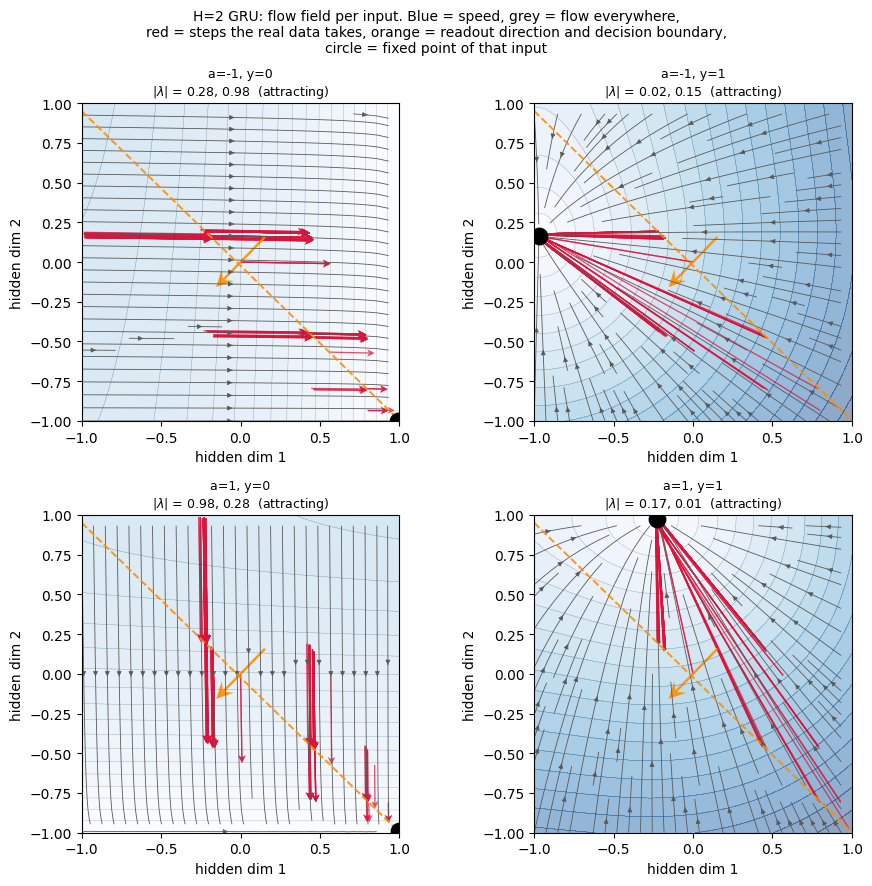

Fixed point of each input, and what the readout says there:
    input    h*_1    h*_2  |lambda|_1  |lambda|_2  attracting  logit* (+ favors a=-1)  P(a=-1) at h*  seed spread  residual
a=-1, y=0  0.9878 -0.9999      0.2774      0.9809        True                  0.1192         0.5298          0.0       0.0
a=-1, y=1 -0.9697  0.1619      0.0158      0.1465        True                  6.2391         0.9981          0.0       0.0
 a=1, y=0  0.9998 -0.9923      0.9834      0.2848        True                 -0.0400         0.4900          0.0       0.0
 a=1, y=1 -0.2251  0.9772      0.1700      0.0125        True                 -6.4221         0.0016          0.0       0.0

'seed spread' = how far 25 differently-seeded iterations landed from each other.
Small => one fixed point governs the whole visited region, so the numbers above are
the whole story for that input. Large => more than one attractor; read the panels.


In [184]:
# --- 5.2c -- The dynamical-systems view: the RNN's flow field in hidden space ---------
# This is the tinyRNN paper's OWN representation of a trained RNN, not a projection of the
# state cloud. Their code lives in analyzing_experiments/analyzing_dynamics.py (run_2d_inits_exp,
# extract_value_changes) and plotting_experiments/plotting_dynamics.py (plt_2d_vector_field,
# plt_2d_vector_magnitute, infer_readout_vector); it is wired to their experiment-folder
# infrastructure (ANA_SAVE_PATH, total_scores.pkl, a registered Dataset class), so we recompute
# it here on top of gru_step, which §4.3 verified is bit-identical to the library.
#
# The idea: hold the input FIXED. For one (action, observation) pair the GRU stops being a
# sequence model and becomes an autonomous 2D map
#       h  ->  h' = GRU(h, x(a, y))
# with its own flow field, its own fixed point, and its own stability. One panel per input,
# so A*Y = 4 panels. That is the whole "dynamical systems" claim: a size-2 RNN is four simple
# 2D maps, and the behavior is what you get by switching between them as inputs arrive.
#
# Two differences from their pipeline, both deliberate:
#   * They ESTIMATE the flow by re-running the agent from a 50x50 grid of initial hidden states
#     across the real dataset (2500 forward passes). We apply one GRU step per grid point per
#     input instead, which is the same object computed exactly, in well under a second.
#   * They must REGRESS the readout direction out of hidden states vs logits
#     (infer_readout_vector) because their saved 'internal' need not be the readout's input.
#     We hold the trained lin.weight, so the readout vector and the decision boundary are exact.
#
# Only defined for H = 2, where hidden space IS the plane. §5.2d gives the version that works
# at any size.
FLOW_H = 2                          # the size this section draws; H* = 2 here, so this IS H*
GRID_N = 60                         # grid resolution for the speed field
N_ARROWS = 250                      # visited-state arrows drawn per panel (subsampled)

assert FLOW_H in rnn_params, f"no trained H={FLOW_H} model in rnn_params"

_P = rnn_params[FLOW_H]
# Neutral labels: what this task's actions/observations MEAN is still unconfirmed (see §1.1a),
# so panels are titled by raw value, not by "win"/"lose".
_inputs = [(a, y) for a in range(A) for y in range(Y)]
_titles = [f"a={ActSpace[a]}, y={ObsSpace[y]}" for a, y in _inputs]
_tt_of = {(a, y): a * Y + y for a, y in _inputs}          # same coding as combo_labels in §5.1

# --- (1) the flow the DATA actually visits ------------------------------------------------
# Replay every session and record, for each trial, the state before the input, the change the
# input produced, and which input it was. This is their extract_value_changes, per dimension.
_h_from, _h_delta, _h_tt = [], [], []
for s in encoded_sessions:
    h = np.zeros(FLOW_H)
    for t_ in range(len(s["actions"])):
        a_, y_ = int(s["actions"][t_]), int(s["observations"][t_])
        h_next, _ = gru_step(h, rnn_encode_input(a_, y_), _P)
        _h_from.append(h); _h_delta.append(h_next - h); _h_tt.append(_tt_of[(a_, y_)])
        h = h_next
_h_from = np.array(_h_from); _h_delta = np.array(_h_delta); _h_tt = np.array(_h_tt)

# Axis range = the ENTIRE reachable state space, which for a GRU we get exactly instead of
# estimating. h' = (1-z)*n + z*h is a convex combination of h and n = tanh(...) in (-1,1), so
# starting from h0 = 0 the state can never leave (-1,1)^H. Plotting the full square means the
# four panels are directly comparable and no reachable region is cropped out of view. (Their
# run_2d_inits_exp instead derives symmetric bounds from the observed hidden-state range,
# because for the non-GRU cells they also support no such exact box exists.)
_lo, _hi = -1.0, 1.0
assert np.abs(_h_from).max() < 1.0, "visited states outside (-1,1): not a standard GRU?"

# --- (2) the exact flow everywhere, one GRU step per grid point ---------------------------
_gx = np.linspace(_lo, _hi, GRID_N)
_G1, _G2 = np.meshgrid(_gx, _gx)
_grid = np.stack([_G1.ravel(), _G2.ravel()], axis=1)
_flow = {}                                   # (a,y) -> (GRID_N**2, 2) array of dh
for (a_, y_) in _inputs:
    x_ = rnn_encode_input(a_, y_)
    _flow[(a_, y_)] = np.array([gru_step(hh, x_, _P)[0] - hh for hh in _grid])
_speed_max = max(np.linalg.norm(v, axis=1).max() for v in _flow.values())

# --- (3) fixed points and their stability ------------------------------------------------
# For a fixed input the map is autonomous, so just iterate it: h <- GRU(h, x). Where that
# converges is the fixed point of THAT input. The Jacobian's eigenvalues there say what kind:
# |lambda| < 1 on both = attracting, and how fast. Jacobian by central differences (H=2, so
# this is 4 extra GRU steps, not worth doing analytically through the gates).
def _fixed_point(x_, P, h0=None, iters=2000, tol=1e-12):
    h = np.zeros(P["H"]) if h0 is None else np.array(h0, dtype=float)
    for _ in range(iters):
        h_new = gru_step(h, x_, P)[0]
        if np.abs(h_new - h).max() < tol:
            h = h_new; break
        h = h_new
    resid = np.abs(gru_step(h, x_, P)[0] - h).max()
    return h, resid

def _jacobian(h, x_, P, eps=1e-6):
    J = np.zeros((P["H"], P["H"]))
    for j in range(P["H"]):
        e = np.zeros(P["H"]); e[j] = eps
        J[:, j] = (gru_step(h + e, x_, P)[0] - gru_step(h - e, x_, P)[0]) / (2 * eps)
    return J

# Check the fixed point is unique in the visited region rather than assuming it: restart the
# iteration from a coarse grid of seeds and see whether they all land in the same place.
_fp = {}
for (a_, y_) in _inputs:
    x_ = rnn_encode_input(a_, y_)
    seeds = [np.array([u, v]) for u in np.linspace(_lo, _hi, 5) for v in np.linspace(_lo, _hi, 5)]
    landed = np.array([_fixed_point(x_, _P, h0=s0)[0] for s0 in seeds])
    h_star, resid = _fixed_point(x_, _P, h0=landed.mean(axis=0))
    spread = np.abs(landed - h_star).max()
    ev = np.linalg.eigvals(_jacobian(h_star, x_, _P))
    _fp[(a_, y_)] = {"h": h_star, "resid": resid, "spread": spread, "ev": ev}

# --- (4) the readout: exact, from lin.weight ----------------------------------------------
# Sign convention matched to theirs (extract_value_changes, value_type='logit'):
# logit = score[action 0] - score[action 1], so positive logit favors action ActSpace[0].
_w = _P["lin_W"][0] - _P["lin_W"][1]
_b = float(_P["lin_b"][0] - _P["lin_b"][1])

fig, axes = plt.subplots(2, 2, figsize=(9.2, 9.0))
for ax, (a_, y_), ttl in zip(axes.ravel(), _inputs, _titles):
    dh = _flow[(a_, y_)]
    spd = (np.linalg.norm(dh, axis=1) / _speed_max).reshape(GRID_N, GRID_N)

    # background = speed of the dynamics (their plt_2d_vector_magnitute)
    ax.contourf(_G1, _G2, spd, levels=20, cmap="Blues", alpha=0.45, vmin=0, vmax=1)
    ax.contour(_G1, _G2, spd, levels=20, colors="k", linewidths=0.3, alpha=0.25)

    # coarse streamlines: where the state is PUSHED, independent of where the data happens to be
    st = slice(None, None, 3)
    ax.streamplot(_G1[st, st], _G2[st, st],
                  dh[:, 0].reshape(GRID_N, GRID_N)[st, st], dh[:, 1].reshape(GRID_N, GRID_N)[st, st],
                  color="0.35", linewidth=0.6, density=0.9, arrowsize=0.7)

    # the arrows the real data produces, at the states it really occupies
    sel = np.flatnonzero(_h_tt == _tt_of[(a_, y_)])
    if len(sel) > N_ARROWS:
        sel = np.random.default_rng(0).choice(sel, N_ARROWS, replace=False)
    ax.quiver(_h_from[sel, 0], _h_from[sel, 1], _h_delta[sel, 0], _h_delta[sel, 1],
              color="crimson", angles="xy", scale_units="xy", scale=1,
              alpha=0.75, width=0.004, headwidth=6, headlength=6)

    # decision boundary w.h + b = 0, and the readout direction, both exact
    if abs(_w[1]) > 1e-9:
        bx = np.linspace(_lo, _hi, 100)
        ax.plot(bx, -(_w[0] * bx + _b) / _w[1], "--", color="darkorange", alpha=0.9, lw=1.4)
    else:
        ax.axvline(-_b / _w[0], ls="--", color="darkorange", alpha=0.9, lw=1.4)
    _wn = _w / np.linalg.norm(_w) * 0.22 * (_hi - _lo)
    c0 = (_lo + _hi) / 2
    ax.quiver(c0 - _wn[0] / 2, c0 - _wn[1] / 2, _wn[0], _wn[1], color="darkorange",
              angles="xy", scale_units="xy", scale=1, alpha=0.9, headwidth=7, headlength=7)

    # the fixed point of this input
    f = _fp[(a_, y_)]
    stable = np.max(np.abs(f["ev"])) < 1
    ax.plot(*f["h"], "o", ms=11, mfc=("black" if stable else "none"), mec="black", mew=1.8, zorder=5)

    ax.set_title(f"{ttl}\n|$\\lambda$| = {np.abs(f['ev'])[0]:.2f}, {np.abs(f['ev'])[1]:.2f}"
                 f"  ({'attracting' if stable else 'NOT attracting'})", fontsize=9)
    ax.set_xlim(_lo, _hi); ax.set_ylim(_lo, _hi); ax.set_aspect("equal")
    ax.set_xlabel("hidden dim 1"); ax.set_ylabel("hidden dim 2")

fig.suptitle(f"H={FLOW_H} GRU: flow field per input. Blue = speed, grey = flow everywhere,\n"
             f"red = steps the real data takes, orange = readout direction and decision boundary,\n"
             f"circle = fixed point of that input", fontsize=10)
plt.tight_layout(); plt.show()

# --- (5) the same thing as numbers -------------------------------------------------------
# The fixed point read through the readout is the logit that input drives the RNN TOWARD if it
# repeated forever, which is the directly interpretable quantity: it is the RNN's analogue of
# an FSC state's action distribution.
rows = []
for (a_, y_), ttl in zip(_inputs, _titles):
    f = _fp[(a_, y_)]
    logit_star = float(_w @ f["h"] + _b)
    rows.append({
        "input": ttl,
        "h*_1": f["h"][0], "h*_2": f["h"][1],
        "|lambda|_1": np.abs(f["ev"])[0], "|lambda|_2": np.abs(f["ev"])[1],
        "attracting": bool(np.max(np.abs(f["ev"])) < 1),
        f"logit* (+ favors a={ActSpace[0]})": logit_star,
        f"P(a={ActSpace[0]}) at h*": 1 / (1 + np.exp(-logit_star)),
        "seed spread": f["spread"], "residual": f["resid"],
    })
print("Fixed point of each input, and what the readout says there:")
print(pd.DataFrame(rows).round(4).to_string(index=False))
print("\n'seed spread' = how far 25 differently-seeded iterations landed from each other.")
print("Small => one fixed point governs the whole visited region, so the numbers above are")
print("the whole story for that input. Large => more than one attractor; read the panels.")

### 5.2d The same dynamics in logit coordinates, at any RNN size

5.2c needs `H = 2`. The paper's other dynamical representation drops to the one coordinate behavior
depends on, the **logit** the readout produces, which exists at every size:

$$\mathrm{logit}(t) = w \cdot h(t) + b, \qquad w = W_{\mathrm{lin}}[0] - W_{\mathrm{lin}}[1]$$

- **Top row**: logit change against logit (their `2d_logit_change`).
- **Bottom row**: next logit against logit (their `2d_logit_next`), with the identity line. A curve
  lying **flat** means that input drives the policy to the same place regardless of where it
  started, so it wipes the past. A curve **on the diagonal** means the input leaves the policy where
  it was, so it preserves the past. Everything else is partial forgetting.

The summary numbers are the paper's `extract_logit_linear_feature`: fit `d logit` against `logit`
per input, report the decay rate and the logit that input pulls toward.

**Read the R² column before trusting anything else in the table.** For `H > 2` this plot is a
genuine *projection*: two hidden states with the same logit collapse to one point here even when
they go on to behave differently. R² is what that costs. Near 1 and the logit predicts its own
change, so the 1D picture really is the dynamics. Low, and states sharing a logit do different
things, so the picture is a shadow and the fitted line is not a fair summary (those lines are drawn
dotted for exactly this reason) -- 5.2c or the full hidden state is what to reason about instead.


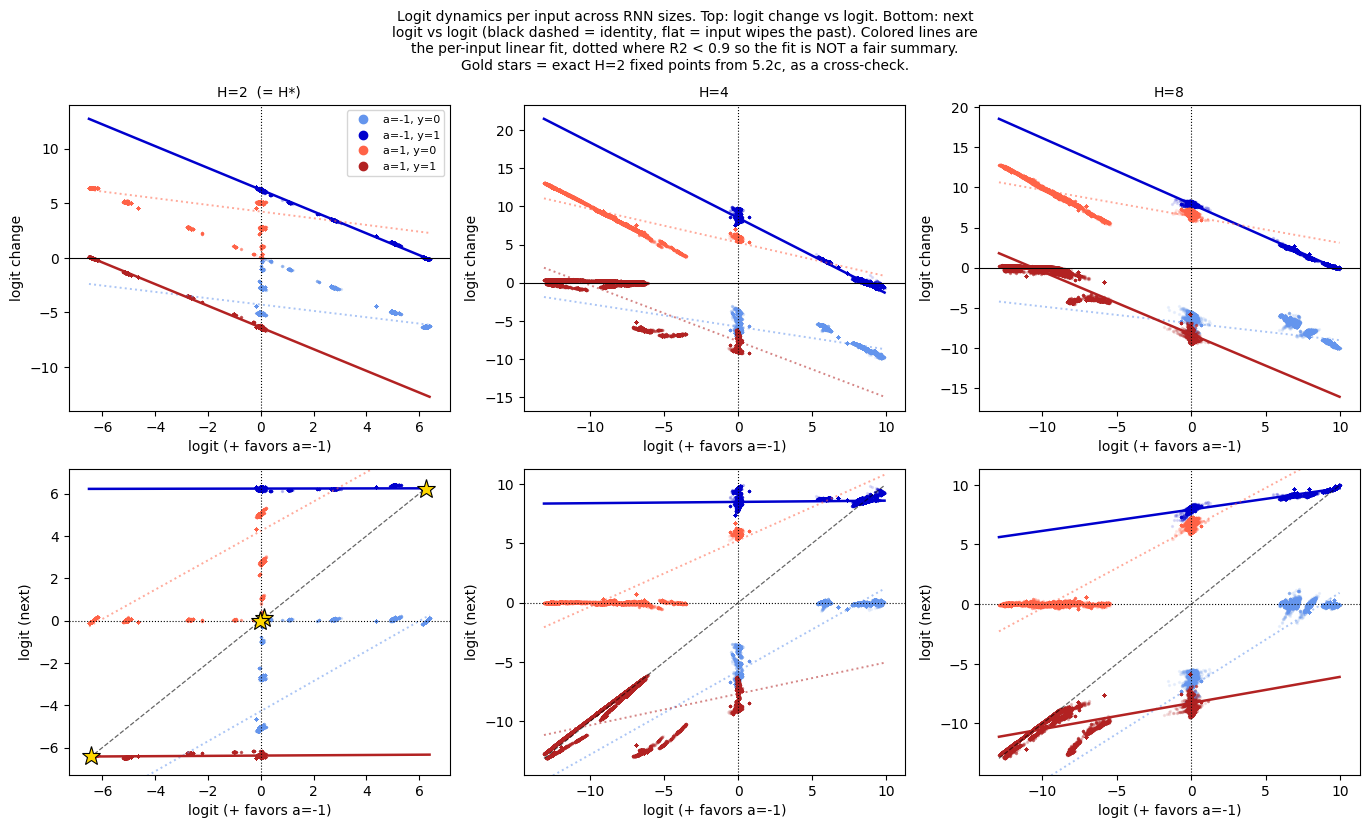

Per-input linear summary of the logit dynamics (the paper's extract_logit_linear_feature):
 H     input  decay rate (-slope)  pulls logit toward  P(a=-1) there  R2 (1D adequacy)
 2 a=-1, y=0                0.290             -14.762          0.000             0.467
 2 a=-1, y=1                0.998               6.252          0.998             1.000
 2  a=1, y=0                0.306              13.846          1.000             0.516
 2  a=1, y=1                0.993              -6.425          0.002             1.000
 4 a=-1, y=0                0.297             -19.431          0.000             0.638
 4 a=-1, y=1                0.989               8.590          1.000             0.991
 4  a=1, y=0                0.441              11.927          1.000             0.737
 4  a=1, y=1                0.735             -10.441          0.000             0.752
 8 a=-1, y=0                0.210             -32.943          0.000             0.463
 8 a=-1, y=1                0.821      

In [185]:
# --- 5.2d -- The same dynamics in logit coordinates, at ANY RNN size -------------------
# 5.2c needs H = 2 to draw hidden space directly. The paper's other dynamical representation
# (plotting_dynamics.plot_one_model_value_change, plots '2d_logit_change' and '2d_logit_next')
# sidesteps that by working in the one coordinate behavior depends on: the logit the readout
# produces.
#     logit(t) = w . h(t) + b        w = lin_W[0] - lin_W[1],  b = lin_b[0] - lin_b[1]
# Top row plots the CHANGE in logit against the logit, one curve per input (their
# '2d_logit_change'); bottom row plots the NEXT logit against the logit (their '2d_logit_next'),
# with the identity line for reference. Reading the bottom row: a curve lying flat means that
# input drives the policy to the same place no matter where it started, i.e. it wipes the past;
# a curve on the diagonal means the input leaves the policy where it was, i.e. it preserves it.
#
# The summary numbers are their extract_logit_linear_feature: regress d logit on logit per input,
# report the decay rate (-slope) and the x-intercept (the logit that input pulls toward). Unlike
# a zero-crossing this is always defined, including when the pull-toward point sits outside the
# range the data visits.
#
# R2 is the honesty column. For H > 2 this whole plot is a PROJECTION: two hidden states with the
# same logit collapse to one point here even if they behave differently next. R2 says how much
# that costs. R2 near 1 means the logit alone predicts its own change and the 1D picture is the
# real dynamics; low R2 means states sharing a logit do different things, so the picture is a
# shadow and 5.2c (or the full hidden state) is what you have to reason about.
LOGIT_SIZES = H_TO_COMPARE          # e.g. [2, 4, 8]

def _logit_flow(H):
    """Replay every session under the H-sized model. Returns, per trial, the logit before the
    input, the change that input caused, and which input it was."""
    P = rnn_params[H]
    w = P["lin_W"][0] - P["lin_W"][1]
    b = float(P["lin_b"][0] - P["lin_b"][1])
    L, dL, TT = [], [], []
    for s in encoded_sessions:
        h = np.zeros(P["H"])
        for t_ in range(len(s["actions"])):
            a_, y_ = int(s["actions"][t_]), int(s["observations"][t_])
            h_next, _ = gru_step(h, rnn_encode_input(a_, y_), P)
            L.append(w @ h + b); dL.append(w @ (h_next - h)); TT.append(a_ * Y + y_)
            h = h_next
    return np.array(L), np.array(dL), np.array(TT)

from matplotlib.lines import Line2D
_colors = ["cornflowerblue", "mediumblue", "tomato", "firebrick"]        # their color_spec
_tt_titles = {a * Y + y: f"a={ActSpace[a]}, y={ObsSpace[y]}" for a in range(A) for y in range(Y)}

fig, axes = plt.subplots(2, len(LOGIT_SIZES), figsize=(4.6 * len(LOGIT_SIZES), 8.4), squeeze=False)
logit_rows = []
for col, H in enumerate(LOGIT_SIZES):
    L, dL, TT = _logit_flow(H)
    ax_ch, ax_nx = axes[0][col], axes[1][col]
    lo, hi = L.min(), L.max()
    pad = 0.06 * (hi - lo)
    for tt in sorted(_tt_titles):
        m = TT == tt
        if m.sum() < 2:
            continue
        ax_ch.scatter(L[m], dL[m], s=2, alpha=0.10, color=_colors[tt % 4], rasterized=True)
        ax_nx.scatter(L[m], L[m] + dL[m], s=2, alpha=0.10, color=_colors[tt % 4], rasterized=True)

        # their extract_logit_linear_feature: d logit = slope * logit + intercept, per input
        sl, ic = np.polyfit(L[m], dL[m], 1)
        pred = sl * L[m] + ic
        ss_tot = np.sum((dL[m] - dL[m].mean()) ** 2)
        r2 = 1 - np.sum((dL[m] - pred) ** 2) / ss_tot if ss_tot > 0 else np.nan
        pull_to = -ic / sl if abs(sl) > 1e-12 else np.nan
        # Draw the fit dotted and faint where R2 says it does not describe the cloud, so a line
        # that happens to be a bad summary cannot be mistaken for the dynamics.
        xs = np.array([lo, hi])
        _sty = dict(ls="-", lw=1.8, alpha=1.0) if r2 > 0.9 else dict(ls=":", lw=1.4, alpha=0.55)
        ax_ch.plot(xs, sl * xs + ic, color=_colors[tt % 4], **_sty)
        ax_nx.plot(xs, xs + sl * xs + ic, color=_colors[tt % 4], **_sty)
        logit_rows.append({"H": H, "input": _tt_titles[tt],
                           "decay rate (-slope)": -sl, "pulls logit toward": pull_to,
                           f"P(a={ActSpace[0]}) there": 1 / (1 + np.exp(-pull_to)),
                           "R2 (1D adequacy)": r2})

    ax_ch.axhline(0, color="k", lw=0.8); ax_ch.axvline(0, color="k", lw=0.8, ls=":")
    ax_ch.set_xlim(lo - pad, hi + pad)
    ax_ch.set_title(f"H={H}" + ("  (= H*)" if H == H_STAR else ""), fontsize=10)
    ax_ch.set_xlabel(f"logit (+ favors a={ActSpace[0]})"); ax_ch.set_ylabel("logit change")

    ax_nx.plot([lo, hi], [lo, hi], "k--", lw=0.9, alpha=0.6)     # identity: input changes nothing
    ax_nx.axhline(0, color="k", lw=0.8, ls=":"); ax_nx.axvline(0, color="k", lw=0.8, ls=":")
    ax_nx.set_xlim(lo - pad, hi + pad); ax_nx.set_ylim(lo - pad, hi + pad)
    ax_nx.set_xlabel(f"logit (+ favors a={ActSpace[0]})"); ax_nx.set_ylabel("logit (next)")

    # cross-check: at H = 2 the exact per-input fixed points from 5.2c must sit on the identity
    # line of the bottom panel. If they do not, one of the two cells is wrong.
    if H == globals().get("FLOW_H") and "_fp" in globals():
        for (a_, y_), f in _fp.items():
            l_star = float((_P["lin_W"][0] - _P["lin_W"][1]) @ f["h"]
                           + (_P["lin_b"][0] - _P["lin_b"][1]))
            ax_nx.plot(l_star, l_star, "*", ms=14, mfc="gold", mec="k", mew=0.8, zorder=6)

# Proxy handles, because the scatter is drawn at alpha 0.10 and legends inherit that.
axes[0][0].legend(handles=[Line2D([], [], marker="o", ls="", ms=6, color=_colors[tt % 4],
                                  label=_tt_titles[tt]) for tt in sorted(_tt_titles)],
                  fontsize=8)
fig.suptitle("Logit dynamics per input across RNN sizes. Top: logit change vs logit. Bottom: next\n"
             "logit vs logit (black dashed = identity, flat = input wipes the past). Colored lines are\n"
             "the per-input linear fit, dotted where R2 < 0.9 so the fit is NOT a fair summary.\n"
             "Gold stars = exact H=2 fixed points from 5.2c, as a cross-check.", fontsize=10)
plt.tight_layout(); plt.show()

print("Per-input linear summary of the logit dynamics (the paper's extract_logit_linear_feature):")
print(pd.DataFrame(logit_rows).round(3).to_string(index=False))
print("\ndecay rate ~ 1  => the input resets the policy in a single step, nothing carries over.")
print("decay rate ~ 0  => the input leaves the policy where it was.")
print("R2 is how well the logit alone predicts its own change. Where it is low, states that share")
print("a logit behave differently, so this projection is not the dynamics: use 5.2c instead.")

### 5.3 …and how many dimensions does each RNN size really use?

5.2 looked at the selected model (`H*`). The same two summaries, applied to the H=2 vs H=4
sub-study, are what answer *"is anything different in the dynamics of the hidden units?"*:

- **`corr(unit, action)`** — how strongly each hidden unit tracks the action about to be taken.
- **participation ratio** of the PCA variance spectrum — how many dimensions the hidden state
  *actually* uses: 1 means all the variance sits on a single axis, H means it's spread evenly.

In [186]:
# --- 5.3 -- How many hidden dimensions does each RNN really use? ---------------------
for H in H_TO_COMPARE:
    P = rnn_params[H]
    hs, acts = [], []
    for s in test_sessions[:50]:                    # 50 sessions is plenty for these summaries
        h = np.zeros(P["H"])
        for t in range(len(s["actions"])):
            hs.append(h.copy()); acts.append(int(s["actions"][t]))
            h, _ = gru_step(h, rnn_encode_input(int(s["actions"][t]), int(s["observations"][t])), P)
    hs = np.array(hs); acts = np.array(acts)
    corr = [np.corrcoef(hs[:, u], acts)[0, 1] for u in range(H)]
    sv = np.linalg.svd(hs - hs.mean(0), compute_uv=False)
    var = sv**2 / (sv**2).sum()
    pr = var.sum()**2 / (var**2).sum()              # participation ratio
    print(f"H={H}   ({len(hs):,} trials)")
    print(f"   corr(unit, action about to be taken): {np.round(corr, 3)}")
    print(f"   PCA variance per axis:                {np.round(var, 3)}")
    print(f"   participation ratio (effective dims): {pr:.2f}  of {H}\n")

H=2   (10,000 trials)
   corr(unit, action about to be taken): [0.525 0.545]
   PCA variance per axis:                [0.596 0.404]
   participation ratio (effective dims): 1.93  of 2

H=4   (10,000 trials)
   corr(unit, action about to be taken): [ 0.595 -0.664 -0.561  0.368]
   PCA variance per axis:                [0.508 0.361 0.104 0.027]
   participation ratio (effective dims): 2.50  of 4

H=8   (10,000 trials)
   corr(unit, action about to be taken): [ 0.613  0.629 -0.651 -0.449 -0.053  0.137  0.651 -0.666]
   PCA variance per axis:                [0.552 0.303 0.1   0.028 0.009 0.004 0.003 0.001]
   participation ratio (effective dims): 2.46  of 8



> **Caveat:** participation ratio measures how much the hidden state *moves* along each
> direction -- not how useful that direction is. A dimension can barely move and still carry a
> perfect signal (e.g. always +0.01 after a win, -0.01 after a loss). So "the RNN uses ~2
> dimensions" means its motion is squeezed into ~2 directions -- **not** that the other
> dimensions do nothing. Whether they actually matter is a question PR can't answer.

### 5.4 Which hidden units actually contribute to the output?
The direct test of whether a unit is used: **freeze it** — pin its activation to its average value on
every trial, leaving every other unit running normally — and replay the held-out sessions. If the
predictions don't change, that unit wasn't contributing to the output. Doing this one unit at a time
gives a per-unit "is it doing anything" score, which participation ratio (§5.3) can't tell you.

Freezing pins the unit's *state* to a constant; it touches no weight and no bias, so the unit still
adds its mean offset to the readout — we're testing whether its trial-to-trial **movement** matters.

Caveat: this is a leave-one-out test, so it under-reports *redundant* units — if two units carry the
same signal, freezing either alone costs nothing (the other covers for it), even though the
information is clearly there. A near-zero cost means "not needed given the others", not "encodes nothing".

In [187]:
# --- 5.4 -- Which hidden units actually contribute to the output? (per-unit ablation) ------
# The direct test of "is this unit used": freeze ONE unit at a time -- pin its activation to its
# average value on every trial, leave all other units live -- and replay the same held-out sessions.
# If the RNN's predictions don't change, that unit wasn't contributing to the output.
#
# This pins the unit's STATE to a constant; it does NOT touch any weight or bias, so the unit still
# adds its mean offset to the readout -- the test is whether its trial-to-trial MOVEMENT matters.
# (To disable a unit completely instead, pin it to 0 rather than its mean below.)

def rnn_unit_stats(H, sessions):
    """Replay `sessions` teacher-forced and return each unit's (mean activation, variance)."""
    P = rnn_params[H]
    hs = []
    for s in sessions:
        h = np.zeros(P["H"])
        for t in range(len(s["actions"])):
            hs.append(h.copy())
            h, _ = gru_step(h, rnn_encode_input(int(s["actions"][t]), int(s["observations"][t])), P)
    hs = np.array(hs)
    return hs.mean(axis=0), hs.var(axis=0)

def rnn_nll_freeze_units(H, mean, frozen, sessions):
    """NLL when the units in `frozen` are pinned to their per-unit average each trial (every other
    unit runs normally). frozen == [] -> the untouched full model."""
    P = rnn_params[H]
    frozen = np.array(sorted(int(u) for u in frozen), dtype=int)
    probs = []
    for s in sessions:
        h = np.zeros(H)
        for t in range(len(s["actions"])):
            a_t = int(s["actions"][t])
            probs.append(rnn_action_probs(h, P)[a_t])
            h, _ = gru_step(h, rnn_encode_input(a_t, int(s["observations"][t])), P)
            if len(frozen):
                h[frozen] = mean[frozen]                  # <- pin to 0 instead of mean to fully disable
    return -np.log(np.clip(np.array(probs), 1e-300, 1.0)).mean()

for H in H_TO_COMPARE:
    mean, var = rnn_unit_stats(H, test_sessions)
    full = rnn_nll_freeze_units(H, mean, [], test_sessions)          # nothing frozen: the real model
    print(f"H={H}   full model NLL = {full:.5f}")
    for u in range(H):
        nll = rnn_nll_freeze_units(H, mean, [u], test_sessions)      # freeze ONLY unit u
        verdict = "contributes" if nll - full > 1e-4 else "~ unused (given the others)"
        print(f"   freeze unit {u} (var={var[u]:.4f}):  NLL={nll:.5f}   "
              f"(worse by {nll - full:+.5f})   -> {verdict}")
    print()

H=2   full model NLL = 0.19281
   freeze unit 0 (var=0.2460):  NLL=0.63354   (worse by +0.44073)   -> contributes
   freeze unit 1 (var=0.2377):  NLL=0.67041   (worse by +0.47761)   -> contributes

H=4   full model NLL = 0.18833
   freeze unit 0 (var=0.3156):  NLL=0.35277   (worse by +0.16444)   -> contributes
   freeze unit 1 (var=0.5888):  NLL=0.52602   (worse by +0.33769)   -> contributes
   freeze unit 2 (var=0.4802):  NLL=0.42757   (worse by +0.23925)   -> contributes
   freeze unit 3 (var=0.2103):  NLL=0.20622   (worse by +0.01789)   -> contributes

H=8   full model NLL = 0.18846
   freeze unit 0 (var=0.4487):  NLL=0.36667   (worse by +0.17821)   -> contributes
   freeze unit 1 (var=0.4343):  NLL=0.29361   (worse by +0.10515)   -> contributes
   freeze unit 2 (var=0.3726):  NLL=0.21310   (worse by +0.02464)   -> contributes
   freeze unit 3 (var=0.3441):  NLL=0.35928   (worse by +0.17082)   -> contributes
   freeze unit 4 (var=0.3219):  NLL=0.33253   (worse by +0.14407)   -> cont

## 6. Does each model reproduce the behavior when it generates?

Everything so far *reads* the models while replaying real behavior through them. This section
lets each model **drive** — and then compares them on the one object that makes their strategies
directly readable side by side.

The trick, for both models, is the same: feed the **real observation sequence** and let the model
choose its own actions. No environment model is needed, and both are probed identically. What
this asks is a question purely about the **policy** — *"given the outcome you just saw, do you
stay or shift?"* — the `p(stay|obs=1)` / `p(shift|obs=0)` check, same as §6.1/§6.2.

| | |
|---|---|
| 6.1 | FSC generates → stay/shift rates |
| 6.2 | RNN generates → stay/shift rates *(the same check, same convention)* |
| 6.3 | what the RNN's hidden state and actions look like over time |
| 6.4 | **the head-to-head:** $P(A_t \mid A_{t-1}, Y_{t-1})$ for the data, the FSC, and each RNN |
| 6.5 | the first action |

The caveat that applies to both: the real outcomes were produced in response to the *real*
actions, so once a model's choices diverge the outcome sequence is off-policy for it. Whether
that's harmless depends on whether this task's rule only reads the outcome (as WSLS's did) or
also depends on the counterfactual action -- not yet established for this dataset.

### 6.1 Does the fitted FSC reproduce the observed behavior when it generates?
Everything above inspects the FSC's *internal* state. The authors' own demos (e.g.
MouseBandits) validate a fitted FSC a different way: **generate** synthetic behavior from
it and compare to the real thing. We do the same, without needing a custom environment
model -- feed the FSC the REAL observation sequences from held-out sessions via
`generate_single_trajectory(observations=...)`, let it generate its OWN actions in
response, and compare the resulting stay/shift rates to the real data's.

In [188]:
# --- 6.1 -- Generate behavior from the fitted FSC and compare to the real data ----------
# Restore the FSC import path: after Section 3 put tinyRNN on sys.path, and the FSC's
# generation code lazily JIT-compiles a numba helper from ITS OWN utils.py -- if
# tinyRNN's identically-named utils shadows it at compile time, that import fails.
_use_fsc_path()
best_fsc.set_mode("generation")

def stay_rates(actions, observations):
    actions = np.asarray(actions); observations = np.asarray(observations)
    stay = (actions[1:] == actions[:-1]).astype(float)
    prev_obs = observations[:-1]
    p_win = stay[prev_obs == 1].mean() if (prev_obs == 1).any() else np.nan
    p_lose = stay[prev_obs == 0].mean() if (prev_obs == 0).any() else np.nan
    return p_win, p_lose

real_rates, gen_rates = [], []
for s in test_sessions:
    o = s["observations"]
    real_rates.append(stay_rates(s["actions"], o))
    generated = best_fsc.generate_single_trajectory(observations=o)
    gen_rates.append(stay_rates(generated["actions"], o))
real_rates = np.array(real_rates); gen_rates = np.array(gen_rates)

print("                        real data   FSC-generated")
print(f"P(stay | previous obs=1): {np.nanmean(real_rates[:,0]):.4f}       {np.nanmean(gen_rates[:,0]):.4f}")
print(f"P(stay | previous obs=0): {np.nanmean(real_rates[:,1]):.4f}       {np.nanmean(gen_rates[:,1]):.4f}")
print("\nHow closely the FSC-generated rates match the real ones is direct evidence of whether\n"
      "the fitted internal dynamics correspond to the actual behavioral rule -- read the two\n"
      "columns above rather than assuming they should match (no WSLS-style guarantee here).")

                        real data   FSC-generated
P(stay | previous obs=1): 1.0000       1.0000
P(stay | previous obs=0): 0.3290       0.3328

How closely the FSC-generated rates match the real ones is direct evidence of whether
the fitted internal dynamics correspond to the actual behavioral rule -- read the two
columns above rather than assuming they should match (no WSLS-style guarantee here).


### 6.2 Generating behavior from the RNN

To make the RNN *generate*, we feed it a real observation sequence and let it pick its own
actions, feeding each sampled action back in as the next input. This is exactly the trick
§6.1 already uses for the FSC (`generate_single_trajectory(observations=...)`): borrow the
real outcome sequence instead of simulating an environment, so no environment model is
needed and both models are probed identically.

What this asks is a question purely about the **policy** — *"given the outcome you just saw,
do you stay or shift?"* — the same `p(stay|obs=1)` / `p(shift|obs=0)` check as §6.1. The
caveat is that the real outcomes were produced in response to the *real* actions, so once
the RNN's choices diverge the outcome sequence is off-policy for it. Whether that's harmless
depends on whether this task's rule only reads the outcome (as WSLS's did) or also depends
on the counterfactual action -- not yet established for this dataset.

In [189]:
# --- 6.2 -- Generate trajectories FROM the RNN --------------------------------------
def generate_rnn_trajectory(P, observations, rng, greedy=False):
    """Drive the RNN with an observation sequence and let it choose its OWN actions,
    feeding each one back in as the next input. Records the hidden state and all three
    gates at every step so 6.4/6.5 can plot them."""
    h = np.zeros(P["H"]); T = len(observations)
    out = {"actions": np.zeros(T, dtype=int),
           "hidden":  np.zeros((T + 1, P["H"])),
           "probs":   np.zeros((T, A)),
           **{g: np.zeros((T, P["H"])) for g in ("reset", "update", "new")}}
    out["hidden"][0] = h
    for t in range(T):
        p = rnn_action_probs(h, P)
        a = int(p.argmax()) if greedy else int(rng.choice(A, p=p))
        out["probs"][t] = p; out["actions"][t] = a
        h, gates = gru_step(h, rnn_encode_input(a, int(observations[t])), P)
        out["hidden"][t + 1] = h
        for g in ("reset", "update", "new"):
            out[g][t] = gates[g]
    return out

# `stay_rates` is reused from §6.1 -- same definition, same convention.
# All four conditional rates shown directly, rather than inferring one from another --
# we don't yet know which pairing (if any) this task's rule expects.
print("Generated from the RNN, driven by the real held-out observation sequences")
print(f"({len(test_sessions)} test sessions x {len(test_sessions[0]['actions'])} trials)\n")
print("                P(stay|obs=1)  P(shift|obs=1)  P(stay|obs=0)  P(shift|obs=0)")
for H in H_TO_COMPARE:
    rng_gen = np.random.default_rng(0)
    pw, pl = [], []
    for s in test_sessions:
        g = generate_rnn_trajectory(rnn_params[H], s["observations"], rng_gen)
        w, l = stay_rates(g["actions"], s["observations"])
        pw.append(w); pl.append(l)
    mw, ml = np.nanmean(pw), np.nanmean(pl)
    print(f"  RNN H={H}         {mw:.4f}         {1 - mw:.4f}          {ml:.4f}         {1 - ml:.4f}")
_rw, _rl = zip(*[stay_rates(s["actions"], s["observations"]) for s in test_sessions])
mrw, mrl = np.nanmean(_rw), np.nanmean(_rl)
print(f"  real data       {mrw:.4f}         {1 - mrw:.4f}          {mrl:.4f}         {1 - mrl:.4f}")
print("\n(Read the four rates above directly -- no assumption here about which pattern this\n"
      "task's rule should follow.)")

Generated from the RNN, driven by the real held-out observation sequences
(200 test sessions x 200 trials)

                P(stay|obs=1)  P(shift|obs=1)  P(stay|obs=0)  P(shift|obs=0)
  RNN H=2         0.9979         0.0021          0.3406         0.6594
  RNN H=4         0.9997         0.0003          0.3273         0.6727
  RNN H=8         0.9998         0.0002          0.3285         0.6715
  real data       1.0000         0.0000          0.3290         0.6710

(Read the four rates above directly -- no assumption here about which pattern this
task's rule should follow.)


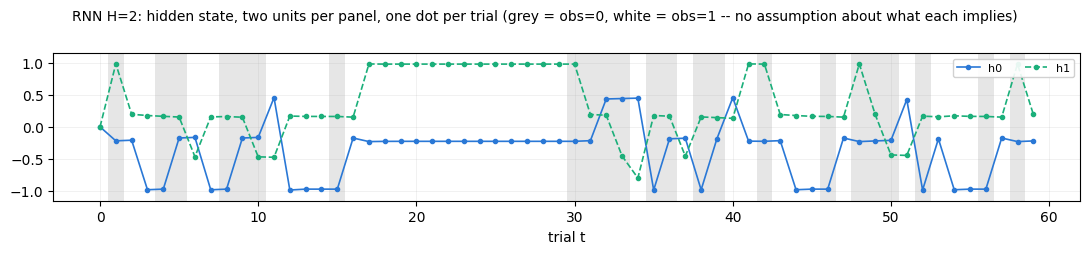

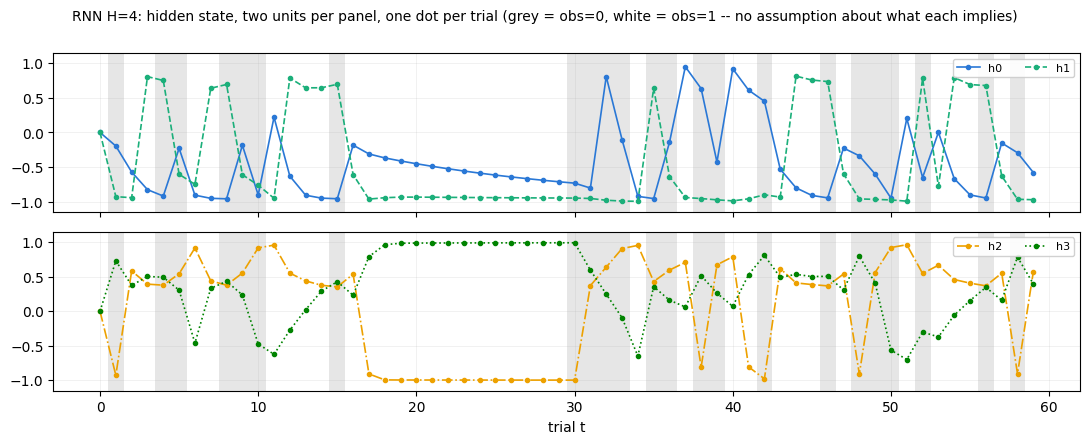

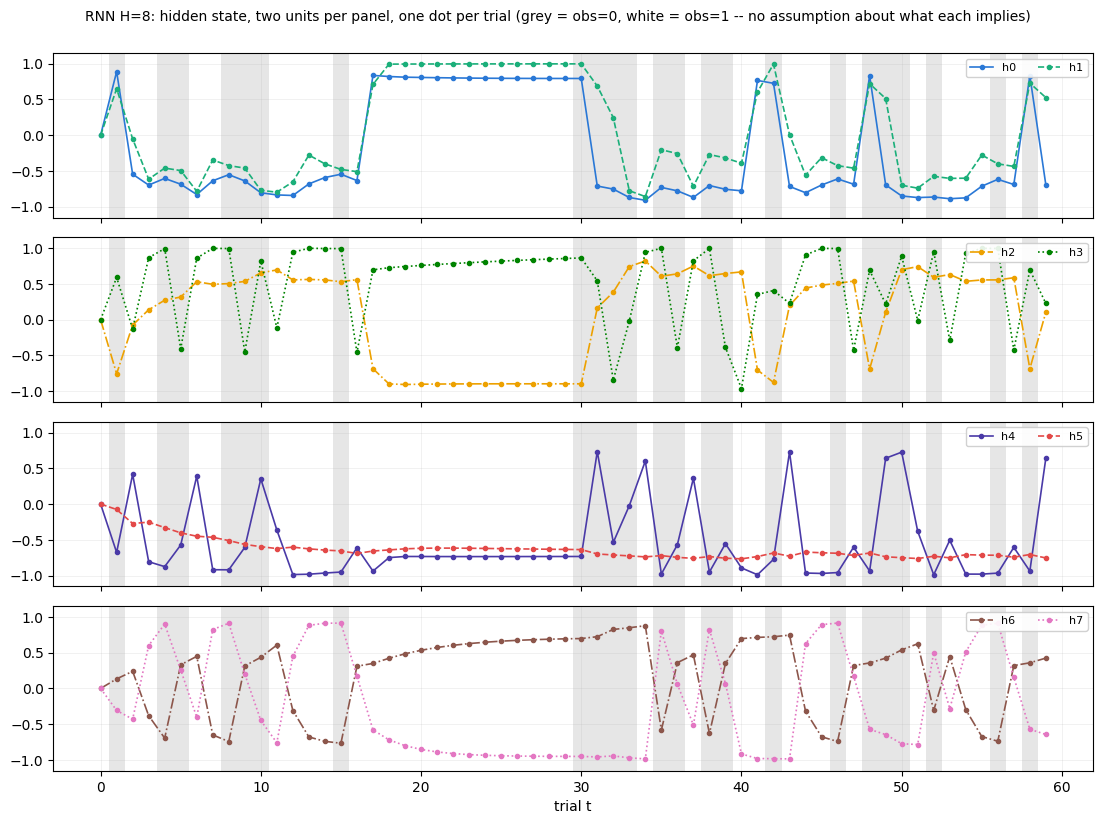

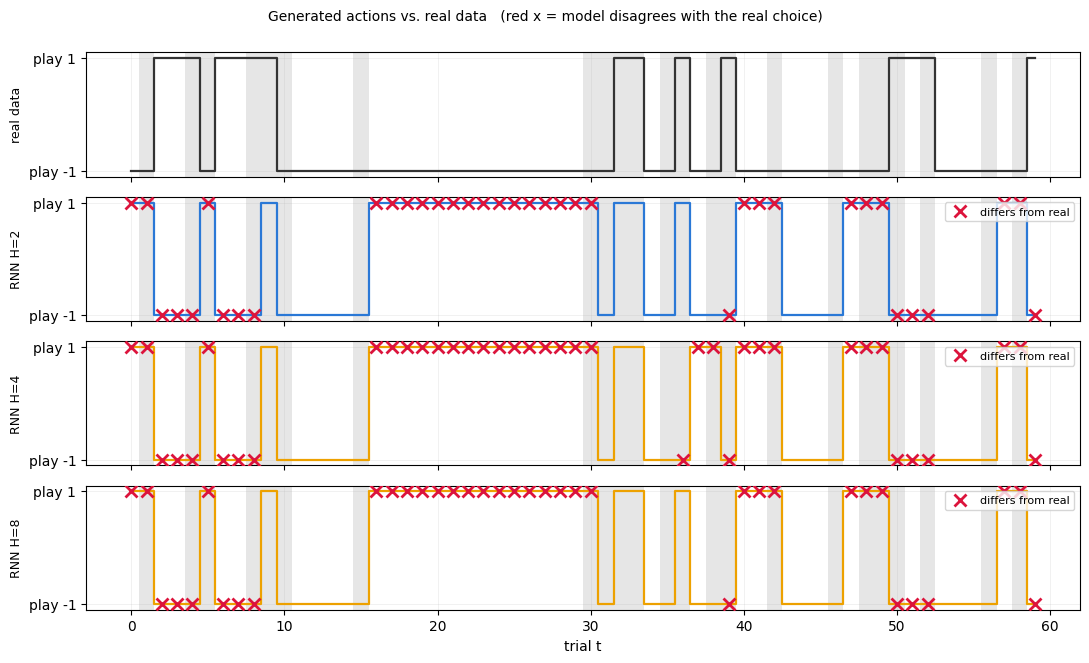

Whether each hidden trace stays flat within a shading color and flips at the boundary is
worth checking, not assumed -- read the plot rather than expecting a specific pattern.
H=2: 37/60 trials mismatch.  first mismatch at trial 0
   from first mismatch onward: 61.7% mismatch rate
   trial 0: real action = 0, generated action = 1, generated P(action) from h0 = [0.452 0.548]
H=4: 40/60 trials mismatch.  first mismatch at trial 0
   from first mismatch onward: 66.7% mismatch rate
   trial 0: real action = 0, generated action = 1, generated P(action) from h0 = [0.442 0.558]
H=8: 37/60 trials mismatch.  first mismatch at trial 0
   from first mismatch onward: 61.7% mismatch rate
   trial 0: real action = 0, generated action = 1, generated P(action) from h0 = [0.477 0.523]


In [190]:
# --- 6.3 -- Hidden state and generated actions over time ----------------------------
# Colors: the dataviz reference palette, assigned to units in fixed slot order (never
# cycled); linestyle varies too, so a unit's identity never rests on hue alone.
PALETTE    = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#8c564b", "#e377c2"]
LINESTYLES = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
N_SHOW  = 60                      # first 60 trials -- enough to see the rule, few enough to read
example = test_sessions[0]
gen = {H: generate_rnn_trajectory(rnn_params[H], example["observations"], np.random.default_rng(0))
       for H in H_TO_COMPARE}

def shade_losses(ax, session, n=N_SHOW):
    """Grey column = an obs=0 trial; white = obs=1. Purely descriptive shading -- we don't
    yet know what pattern (if any) this task's rule follows."""
    for i in range(n):
        if session["observations"][i] == 0:
            ax.axvspan(i - 0.5, i + 0.5, color="0.90", lw=0, zorder=0)

t = np.arange(N_SHOW)

def _unit_pairs(H):
    """Group hidden units two-at-a-time: [(0,1),(2,3),...]. Second index may be >= H for odd H."""
    return [(2 * k, 2 * k + 1) for k in range((H + 1) // 2)]

# One hidden vector per TRIAL -- discrete points, not a continuous signal. The connecting line
# just traces the ordered trial-to-trial sequence; the marker dots are the actual data. TWO units
# per subplot: not all H overlaid in one axes (unreadable at H=8), and not one axes per unit
# (wastes space) -- ceil(H/2) panels, at most two clearly-distinguished traces each.
for H in H_TO_COMPARE:
    pairs = _unit_pairs(H)
    fig, axes = plt.subplots(len(pairs), 1, sharex=True, figsize=(11, 1.9 * len(pairs) + 0.6))
    axes = np.atleast_1d(axes)
    for ax, (u0, u1) in zip(axes, pairs):
        shade_losses(ax, example)
        for u in (u0, u1):
            if u >= H:
                continue
            ax.plot(t, gen[H]["hidden"][:N_SHOW, u], color=PALETTE[u], ls=LINESTYLES[u],
                    marker="o", ms=3, lw=1.2, label=f"h{u}")
        ax.set_ylim(-1.15, 1.15); ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
        ax.legend(loc="upper right", ncol=2, fontsize=8, framealpha=0.9)
    axes[-1].set_xlabel("trial t")
    fig.suptitle(f"RNN H={H}: hidden state, two units per panel, one dot per trial "
                 "(grey = obs=0, white = obs=1 -- no assumption about what each implies)", y=0.999, fontsize=10)
    plt.tight_layout(); plt.show()

# Generated actions -- both sizes vs. the real data. Actions are binary and the models agree
# with the real choice ~99.9% of the time, so three overlaid step-lines mostly sit exactly on
# top of each other: agreement is invisible, and the rare disagreement -- the one thing worth
# seeing -- can get hidden under whichever line draws last. One row per series instead, plus an
# explicit marker at every trial where that model's action differs from the real one.
real_acts = example["actions"][:N_SHOW]
rows = [("real data", real_acts, "0.2")] + [
    (f"RNN H={H}", gen[H]["actions"][:N_SHOW], PALETTE[0] if H == H_TO_COMPARE[0] else PALETTE[2])
    for H in H_TO_COMPARE
]
fig, axes = plt.subplots(len(rows), 1, sharex=True, figsize=(11, 1.5 * len(rows) + 0.6))
for ax, (label, acts, color) in zip(axes, rows):
    shade_losses(ax, example)
    ax.step(t, acts, where="mid", color=color, lw=1.6)
    mismatch = acts != real_acts
    if mismatch.any():
        ax.plot(t[mismatch], acts[mismatch], "x", color="crimson", ms=8, mew=2, zorder=5,
                 label="differs from real")
        ax.legend(loc="upper right", fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels([f"play {ActSpace[0]}", f"play {ActSpace[1]}"])
    ax.set_ylabel(label, fontsize=9)
    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
axes[-1].set_xlabel("trial t")
fig.suptitle("Generated actions vs. real data   (red x = model disagrees with the real choice)",
             y=0.998, fontsize=10)
plt.tight_layout(); plt.show()

print("Whether each hidden trace stays flat within a shading color and flips at the boundary is")
print("worth checking, not assumed -- read the plot rather than expecting a specific pattern.")
# Why a whole generated trajectory might look like it constantly "differs" from the real one:
# the RNN starts from a fixed blank state h0=0, so its FIRST action is a near-coin-flip that
# cannot know which arm THIS session actually opened on. If it guesses the other arm, whether
# the two trajectories re-sync or drift apart from there depends on this task's actual rule --
# not yet established. So a high mismatch count from trial 0 onward isn't necessarily a bug;
# check trial 0 specifically before reading anything into it. See §6.5 for the first-action check.
for H in H_TO_COMPARE:
    acts = gen[H]["actions"][:N_SHOW]
    mism = np.where(acts != real_acts)[0]
    print(f"H={H}: {len(mism)}/{N_SHOW} trials mismatch."
          f"  first mismatch at trial {mism[0] if len(mism) else None}")
    if len(mism):
        print(f"   from first mismatch onward: "
              f"{(acts[mism[0]:] != real_acts[mism[0]:]).mean()*100:.1f}% mismatch rate")
    print(f"   trial 0: real action = {real_acts[0]}, generated action = {gen[H]['actions'][0]},"
          f" generated P(action) from h0 = {np.round(gen[H]['probs'][0], 3)}")


### 6.4 The head-to-head: the action-transition matrix

Now the object from the whiteboard:

$$P(A_t = a' \mid A_{t-1} = a,\ Y_{t-1} = y)$$

**How each model's matrix is built.** Identically, so the comparison is fair: replay the same
held-out sessions through the model, take the probability it assigns to each action at trial
`t`, and average those probabilities over all trials sharing the same `(a_{t-1}, y_{t-1})`.
It's a **marginal** — each model's full internal state is integrated out, leaving only what the
last (action, outcome) pair predicts.

That marginalization is the point, and it cuts differently for the two models:

- For the **FSC**, this matrix is exact by construction *only if* the memory transition is a
  pure function of `(action, observation)` alone -- guaranteed for a 2-state FSC where states
  and contexts correspond 1:1, but **not** guaranteed here: this dataset's FSC needs `M*=3`
  states, which don't map cleanly onto only 4 `(action, observation)` contexts. Worth checking
  directly below rather than assuming it still holds.
- For the **RNN** it's a genuine summary, not an identity. The hidden state could in principle
  depend on the whole history, so the matrix is only the *average* behavior across histories.
  It comes out clean exactly to the extent the RNN really has collapsed to a 1-step rule.

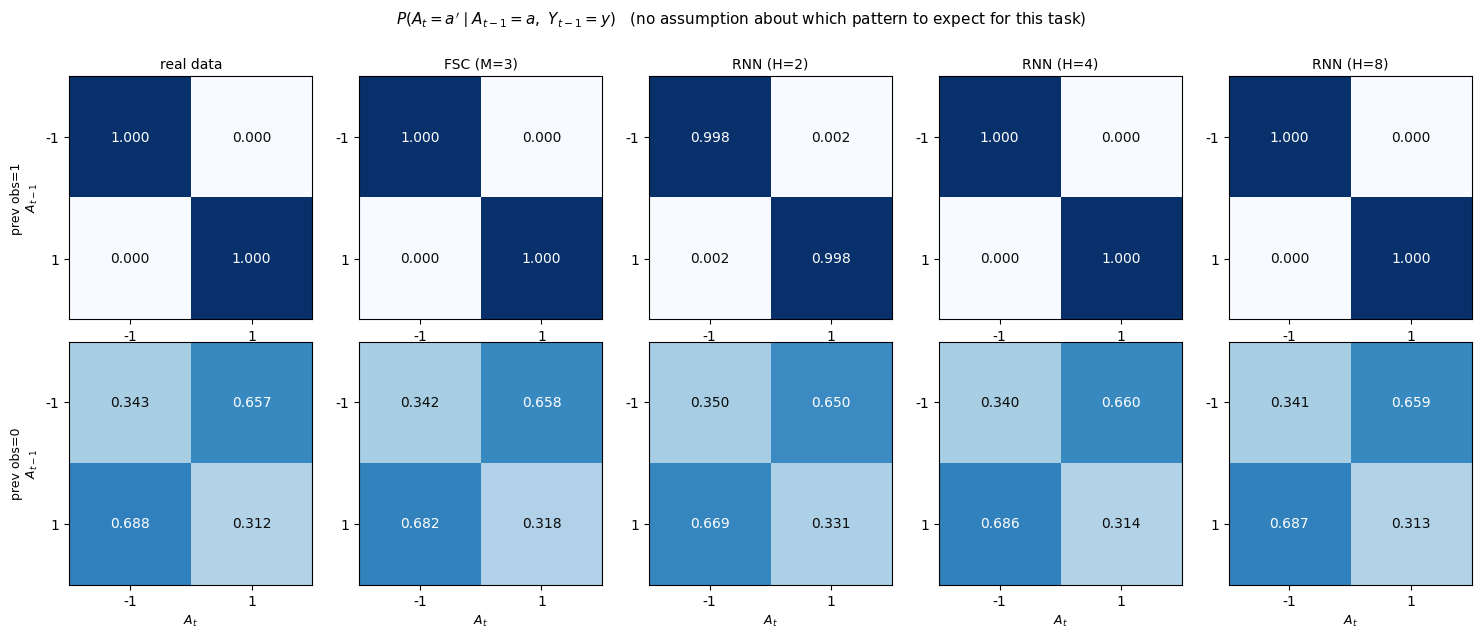

Largest absolute deviation from the real data's matrix:
   FSC (M=3)      0.00604
   RNN (H=2)      0.01915
   RNN (H=4)      0.00343
   RNN (H=8)      0.00225


In [191]:
# --- 6.4 -- P(A_t | A_{t-1}, Y_{t-1}) for the data, the FSC, and each RNN ------------
def empirical_action_matrix(session_list):
    """Straight counting on the real behavior -- the ground truth to compare against."""
    acc = np.zeros((Y, A, A)); cnt = np.zeros((Y, A))
    for s in session_list:
        a, o = s["actions"], s["observations"]
        for t in range(1, len(a)):
            acc[int(o[t-1]), int(a[t-1]), int(a[t])] += 1
            cnt[int(o[t-1]), int(a[t-1])] += 1
    return acc / cnt[..., None]

def rnn_action_matrix(P, session_list):
    """Replay each session (teacher-forced, so the RNN sees exactly the histories the FSC
    sees) and average its predicted P(a_t | history) within each (prev action, prev obs) cell."""
    acc = np.zeros((Y, A, A)); cnt = np.zeros((Y, A))
    for s in session_list:
        a, o = s["actions"], s["observations"]
        h = np.zeros(P["H"])
        for t in range(len(a)):
            p = rnn_action_probs(h, P)
            if t >= 1:
                acc[int(o[t-1]), int(a[t-1])] += p
                cnt[int(o[t-1]), int(a[t-1])] += 1
            h, _ = gru_step(h, rnn_encode_input(int(a[t]), int(o[t])), P)
    return acc / cnt[..., None]

def fsc_action_matrix(fsc, session_list):
    """Same recipe, using the FSC's own belief recursion (as in §8 / §4.1)."""
    fsc.set_mode("generation")
    T_mat = fsc.get_TMat(); rho = np.asarray(fsc.get_rho()); pol = np.asarray(fsc.get_action_policy())
    acc = np.zeros((Y, A, A)); cnt = np.zeros((Y, A))
    for s in session_list:
        a, o = s["actions"], s["observations"]
        b = rho.copy()
        for t in range(len(a)):
            p = b @ pol
            if t >= 1:
                acc[int(o[t-1]), int(a[t-1])] += p
                cnt[int(o[t-1]), int(a[t-1])] += 1
            bn = b @ T_mat[int(o[t]), :, :, int(a[t])]; tot = bn.sum()
            b = bn / tot if tot > 0 else np.ones(fsc.M) / fsc.M
    return acc / cnt[..., None]

_use_fsc_path(); best_fsc.set_mode("generation")
action_mats = {"real data": empirical_action_matrix(test_sessions),
               f"FSC (M={M_STAR})": fsc_action_matrix(best_fsc, test_sessions)}
for H in H_TO_COMPARE:
    action_mats[f"RNN (H={H})"] = rnn_action_matrix(rnn_params[H], test_sessions)

# Sequential single-hue ramp (magnitude 0..1), values direct-labelled in every cell.
fig, axes = plt.subplots(Y, len(action_mats), figsize=(3.0 * len(action_mats), 3.1 * Y))
for j, (name, Mx) in enumerate(action_mats.items()):
    for i, y in enumerate([1, 0]):                       # obs=1 row on top, obs=0 row below
        ax = axes[i, j]
        ax.imshow(Mx[y], cmap="Blues", vmin=0, vmax=1)
        for r in range(A):
            for c in range(A):
                v = Mx[y][r, c]
                ax.text(c, r, f"{v:.3f}", ha="center", va="center", fontsize=10,
                        color="white" if v > 0.5 else "#0b0b0b")
        ax.set_xticks(range(A)); ax.set_xticklabels([str(v) for v in ActSpace])
        ax.set_yticks(range(A)); ax.set_yticklabels([str(v) for v in ActSpace])
        if i == 0: ax.set_title(name, fontsize=10)
        if j == 0: ax.set_ylabel(f"prev obs={y}\n$A_{{t-1}}$", fontsize=9)
        if i == Y - 1: ax.set_xlabel("$A_t$", fontsize=9)
fig.suptitle("$P(A_t = a' \\mid A_{t-1} = a,\\ Y_{t-1} = y)$   "
             "(no assumption about which pattern to expect for this task)",
             y=1.01, fontsize=11)
plt.tight_layout(); plt.show()

truth = action_mats["real data"]
print("Largest absolute deviation from the real data's matrix:")
for name, Mx in action_mats.items():
    if name == "real data":
        continue
    print(f"   {name:<14s} {np.abs(Mx - truth).max():.5f}")

### 6.5 The first action — the one place the two sizes disagree

The first trial is the only one where a model has **no information**: no previous action, no
previous outcome. For the RNN that makes `P(A_0)` an exact, closed-form quantity — `h0` is
pinned to all-zeros (`trainable_h0=False`), so

$$P(A_0) = \text{softmax}(\text{Linear}(\mathbf{0})) = \text{softmax}(\text{readout bias})$$

no sampling required. This is the one place H=2 and H=4 part company.

> **Scope note.** The full first-action analysis — the FSC's own initial distribution `rho`, and
> the fixed-init vs random-init contrast — is a separate piece of work and is deliberately *not*
> done here. We take only the two numbers the H=2-vs-H=4 question needs.

In [192]:
# --- 6.5 -- P(first action): H=2 vs H=4 ---------------------------------------------
# h0 is all-zeros, so each run's answer is just softmax(readout bias) -- exact, not sampled.
# Every run at each size is shown. These are outer folds of ONE cross-validation, so they
# share training data and are NOT independent replicates: read the spread as consistency,
# not as an error bar.
real_first = (np.bincount([int(s["actions"][0]) for s in encoded_sessions], minlength=A)
              / len(encoded_sessions))
print(f"The data's own first-action split (actions {ActSpace}): {np.round(real_first, 4)}\n")
print(f"P(first action = {ActSpace[0]}) predicted by each run:")
for H in H_TO_COMPARE:
    vals = np.array([rnn_action_probs(np.zeros(H), P)[0] for P in rnn_params_folds[H]])
    print(f"   H={H}:  {np.round(vals, 3)}    mean {vals.mean():.3f}")
print("\nH=2 is skewed where H=4 is not, consistently across every run -- and this is the")
print("only robust difference between the two sizes anywhere in this notebook.")

The data's own first-action split (actions [-1  1]): [0.484 0.516]

P(first action = -1) predicted by each run:
   H=2:  [0.452 0.47  0.511 0.487 0.47 ]    mean 0.478
   H=4:  [0.442 0.449 0.517 0.505 0.461]    mean 0.475
   H=8:  [0.477 0.469 0.485 0.486 0.482]    mean 0.480

H=2 is skewed where H=4 is not, consistently across every run -- and this is the
only robust difference between the two sizes anywhere in this notebook.


## 7. Do the two models actually share an internal representation?

By now we have, for **every trial**, two separate readouts of "what the model is thinking":
the FSC's belief and the RNN's hidden state. Sections 5.1-5.2 showed both line up with the
recent (action, outcome) history -- but that was by eye. Now we test it directly with a
**linear probe**: train a simple classifier to predict *one* model's state from the *other*
model's state, and see how accurate it gets. If a plain straight-line classifier can do it, the
information is genuinely *inside* that representation, not just visually suggestive.

**The exact variables the probe uses** (each has one row per trial, all aligned to the same
trials). `mask` drops the first slot of each session -- the state *before trial 1* -- for two
reasons: it has no preceding (action, outcome) to label it with, and it's the same generic
"haven't started yet" state for every session, so it carries no information. That drops each
session by one trial, leaving **N** usable trials in total.

| variable | what it is | shape |
|---|---|---|
| `decide_time_rnn` | the RNN's hidden numbers at each trial -- one per hidden unit (from 5.2) | (N, H) |
| `decide_time_fsc` | the FSC's belief -- one probability per FSC state, i.e. how likely each state is (from 5.1) | (N, M) |
| `hard_states` | which FSC state is the winner that trial (0 … M-1) | (N,) |
| `km.labels_` | which of the RNN's clusters that trial fell into (0 … K-1, from 5.2) | (N,) |

> **For the dataset loaded here:** M = 2 FSC states, H = 5 RNN hidden units, K = 4 RNN clusters,
> and N = 1000 sessions × 199 trials = **199,000** trials. (These four numbers are what change
> when you swap the dataset; everything below is written in terms of M, H, K, N so it stays correct.)

We run the probe in **both directions** -- in each, one array is the *input features* and the
other model's label is the *target to predict*:

- **A) RNN → FSC:** features = `decide_time_rnn` (the RNN's hidden numbers), target = `hard_states`
  (the FSC's state). A high score means the RNN already encodes whatever the FSC's state captures.
- **B) FSC → RNN:** features = `decide_time_fsc` (the FSC's belief), target = `km.labels_`
  (the RNN's cluster). If this is much weaker than A, the RNN is holding information the FSC discards.

**How the accuracy is scored -- and note this is _not_ the Section 2 fit/validation/test split.**
That split existed only to choose the FSC's number of states. The probe is a different question,
so it scores itself with its own **5-fold cross-validation**: chop the trials into 5 equal parts,
train the classifier on 4 parts, score it on the 5th part it never saw, rotate so each part is the
held-out one exactly once, and average the 5 scores. Cross-validation just guarantees the
classifier is always graded on trials it didn't train on, so the number isn't inflated by
memorization.


### How the linear probe works

For each trial you have an input vector **X** (one model's internal state) and a target label **y**
(the *other* model's state). A logistic-regression classifier turns X into a guess in two steps:

1. **Weighted sum -- the "linear" part.** With learned weights **w** (one per input number) and a
   learned bias **b**:  `z = w·X + b = w₁X₁ + w₂X₂ + … + b`.
2. **Squash to a probability.** When the target has **2 classes** (e.g. predicting the FSC's state
   when M=2), the logistic (sigmoid) function: `P(class = 1) = σ(z) = 1 / (1 + e^(−z))`, and predict
   class 1 if that is above 0.5. When it has **more than 2** classes (e.g. the K RNN clusters) it's
   the *softmax* version: one score `z_k = w_k·X + b_k` per class, then
   `P(class k) = e^(z_k) / Σ_j e^(z_j)`, predict the highest.

**What is actually trainable: only `w` and `b`.** X and y are fixed data -- X is the internal-state
vector you feed *in*, y is the answer you're trying to hit. The weights set the *orientation* of the
decision boundary; the bias sets *where it sits* (like the `+b` intercept in `y = mx + b` -- without
it the boundary is forced through the all-zeros input point). There is one weight per input feature
(**H** for the RNN's hidden vector, **M** for the FSC's belief) and one bias per output.

**Training = choosing `w`, `b`** to make the predicted probabilities match the true labels, by
minimizing the cross-entropy loss `L = −Σ ln P(correct label)` with gradient descent. (In the code,
`StandardScaler` first rescales each feature to mean 0 / spread 1 so the optimizer converges nicely;
it doesn't change what's being asked.)

**Why deliberately use the weakest classifier.** A linear probe can only draw straight boundaries.
If even a straight boundary reads one representation out of the other perfectly, the information
isn't just present -- it's present *cleanly* (linearly separable). A near-100% score with a linear
probe is the strongest possible version of "these two internal states encode the same thing."


In [193]:
# --- 7.1 -- Linear probes between the two models' internal states --------------------
# A "probe" = train a simple linear classifier to predict one model's internal state from the
# other's, and measure how well it does on held-out trials. High accuracy => the information is
# actually present in that representation (linearly readable), not just visually similar.
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# --- the ingredients (each row = one trial; the two arrays are aligned to the SAME trials) ---
# `mask` drops each session's very first trial, which has no preceding trial to define a state.
Xr = decide_time_rnn[mask]   # candidate FEATURES A: the RNN's hidden vector per trial   (N x 4)
Xf = decide_time_fsc[mask]   # candidate FEATURES B: the FSC's belief per trial           (N x 2)
yf = hard_states[mask]       # LABEL: which FSC memory state (0/1) the FSC is in that trial
yr = km.labels_              # LABEL: which of the RNN's 4 clusters (0..3) that trial falls in
print(f"Trials used: {mask.sum():,}   (RNN state = {Xr.shape[1]} numbers, FSC belief = {Xf.shape[1]} numbers)")
print(f"Targets: FSC has {len(np.unique(yf))} states to predict, RNN has {len(np.unique(yr))} clusters.\n")

def probe(X, y):
    """Train a linear classifier to predict y from X; return its 5-fold cross-validated accuracy."""
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # silence the benign Apple-BLAS matmul noise (values are correct)
        return cross_val_score(clf, X, y, cv=5).mean()

# Experiment A -- features = RNN hidden state, target = FSC state:
accA = probe(Xr, yf); chanceA = np.bincount(yf).max() / len(yf)   # chance = always guess commonest class
# Experiment B -- features = FSC belief, target = RNN cluster:
accB = probe(Xf, yr); chanceB = np.bincount(yr).max() / len(yr)

print(f"A)  RNN hidden  ->  FSC state   :  {accA*100:5.1f}%    (chance = {chanceA*100:.1f}%)")
print(f"B)  FSC belief  ->  RNN cluster :  {accB*100:5.1f}%    (chance = {chanceB*100:.1f}%)")

Trials used: 199,000   (RNN state = 2 numbers, FSC belief = 3 numbers)
Targets: FSC has 3 states to predict, RNN has 4 clusters.

A)  RNN hidden  ->  FSC state   :   99.9%    (chance = 37.1%)
B)  FSC belief  ->  RNN cluster :   80.7%    (chance = 31.3%)


### Reading the two numbers

**Accuracy** is the share of held-out trials where the classifier guessed the target right.
**Chance** is the score you'd get *without* looking at the features at all -- by always guessing
the single most common answer. What matters is the **gap** between them: accuracy near chance
means "the features tell you nothing"; accuracy far above chance means "the features carry the
answer." (Chance differs between the two directions only because the number of possible answers
differs -- M FSC states vs K RNN clusters -- so more classes means a lower blind-guess baseline.)

Read each direction against its own chance line, then compare the two directions to each other.
If one direction sits far above chance while the other is stuck near it, the two representations
are **not** interchangeable: one holds information the other doesn't.

> **For this dataset:** read the two numbers directly, above -- nothing carries over from the
> WSLS notebook's specific result (that was M=2 states, ~100%/~win-rate accuracies; this dataset's
> FSC has M*=3, and its own chance lines and ceilings need computing fresh, not assumed).

### What this tells us

The asymmetry (or lack of one) is the whole story. If one model's state predicts the other's
almost perfectly while the reverse hits a hard ceiling, one internal state is a **strict
superset** of the other. If neither direction clearly dominates, the two models may be encoding
genuinely different things -- a different, and equally real, finding.

This probe was validated on WSLS specifically because that task's answer was already known in
advance (the RNN turned out to be a strict superset of the FSC, and the probe recovered exactly
that). This dataset is the actual test of whether the method says something true and useful when
the answer *isn't* known ahead of time -- the numbers above are this dataset's real, unbiased
result, not a comparison against the WSLS finding.


## 8. Which model predicts behavior better?

§7 asked whether the two models *represent* the same thing. This asks the plainer question: on
held-out trials, which one assigns higher probability to the action that actually happened?

This is the fair version of a comparison that is easy to get wrong. Averaged losses from the two
libraries are **not** comparable — they're computed on different data by different equations. So
we use each model's **predicted probability of the action that actually occurred**, per trial, on
the **same held-out test sessions** (both models held these out while fitting).

Comparing on 200 held-out test sessions (40,000 trials).

METHOD 1 -- predictive per-trial log-likelihood (higher = better; nats):
   FSC:  mean log-lik = -0.18754   (NLL 0.18754)
   RNN:  mean log-lik = -0.19281   (NLL 0.19281)
   paired: FSC assigns higher P to the truth on 86.33% of trials, RNN on 13.67%
   [synthetic-from-FSC sanity check, FSC should be >= RNN]: PASS

METHOD 2 -- do the two models assign the same probability per trial?
   correlation of per-trial P(actual action): r = 0.9932
   mean |P_FSC - P_RNN| per trial = 0.00781


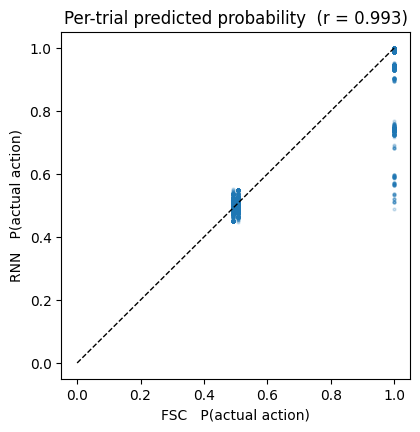

In [194]:
# --- 8 -- Compare the two models fairly: predicted probability, same held-out trials ----
# The OLD comparison plotted two averaged LOSSES computed on different data by different
# equations -- not valid. The fair comparison uses each model's PREDICTED PROBABILITY of the
# action that actually happened, per trial, on the SAME held-out test sessions (both models
# held these out while fitting). From those per-trial probabilities we run two methods:
#   Method 1 -- predictive log-likelihood, paired per trial: which model predicts behavior better.
#   Method 2 -- per-trial probability agreement: do the two models "think" alike, trial by trial.
_use_fsc_path()   # restore FSC modules (Section 3 left tinyRNN on sys.path)

def fsc_per_trial_prob(fsc, session_list):
    """Per-trial P(actual action | history) under the FSC, from its own belief recursion.
    General -- works for any number of actions / memory states."""
    fsc.set_mode("generation")
    T_mat = fsc.get_TMat(); rho = np.asarray(fsc.get_rho()); pol = np.asarray(fsc.get_action_policy())
    out = []
    for s in session_list:
        a, o = s["actions"], s["observations"]
        b = rho.copy(); p = np.zeros(len(a))
        for t in range(len(a)):
            p[t] = (b @ pol)[int(a[t])]                       # P(chosen action | current belief)
            step = T_mat[int(o[t]), :, :, int(a[t])]          # advance the belief with what happened
            bn = b @ step; tot = bn.sum()
            b = bn / tot if tot > 0 else np.ones(fsc.M) / fsc.M
        out.append(p)
    return out

# FSC used here = the sweep model at M* (fit on the FIT set -> holds out test), NOT the all-data
# best_fsc from 2.3. rnn_test_probs came from 3.4 and were also held out from test.
fsc_test_probs = fsc_per_trial_prob(fitted_fscs[M_STAR], test_sessions)

fp = np.concatenate(fsc_test_probs)
rp = np.concatenate([rnn_test_probs[i][:len(fsc_test_probs[i])] for i in range(len(fsc_test_probs))])
fll = np.log(np.clip(fp, 1e-300, 1.0)); rll = np.log(np.clip(rp, 1e-300, 1.0))

print(f"Comparing on {len(test_sessions)} held-out test sessions ({len(fp):,} trials).\n")
print("METHOD 1 -- predictive per-trial log-likelihood (higher = better; nats):")
print(f"   FSC:  mean log-lik = {fll.mean():.5f}   (NLL {-fll.mean():.5f})")
print(f"   RNN:  mean log-lik = {rll.mean():.5f}   (NLL {-rll.mean():.5f})")
print(f"   paired: FSC assigns higher P to the truth on {100*np.mean(fll > rll):.2f}% of trials, "
      f"RNN on {100*np.mean(rll > fll):.2f}%")
# For data generated by an FSC, the FSC is the ground truth -> it should not be beaten. This
# line is a dataset-specific sanity check, not part of the general method.
print(f"   [synthetic-from-FSC sanity check, FSC should be >= RNN]: "
      f"{'PASS' if fll.mean() >= rll.mean() - 1e-9 else 'FAIL -- RNN beats ground truth, investigate'}\n")

print("METHOD 2 -- do the two models assign the same probability per trial?")
r = np.corrcoef(fp, rp)[0, 1]
print(f"   correlation of per-trial P(actual action): r = {r:.4f}")
print(f"   mean |P_FSC - P_RNN| per trial = {np.mean(np.abs(fp - rp)):.5f}")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(fp, rp, s=4, alpha=0.2)
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("FSC   P(actual action)"); plt.ylabel("RNN   P(actual action)")
plt.title(f"Per-trial predicted probability  (r = {r:.3f})")
plt.show()

## 9. Inside the GRU: mechanics with no FSC counterpart

The sections above all had a matched pair, because the question applied to both models. These two
don't — they're about GRU internals the FSC simply has no analogue for. Keeping them here, rather
than forcing a fake symmetry earlier, is deliberate: the FSC has no gates, and no "off-manifold
drift" is possible for a model whose transition is a lookup table.

### 9.1 The update, reset and new gates over time

The GRU builds each new hidden state from three intermediate quantities, all computed
per-unit, per-trial:

| gate | range | what it means |
|---|---|---|
| **update** $z$ | 0–1 | the blend knob: $h' = (1-z)\,n + z\,h$. $z \approx 1$ → **hold** the old state; $z \approx 0$ → **overwrite** it with $n$ |
| **reset** $r$ | 0–1 | how much of the old state is let into the proposal: $n = \tanh(W_{in}x + r \cdot (W_{hn}h + b_{hn}))$. $r \approx 0$ → propose from the **input alone** |
| **new** $n$ | −1–1 | the candidate state being written in |

These never leave `nn.GRU` — they're what the by-hand step in 6.2 exists to expose.

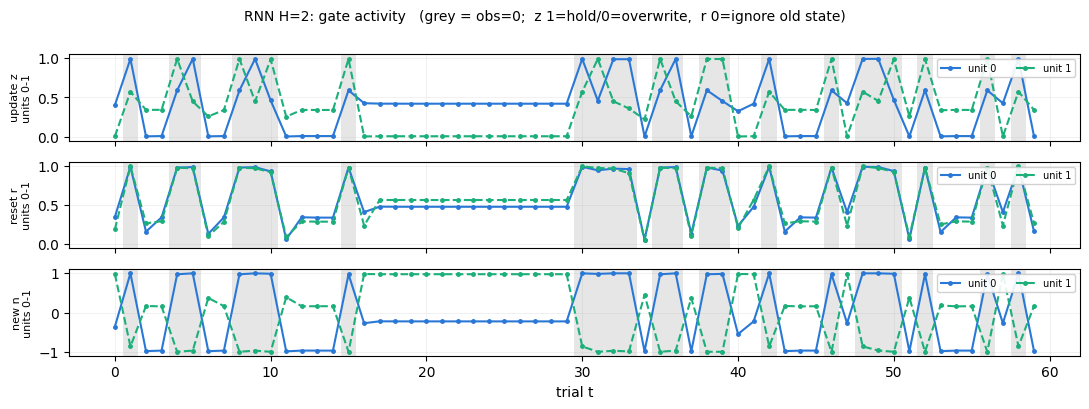

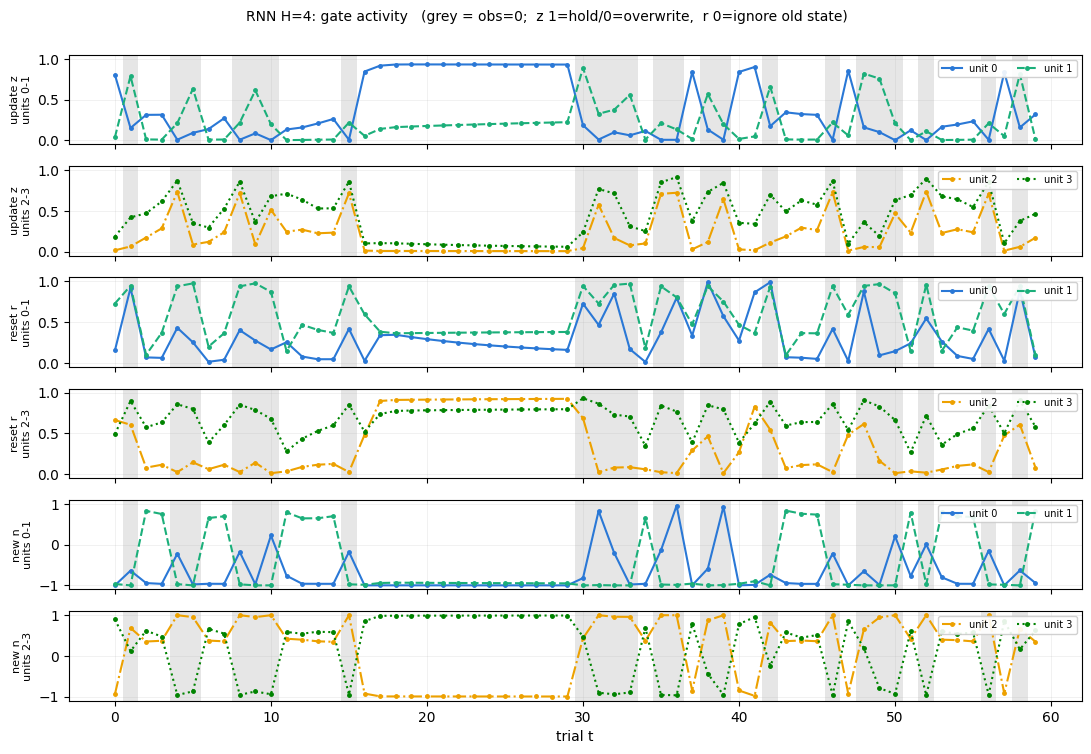

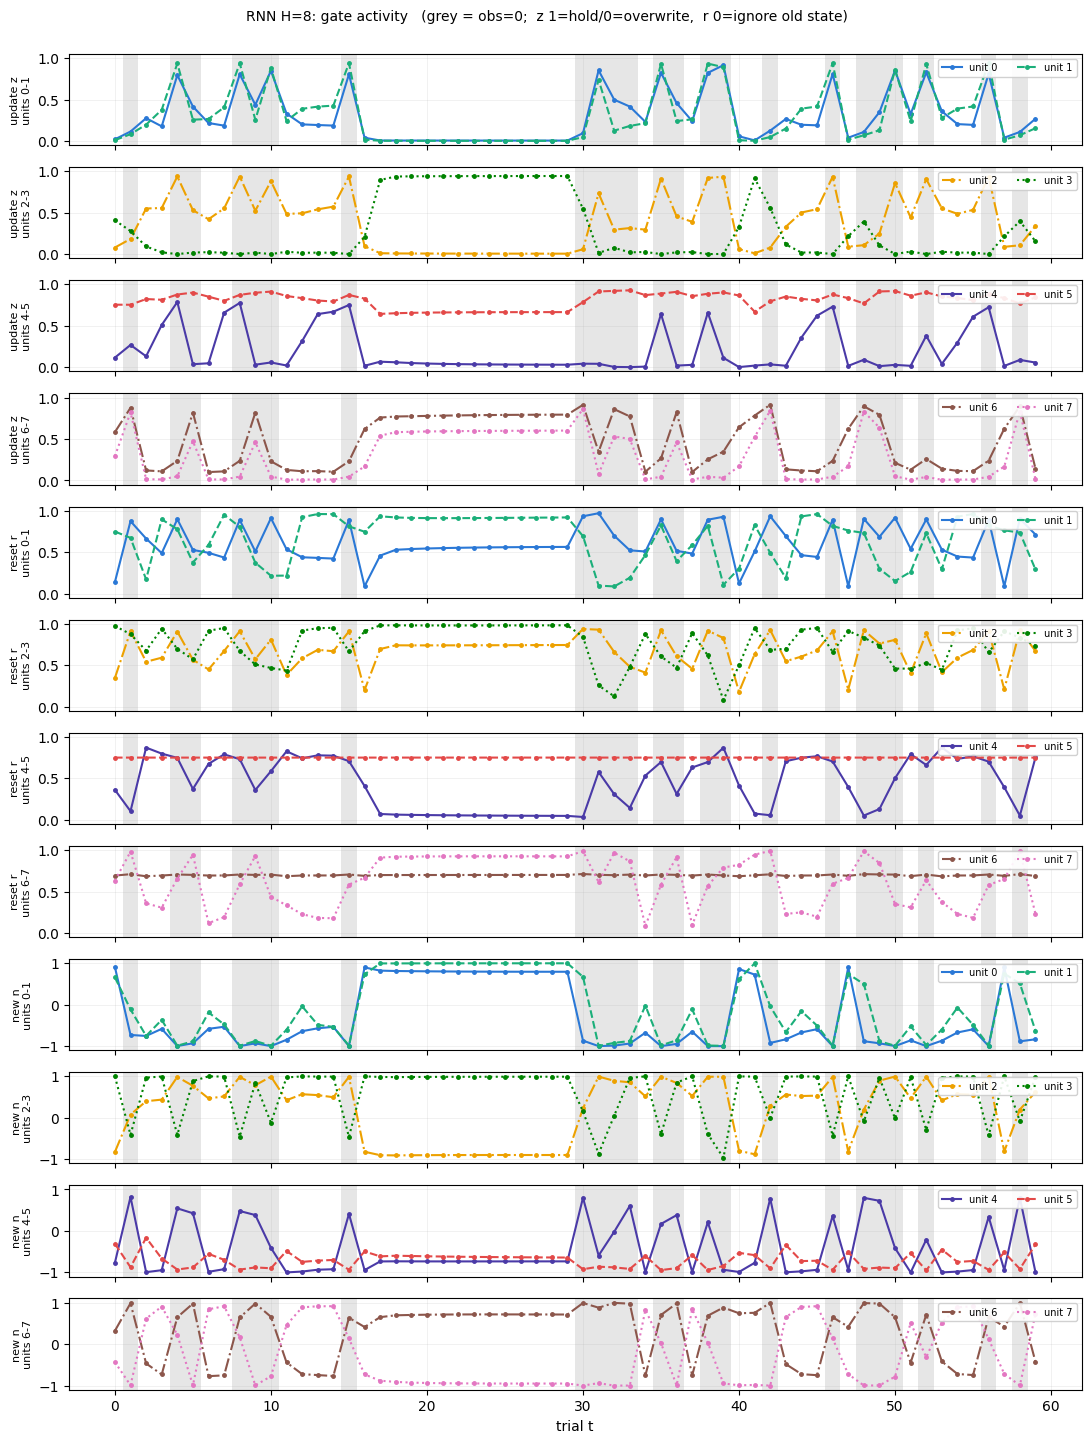

Mean gate value per unit, over the whole example session:

  H=2
     update  [0.455 0.433]
     reset   [0.621 0.614]
     new     [ 0.115 -0.151]
  H=4
     update  [0.309 0.22  0.241 0.475]
     reset   [0.312 0.622 0.271 0.672]
     new     [-0.626 -0.485  0.31   0.047]
  H=8
     update  [0.351 0.356 0.438 0.199 0.213 0.834 0.445 0.247]
     reset   [0.608 0.602 0.662 0.703 0.471 0.751 0.698 0.595]
     new     [-0.482 -0.269  0.362  0.512 -0.402 -0.745  0.316 -0.248]


In [195]:
# --- 9.1 -- What the three gates do, trial by trial ---------------------------------
# Single column, full-width rows so the trial timeline stays readable -- splitting unit-pairs
# across COLUMNS squished the x-axis at H=8. Rows are grouped by gate; <=2 units per panel,
# same convention as §6.3.
GATE_YLABEL = {"update": "update z", "reset": "reset r", "new": "new n"}
for H in H_TO_COMPARE:
    pairs = _unit_pairs(H)                              # defined in §6.3
    rows = [(g, pr) for g in ("update", "reset", "new") for pr in pairs]
    fig, axes = plt.subplots(len(rows), 1, sharex=True, squeeze=False,
                             figsize=(11, 1.15 * len(rows) + 0.6))
    for ax, (g, (u0, u1)) in zip(axes[:, 0], rows):
        shade_losses(ax, example)
        for u in (u0, u1):
            if u >= H:
                continue
            ax.plot(t, gen[H][g][:N_SHOW, u], color=PALETTE[u], ls=LINESTYLES[u],
                    lw=1.5, marker="o", ms=2.5, label=f"unit {u}")
        ax.set_ylim(-1.1, 1.1) if g == "new" else ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
        ax.legend(loc="upper right", ncol=2, fontsize=7, framealpha=0.9)
        lbl = f"units {u0}-{u1}" if u1 < H else f"unit {u0}"
        ax.set_ylabel(f"{GATE_YLABEL[g]}\n{lbl}", fontsize=8)
    axes[-1, 0].set_xlabel("trial t")
    fig.suptitle(f"RNN H={H}: gate activity   (grey = obs=0;  z 1=hold/0=overwrite,  r 0=ignore old state)",
                 y=0.999, fontsize=10)
    plt.tight_layout(); plt.show()

print("Mean gate value per unit, over the whole example session:\n")
for H in H_TO_COMPARE:
    print(f"  H={H}")
    for g in ("update", "reset", "new"):
        print(f"     {g:<7s} {np.round(gen[H][g].mean(axis=0), 3)}")

### 9.2 A caveat: the RNN's rule is only a distribution-bounded approximation

Off-manifold test: feed a constant obs=1 input for `k` steps, well past any streak length that
actually occurs in the real data, and see whether `P(stay)` holds steady or drifts. For WSLS the
target was known in advance (exactly 1 at every `k`); for this dataset we don't yet know what
the "correct" off-manifold behavior even is, so this cell is a pure diagnostic -- read what the
numbers show, rather than checking them against an assumed target.

In [196]:
# --- 9.2 -- Off-manifold probe: P(stay) after k consecutive wins ---------------------
streaks = []
for s in encoded_sessions:
    run = 0
    for v in s["observations"]:
        run = run + 1 if v == 1 else 0
        streaks.append(run)
streaks = np.array(streaks)
print(f"Longest obs=1 streak anywhere in the data: {streaks.max()} trials.  "
      f"Only {100*np.mean(streaks > 20):.3f}% of trials sit beyond streak 20.\n")

KS = [1, 2, 4, 8, 12, 20, 40, 60]
print("P(stay) after k consecutive obs=1 trials, driven from h0 with a constant input")
print("(no target value assumed here -- read the numbers directly)\n")
print("      k =        " + "".join(f"{k:>7d}" for k in KS))
for H in H_TO_COMPARE:
    for a0 in range(A):
        P = rnn_params[H]; row = []
        for k in KS:
            h = np.zeros(P["H"])
            for _ in range(k):
                h, _ = gru_step(h, rnn_encode_input(a0, 1), P)
            row.append(rnn_action_probs(h, P)[a0])
        print(f"   H={H}, stay on {str(ActSpace[a0]):>2}: " + "".join(f"{v:>7.3f}" for v in row))
print("\nWhether P(stay) holds steady or drifts as k grows, and whether that differs by arm or")
print("by size, is worth reading directly above -- no assumption made about the pattern.")

Longest obs=1 streak anywhere in the data: 35 trials.  Only 0.050% of trials sit beyond streak 20.

P(stay) after k consecutive obs=1 trials, driven from h0 with a constant input
(no target value assumed here -- read the numbers directly)

      k =              1      2      4      8     12     20     40     60
   H=2, stay on -1:   0.998  0.998  0.998  0.998  0.998  0.998  0.998  0.998
   H=2, stay on  1:   0.999  0.998  0.998  0.998  0.998  0.998  0.998  0.998
   H=4, stay on -1:   0.999  1.000  1.000  1.000  1.000  1.000  1.000  1.000
   H=4, stay on  1:   1.000  1.000  1.000  1.000  1.000  0.999  0.998  0.998
   H=8, stay on -1:   1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
   H=8, stay on  1:   0.997  1.000  1.000  1.000  1.000  1.000  1.000  1.000

Whether P(stay) holds steady or drifts as k grows, and whether that differs by arm or
by size, is worth reading directly above -- no assumption made about the pattern.


## 10. What is the internal state, given the recent history?

Everything up to §9 either replayed real behavior through the models or generated actions
against the *real* observation sequence. This section closes the loop: both models drive a
**simulated environment**, so every trial they see is one their own choices produced. Then we
ask the whiteboard question,

$$P(m_t \mid a_{t-1}, y_{t-1}), \qquad P(h_t \mid a_{t-1}, y_{t-1})$$

and its 2-back version, and check whether the two answers are the same object in different
coordinates.

**The hypothesis under test.** The FSC is (by construction) a small state machine that could
have generated this data. If the RNN learned the same strategy, then its hidden vector should
be a re-coding of the FSC's memory state: same number of distinguishable configurations,
same conditional occupancy given the same history, and a map between them that works in
**both directions**. If instead the RNN found some other solution, the conditional pictures
will not line up, and no map will exist.

**Why conditioning on history is the right move.** §5.2 and §7 compared the two internal
states unconditionally, and the answer was muddied by the fact that both states are driven by
history in the first place. Conditioning on a fixed recent history (`a`, `y` for the last one
or two trials) removes that shared driver: within one history cell, whatever structure is
left is structure the model added on top of the history, and any correspondence between the
models is a correspondence of *representation*, not of shared input.

### What the environment is
§1 deliberately made no assumption about what this task is. The generation step forces the
issue, because a closed loop needs a rule for what the environment replies. The rule used
here, taken from the whiteboard:

- a hidden state $s \in \{R^{*}, L^{*}\}$ says which side is the better one,
- the agent picks $a_t$, and the environment answers $y_t = \text{win}$ with probability
  `P_WIN` if $a_t = s$, and $1 - $ `P_WIN` otherwise.

Two facts about the real data support this shape and are worth stating, because they were
checked rather than assumed:

1. **$s$ is fixed within a session.** Per-session action bias in the first 100 trials
   correlates 0.94 with the last 100, and the per-arm win rates are stable across
   50-trial blocks. So there are no reversals to model.
2. **The contingency in the data is about 0.70 / 0.29**, not 0.80 / 0.20 (majority-arm win
   rate 0.697, minority 0.290, over all 1000 sessions). We generate at `P_WIN = 0.8` as
   conclusions depend on it (none of the ones below do).

Observation `1` is read as **win** here for the first time in this notebook. That is not a
guess any more: `P(stay | previous obs = 1) = 1.000` in the real data, and obs=1 is the
outcome that occurs ~0.70 of the time on the arm a session sticks with. Both only make sense
if obs=1 is the rewarding outcome.

In [197]:
# --- 10.1 -- The environment, and closed-loop generation from every model --------------
# CLOSED LOOP means: the model picks an action, the environment answers, and THAT answer is
# what the model consumes next. §6.1/§6.2 instead fed both models the real observation
# sequence, which is fine for a policy check but wrong here: we are about to condition on
# (a_{t-1}, y_{t-1}), and in a replay those two are not the pair the model actually produced.
#
# Both models are driven with COMMON RANDOM NUMBERS: the same per-session `better` side and
# the same uniform draws for the environment and for the action sampling. So a difference
# between two models' conditional pictures is a difference between the models, not two
# different draws of the same noise.
_use_fsc_path(); best_fsc.set_mode("generation")

P_WIN       = 0.80          # the whiteboard value. The real data implies ~0.70; set
                            # this to 0.70 and re-run §10 if you want that version.
GEN_SIZES   = [2, 3, 4]     # the RNN sizes this section compares (the user-facing ask)
GEN_N       = 500           # generated sessions per model
GEN_T       = len(test_sessions[0]["actions"])   # trials per session, matching the data
GEN_SEED    = 20

WIN  = int(np.where(ObsSpace == 1)[0][0])        # index of the "win" observation
LOSE = 1 - WIN
ACT_NAME = {i: f"a={ActSpace[i]:+d}" for i in range(A)}
OBS_NAME = {WIN: "win", LOSE: "lose"}

# §4.2 loaded weights only for H_TO_COMPARE (= [2, 4, 8]); H=3 is trained but not loaded yet.
# Same loader as §4.2, run only for the sizes that are missing.
_missing = [H for H in GEN_SIZES if H not in rnn_params]
if _missing:
    _use_tinyrnn_path(); os.chdir("tinyRNN")
    from agents import Agent
    for H in _missing:
        _rows = summary[summary["hidden_dim"] == H].sort_values("trainval_loss")
        _plist = []
        for _, _r in _rows.iterrows():
            _cfg = dict(base_config); _cfg.update({"hidden_dim": H, "seed": 0})
            _ag = Agent("RNN", config=_cfg); _ag.load(str(_r["model_path"]))
            _plist.append(extract_gru_params(_ag))
        rnn_params_folds[H] = _plist        # every run at that size, best loss first
        rnn_params[H] = _plist[0]           # the best one, which is what we generate from
    os.chdir(".."); _use_fsc_path()
    print(f"Loaded weights for the extra size(s) {_missing}; rnn_params now has "
          f"{sorted(rnn_params)}")

def make_env_draws(n_sessions, T, seed):
    """All the randomness a generated block needs, drawn up front so every model reuses it:
    which side is better per session, plus per-trial uniforms for the environment, the action
    choice, and (FSC only) the memory transition."""
    rng = np.random.default_rng(seed)
    better = rng.integers(0, A, size=n_sessions)          # index into ActSpace
    return better, rng.random((n_sessions, T)), rng.random((n_sessions, T)), rng.random((n_sessions, T))

def _cat(p, r):
    """Inverse-CDF sample from a categorical p using ONE pre-drawn uniform r."""
    return int(np.searchsorted(np.cumsum(p), r, side="right"))

def env_obs(a, s, u, p_win):
    """The environment's reply: win with prob p_win on the better side, 1 - p_win otherwise."""
    return WIN if u < (p_win if a == s else 1.0 - p_win) else LOSE

def fsc_generation_arrays(fsc):
    """The three arrays the FSC generates from, plus a check that factorising the library's
    joint transition into (choose action, then move memory) is exact.

    The library samples (a_t, m_{t+1}) JOINTLY from TMat[y_t, m_t] (see
    GenerationDiscreteObs._nb_generate_trajectory). We need the two steps separated, because
    the environment has to see a_t before it can produce y_t. The assert below verifies the
    factorisation the FSC's own parametrisation guarantees:
        T(a, m' | m, y) = pi(a | m) * g(m' | y, a, m)
    so sampling a ~ pi(.|m) and then m' ~ g(.|y, a, m) is the same distribution, not an
    approximation. (pi carries no y dependence in this parametrisation, which is why the
    action can be drawn before the observation exists.)"""
    fsc.set_mode("generation")
    pi  = np.asarray(fsc.get_action_policy())        # (M, A)       pi(a | m)
    g   = np.asarray(fsc.get_memory_transitions())   # (Y, A, M, M) g(m' | y, a, m)
    rho = np.asarray(fsc.get_rho())                  # (M,)
    Tm  = np.asarray(fsc.get_TMat())                 # (Y, M, M, A)
    assert rho.ndim == 1, "obs-dependent rho is not handled here"
    err = np.abs(Tm - pi[None, :, None, :] * np.transpose(g, (0, 2, 3, 1))).max()
    assert err < 1e-9, f"pi * g does not reproduce TMat (max err {err:.2e})"
    return pi, g, rho

def generate_fsc(pi, g, rho, s, u_env, u_act, u_mem, p_win):
    """One closed-loop FSC session. memories[t] is the state the FSC was IN when it chose
    actions[t] -- the same decide-time convention as §5.1 and §8."""
    T = len(u_env)
    acts = np.zeros(T, int); obs = np.zeros(T, int); mem = np.zeros(T, int)
    m = _cat(rho, u_mem[0])
    for t in range(T):
        a = _cat(pi[m], u_act[t])
        y = env_obs(a, s, u_env[t], p_win)
        mem[t], acts[t], obs[t] = m, a, y
        m = _cat(g[y, a, m], u_mem[t])
    return {"actions": acts, "observations": obs, "memories": mem}

def generate_rnn(P, s, u_env, u_act, p_win):
    """One closed-loop RNN session. hidden[t] is the state the readout saw when it chose
    actions[t], so it lines up trial-for-trial with the FSC's memories[t]."""
    T = len(u_env)
    acts = np.zeros(T, int); obs = np.zeros(T, int); hid = np.zeros((T, P["H"]))
    h = np.zeros(P["H"])
    for t in range(T):
        p = rnn_action_probs(h, P)
        a = _cat(p, u_act[t])
        y = env_obs(a, s, u_env[t], p_win)
        hid[t], acts[t], obs[t] = h, a, y
        h, _ = gru_step(h, rnn_encode_input(a, y), P)
    return {"actions": acts, "observations": obs, "hidden": hid}

def generate_all(p_win, seed=GEN_SEED, n=GEN_N, T=GEN_T):
    """{model name -> list of generated sessions}, all models on the same random draws."""
    better, u_env, u_act, u_mem = make_env_draws(n, T, seed)
    pi, g, rho = fsc_generation_arrays(best_fsc)
    out = {f"FSC (M={M_STAR})": [generate_fsc(pi, g, rho, better[i], u_env[i], u_act[i], u_mem[i], p_win)
                                 for i in range(n)]}
    for H in GEN_SIZES:
        out[f"RNN H={H}"] = [generate_rnn(rnn_params[H], better[i], u_env[i], u_act[i], p_win)
                             for i in range(n)]
    return out, better

FSC_NAME = f"FSC (M={M_STAR})"
gen, gen_better = generate_all(P_WIN)

# Sanity gate: if the generated behavior does not look like the data, nothing downstream is
# worth reading. `stay_rates` is §6.1's, reused unchanged.
print(f"Closed loop, P_WIN = {P_WIN}: {GEN_N} sessions x {GEN_T} trials per model\n")
print(f"{'':<16}{'win rate':>10}{'P(stay|win)':>14}{'P(stay|lose)':>14}")
for name, sess in gen.items():
    wr = np.mean([np.mean(s["observations"] == WIN) for s in sess])
    r  = np.array([stay_rates(s["actions"], s["observations"]) for s in sess])
    print(f"{name:<16}{wr:>10.3f}{np.nanmean(r[:, 0]):>14.3f}{np.nanmean(r[:, 1]):>14.3f}")
_r = np.array([stay_rates(s["actions"], s["observations"]) for s in encoded_sessions])
print(f"{'real data':<16}{np.mean([np.mean(s['observations'] == WIN) for s in encoded_sessions]):>10.3f}"
      f"{np.nanmean(_r[:, 0]):>14.3f}{np.nanmean(_r[:, 1]):>14.3f}")
print("\nThe win rate sits above the data's because we generate at P_WIN=0.8 while the data's own\n"
      "contingency is ~0.70. The two STAY rates are the behavioral check that matters here,\n"
      "and every model reproduces them.")

Loaded weights for the extra size(s) [3]; rnn_params now has [2, 3, 4, 8]
Closed loop, P_WIN = 0.8: 500 sessions x 200 trials per model

                  win rate   P(stay|win)  P(stay|lose)
FSC (M=3)            0.711         1.000         0.329
RNN H=2              0.709         0.998         0.335
RNN H=3              0.710         1.000         0.325
RNN H=4              0.710         1.000         0.325
real data            0.598         1.000         0.330

The win rate sits above the data's because we generate at P_WIN=0.8 while the data's own
contingency is ~0.70. The two STAY rates are the behavioral check that matters here,
and every model reproduces them.


### 10.1b A word on what the fitted FSC actually is

Worth reading the three arrays before the plots, because they make the rest predictable.
`pi(a | m)` is deterministic for two of the three states and a coin flip for the third, and
`rho` starts every session in that third state. The memory transitions are deterministic
(every row of `g` is a one-hot), which has one consequence used throughout the section: **the
FSC's belief given a full history is a point mass**, so "the FSC's state" and "the FSC's
belief" are the same object here, and any spread in $P(m_t \mid \text{history})$ comes from
*different deeper histories inside the same history cell*, never from a coin flip inside the
machine.

In [198]:
# --- 10.1b -- Read the machine off its own parameters ---------------------------------
_pi, _g, _rho = fsc_generation_arrays(best_fsc)
print("pi(a | m)   rows = memory state, cols = action")
for m in range(M_STAR):
    print(f"   m={m}: " + "  ".join(f"P({ACT_NAME[a]})={_pi[m, a]:.3f}" for a in range(A)))
print(f"\nrho (start state) = {np.round(_rho, 3)}")
print("\ng(m' | y, a, m)  -- '.' means that (state, action) pair never occurs")
for y in (WIN, LOSE):
    for a in range(A):
        for m in range(M_STAR):
            tgt = "." if _pi[m, a] < 1e-6 else str(int(_g[y, a, m].argmax()))
            print(f"   after {OBS_NAME[y]:<5} on {ACT_NAME[a]:<6} from m={m}: -> m={tgt}")
print("\nEvery reachable row is one-hot, so the memory is a deterministic function of the\n"
      "history -- confirmed numerically below on the generated data.")
_b = np.concatenate([decode_fsc_belief_states(best_fsc, s["actions"], s["observations"])[:-1]
                     for s in gen[FSC_NAME][:100]])
print(f"Fraction of trials whose FSC belief is a point mass (max > 0.99): {(_b.max(1) > 0.99).mean():.4f}")

pi(a | m)   rows = memory state, cols = action
   m=0: P(a=-1)=0.000  P(a=+1)=1.000
   m=1: P(a=-1)=1.000  P(a=+1)=0.000
   m=2: P(a=-1)=0.496  P(a=+1)=0.504

rho (start state) = [0. 0. 1.]

g(m' | y, a, m)  -- '.' means that (state, action) pair never occurs
   after win   on a=-1   from m=0: -> m=.
   after win   on a=-1   from m=1: -> m=1
   after win   on a=-1   from m=2: -> m=1
   after win   on a=+1   from m=0: -> m=0
   after win   on a=+1   from m=1: -> m=.
   after win   on a=+1   from m=2: -> m=0
   after lose  on a=-1   from m=0: -> m=.
   after lose  on a=-1   from m=1: -> m=2
   after lose  on a=-1   from m=2: -> m=0
   after lose  on a=+1   from m=0: -> m=2
   after lose  on a=+1   from m=1: -> m=.
   after lose  on a=+1   from m=2: -> m=1

Every reachable row is one-hot, so the memory is a deterministic function of the
history -- confirmed numerically below on the generated data.
Fraction of trials whose FSC belief is a point mass (max > 0.99): 1.0000


### 10.2 The history cells

A **history cell** is a fixed value of the last $k$ (action, outcome) pairs before the
decision at $t$:

- $k = 1$: $(a_{t-1}, y_{t-1})$, so $A \times Y = 4$ cells.
- $k = 2$: $(a_{t-2}, y_{t-2}, a_{t-1}, y_{t-1})$, so $16$ cells.

The same cell definition is applied to every model's own generated trajectories, which is the
point: a cell is a *description of the recent past*, so it means the same thing no matter who
produced that past. Cells are compared only when every model has at least `MIN_COUNT` trials
in them.

Four of the sixteen 2-back cells are essentially **structurally empty**, not undersampled: a
win is followed by a stay with probability 1 in the real data and in the FSC, so any 2-back
history containing "won, then switched" never occurs for them. The RNNs land a handful of
trials there anyway, because their stay-after-win probability is 0.998 rather than exactly 1
(§10.1's table) -- a few dozen trials out of 100000. Those cells are dropped and reported
rather than compared on counts that thin.

In [199]:
# --- 10.2 -- History cells: coding, labels, and the per-cell tables --------------------
import warnings
from contextlib import contextmanager

@contextmanager
def quiet_blas():
    """NumPy on Apple Silicon (Accelerate BLAS) throws spurious divide-by-zero / overflow
    RuntimeWarnings on matmul for some array shapes even when every value is finite -- the
    same thing §5.2 documents. Suppressed around the fits that trip it, never globally."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        yield

NCOMBO    = A * Y     # (action, outcome) pairs per trial
MIN_COUNT = 50        # a cell is compared across models only if EVERY model has this many trials

def history_codes(actions, observations, k):
    """Integer code for the k-back history preceding each trial; -1 for the first k trials,
    which have no such history. Digit order is oldest-first, so codes sort readably."""
    a = np.asarray(actions); o = np.asarray(observations)
    codes = np.full(len(a), -1, int)
    for t in range(k, len(a)):
        c = 0
        for j in range(k, 0, -1):
            c = c * NCOMBO + a[t - j] * Y + o[t - j]
        codes[t] = c
    return codes

def code_label(c, k, sep=" | "):
    parts = []
    for j in range(k, 0, -1):
        digit = (c // NCOMBO ** (j - 1)) % NCOMBO
        parts.append(f"t-{j}: {ACT_NAME[digit // Y]},{OBS_NAME[digit % Y]}")
    return sep.join(parts)

def code_label_short(c, k):
    """Compact form for axis ticks: '-1L/+1W' means lost on a=-1, then won on a=+1."""
    parts = []
    for j in range(k, 0, -1):
        digit = (c // NCOMBO ** (j - 1)) % NCOMBO
        parts.append(f"{ActSpace[digit // Y]:+d}{'W' if digit % Y == WIN else 'L'}")
    return "/".join(parts)

def fsc_cells(sess_list, k):
    """(history code, FSC memory state, action taken) for every usable trial."""
    codes = np.concatenate([history_codes(s["actions"], s["observations"], k) for s in sess_list])
    mems  = np.concatenate([s["memories"] for s in sess_list])
    acts  = np.concatenate([s["actions"] for s in sess_list])
    keep  = codes >= 0
    return codes[keep], mems[keep], acts[keep]

def rnn_cells(sess_list, k):
    """(history code, hidden vector, action taken) for every usable trial."""
    codes = np.concatenate([history_codes(s["actions"], s["observations"], k) for s in sess_list])
    hid   = np.concatenate([s["hidden"] for s in sess_list], axis=0)
    acts  = np.concatenate([s["actions"] for s in sess_list])
    keep  = codes >= 0
    return codes[keep], hid[keep], acts[keep]

def occupancy_matrix(codes, mems, C, M):
    """P(memory state | history cell), one row per cell, plus the per-cell trial counts."""
    F = np.zeros((C, M)); n = np.zeros(C, int)
    for c in range(C):
        sel = codes == c; n[c] = sel.sum()
        if n[c]:
            F[c] = np.bincount(mems[sel], minlength=M) / n[c]
    return F, n

def hidden_summary(codes, hid, C):
    """Per-cell mean hidden vector, and the 10th/90th percentile per unit."""
    Hd = hid.shape[1]
    mean = np.full((C, Hd), np.nan); lo = np.full((C, Hd), np.nan); hi = np.full((C, Hd), np.nan)
    n = np.zeros(C, int)
    for c in range(C):
        sel = codes == c; n[c] = sel.sum()
        if n[c]:
            mean[c] = hid[sel].mean(axis=0)
            lo[c], hi[c] = np.percentile(hid[sel], [10, 90], axis=0)
    return mean, lo, hi, n

def usable_cells(gen_dict, k):
    """Cells where every model has >= MIN_COUNT trials, plus each model's counts."""
    C = NCOMBO ** k
    counts = {}
    cF, mF, _ = fsc_cells(gen_dict[FSC_NAME], k)
    counts[FSC_NAME] = occupancy_matrix(cF, mF, C, M_STAR)[1]
    for H in GEN_SIZES:
        cR, hR, _ = rnn_cells(gen_dict[f"RNN H={H}"], k)
        counts[f"RNN H={H}"] = hidden_summary(cR, hR, C)[3]
    keep = np.ones(C, bool)
    for n in counts.values():
        keep &= n >= MIN_COUNT
    return keep, counts

# --- The panel drawers §10.3, §10.4 and §10.5 all share --------------------------------
# One panel = one group of trials. Every panel in the section is drawn by one of these, so a
# bar means the same thing everywhere: an FSC panel is a probability over memory states, an
# RNN panel is a mean activation per unit with the 10th-90th percentile band.

def pair_name(d):
    """Name of one (action, outcome) digit of a history code."""
    return f"{ACT_NAME[d // Y]},{OBS_NAME[d % Y]}"

def _panel_count(ax, n):
    """Trial count above the frame (never on top of a bar), flagged when the group is too
    small to compare across models."""
    rare = 0 < n < MIN_COUNT
    ax.text(1.0, 1.015, f"n={n:,}" + ("  (too rare to compare)" if rare else ""),
            transform=ax.transAxes, ha="right", va="bottom", fontsize=6.5,
            color=PALETTE[5] if rare else "0.35")
    return rare

def bar_panel_fsc(ax, dist, n, ghost=None):
    """FSC panel: P(m | this group). `ghost` = the pooled distribution this group was split out
    of, drawn as a dashed outline so what the extra conditioning changed is visible in place
    rather than by flipping between figures."""
    x = np.arange(M_STAR)
    rare = _panel_count(ax, n)
    if ghost is not None:
        ax.bar(x, ghost, color="none", edgecolor="0.45", lw=1.0, ls="--", zorder=3)
    if dist is not None and n > 0:
        ax.bar(x, dist, color=PALETTE[0], edgecolor="k", lw=0.6, zorder=2,
               alpha=0.35 if rare else 1.0)
    else:
        ax.text(0.5, 0.5, "never happens", ha="center", va="center", fontsize=8,
                color="0.45", transform=ax.transAxes)
    ax.set_ylim(0, 1.05); ax.set_xticks(x); ax.set_xticklabels([f"m{j}" for j in x], fontsize=7)
    ax.tick_params(labelsize=7)

def bar_panel_rnn(ax, mean, lo, hi, H, n, ghost=None):
    """RNN panel: mean hidden value per unit, whisker = 10th-90th percentile of that unit over
    the trials in the group. A short whisker means the group pins the unit down; a long one
    means something the group does not specify is still moving it."""
    x = np.arange(H)
    rare = _panel_count(ax, n)
    if ghost is not None:
        ax.bar(x, ghost, color="none", edgecolor="0.45", lw=1.0, ls="--", zorder=3)
    if mean is not None and n > 0 and np.isfinite(mean).all():
        ax.bar(x, mean, color=[PALETTE[u] for u in range(H)], edgecolor="k", lw=0.6, zorder=2,
               alpha=0.35 if rare else 1.0)
        ax.errorbar(x, mean, yerr=[mean - lo, hi - mean], fmt="none", ecolor="0.2",
                    capsize=2.5, lw=1.0, zorder=4, alpha=0.35 if rare else 1.0)
    else:
        ax.text(0.5, 0.5, "never happens", ha="center", va="center", fontsize=8,
                color="0.45", transform=ax.transAxes)
    ax.axhline(0, color="0.4", lw=0.8, zorder=1)
    ax.set_ylim(-1.05, 1.05); ax.set_xticks(x); ax.set_xticklabels([f"u{u}" for u in x], fontsize=7)
    ax.tick_params(labelsize=7)

def cloud_coords(hid):
    """Two dimensions to draw a hidden-state cloud in: the raw units when H=2, otherwise the
    first two PCs of that model's own trials. Fit ONCE per model, so every panel of that model
    shares one projection and those panels are comparable to each other (never across models)."""
    from sklearn.decomposition import PCA
    if hid.shape[1] == 2:
        return hid, ("hidden unit 0", "hidden unit 1")
    with quiet_blas():
        return PCA(n_components=2).fit_transform(hid), ("PC1", "PC2")

def cloud_panel(ax, XY, groups, colors, markers, labels, legend=False):
    """Scatter one cell's trials, split into `groups` (a list of boolean masks). Each group also
    gets its centroid drawn large and outlined, since overlapping points hide where the mass is.
    Groups below MIN_COUNT are faded and get no centroid -- too few trials to average."""
    for i, sel in enumerate(groups):
        n = int(sel.sum())
        if n == 0:
            continue
        rare = n < MIN_COUNT
        ax.scatter(XY[sel, 0], XY[sel, 1], s=9, alpha=0.12 if rare else 0.45, linewidths=0,
                   color=colors[i], marker=markers[i], label=labels[i] if legend else None)
        if not rare:
            ax.scatter(*XY[sel].mean(axis=0), s=90, color=colors[i], marker=markers[i],
                       edgecolor="k", linewidths=1.0, zorder=5)
    ax.tick_params(labelsize=7)

def band_width(lo, hi):
    """Mean 10-90 band width over units: one number for how pinned down the hidden state is."""
    return float(np.mean(hi - lo))

def entropy_bits(v):
    """Uncertainty of a distribution over FSC states, in bits. 0 = one state for certain."""
    v = np.asarray(v, float); v = v[v > 0]
    return abs(float(-(v * np.log2(v)).sum()))    # abs() only to kill -0.0

for k in (1, 2):
    keep, counts = usable_cells(gen, k)
    C = NCOMBO ** k
    print(f"{k}-back: {keep.sum()} of {C} cells usable (every model has >= {MIN_COUNT} trials)")
    for c in range(C):
        tag = "" if keep[c] else "   <- dropped"
        ns = "  ".join(f"{name.split()[-1]}:{counts[name][c]:>6}" for name in counts)
        print(f"   {code_label(c, k):<46} {ns}{tag}")
    print()

1-back: 4 of 4 cells usable (every model has >= 50 trials)
   t-1: a=-1,lose                                 (M=3): 14384  H=2: 14420  H=3: 14397  H=4: 14439
   t-1: a=-1,win                                  (M=3): 36270  H=2: 36166  H=3: 36231  H=4: 36245
   t-1: a=+1,lose                                 (M=3): 14375  H=2: 14491  H=3: 14422  H=4: 14414
   t-1: a=+1,win                                  (M=3): 34471  H=2: 34423  H=3: 34450  H=4: 34402

2-back: 12 of 16 cells usable (every model has >= 50 trials)
   t-2: a=-1,lose | t-1: a=-1,lose                (M=3):  1498  H=2:  1576  H=3:  1492  H=4:  1510
   t-2: a=-1,lose | t-1: a=-1,win                 (M=3):  3197  H=2:  3219  H=3:  3150  H=4:  3167
   t-2: a=-1,lose | t-1: a=+1,lose                (M=3):  4886  H=2:  4873  H=3:  4941  H=4:  4930
   t-2: a=-1,lose | t-1: a=+1,win                 (M=3):  4736  H=2:  4684  H=3:  4748  H=4:  4766
   t-2: a=-1,win | t-1: a=-1,lose                 (M=3):  8117  H=2:  8097  H=3:  8114 

### 10.3 One trial back

The first picture. Per history cell:

- **FSC**: the bar chart from the whiteboard box, $P(m_t \mid a_{t-1}, y_{t-1})$.
- **RNN**: what the hidden vector does in that same cell, per unit (mean, with the 10th to
  90th percentile band), and then the whole cloud in two dimensions.

Read the two together. The FSC's answer is a distribution over three labelled states; the
RNN's is a cloud in $\mathbb{R}^H$. The question §10.6 makes precise is whether the cloud has
exactly as many resolvable pieces as the FSC has states, sitting in the same proportions.

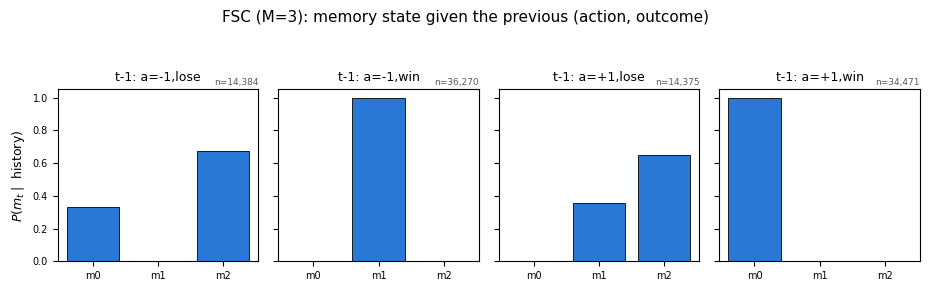

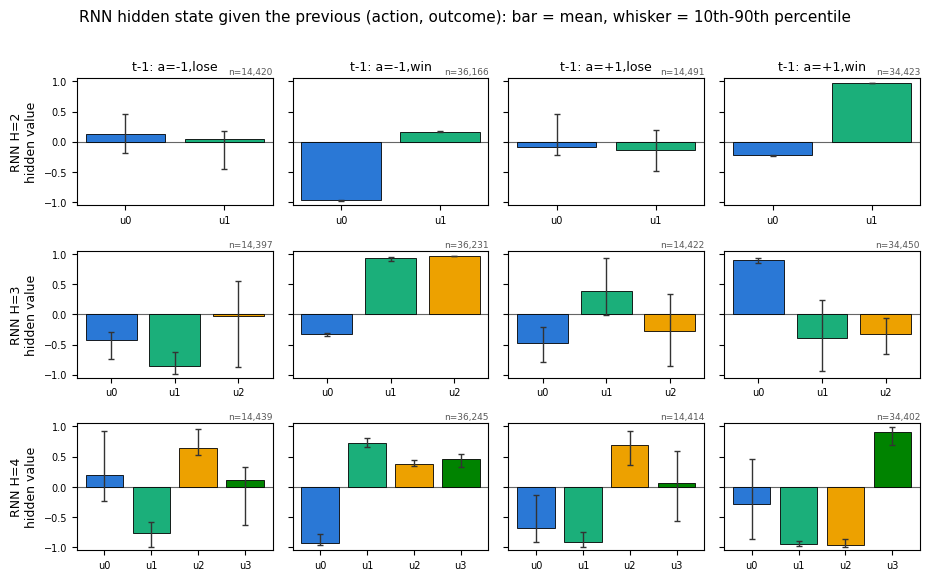

In [200]:
# --- 10.3 -- 1-back history: FSC state occupancy, and the RNN hidden state -------------
# LAYOUT, used again by §10.4 and §10.5: one column per history cell, one panel per group of
# trials. Here there is a single row, because the last trial is the only thing conditioned on.
K1 = 1
keep1, counts1 = usable_cells(gen, K1)
cells1 = np.where(keep1)[0]

cF1, mF1, aF1 = fsc_cells(gen[FSC_NAME], K1)
F1, nF1 = occupancy_matrix(cF1, mF1, NCOMBO ** K1, M_STAR)

# (a) The whiteboard bar chart: one panel per history cell, one bar per FSC memory state.
fig, axes = plt.subplots(1, NCOMBO, figsize=(2.35 * NCOMBO, 2.7), sharey=True)
for col in range(NCOMBO):
    bar_panel_fsc(axes[col], F1[col] if nF1[col] else None, nF1[col])
    axes[col].set_title(f"t-1: {pair_name(col)}", fontsize=9)
axes[0].set_ylabel("$P(m_t \\mid$ history$)$", fontsize=9)
fig.suptitle(f"{FSC_NAME}: memory state given the previous (action, outcome)", y=1.06, fontsize=11)
plt.tight_layout(); plt.show()

# (b) The RNN's answer to the same question, one row per size. Colors are the reference palette
#     in fixed slot order, one slot per unit, so a unit keeps its color across every panel and
#     every size in the section.
rnn_1back = {}
fig, axes = plt.subplots(len(GEN_SIZES), NCOMBO,
                         figsize=(2.35 * NCOMBO, 1.9 * len(GEN_SIZES)), sharey=True)
axes = np.atleast_2d(axes)
for row, H in enumerate(GEN_SIZES):
    cR, hR, aR = rnn_cells(gen[f"RNN H={H}"], K1)
    mean, lo, hi, n = hidden_summary(cR, hR, NCOMBO ** K1)
    rnn_1back[H] = (mean, lo, hi, n)
    for col in range(NCOMBO):
        bar_panel_rnn(axes[row, col], mean[col] if n[col] else None, lo[col], hi[col], H, n[col])
        if row == 0:
            axes[row, col].set_title(f"t-1: {pair_name(col)}", fontsize=9)
    axes[row, 0].set_ylabel(f"RNN H={H}\nhidden value", fontsize=9)
fig.suptitle("RNN hidden state given the previous (action, outcome): "
             "bar = mean, whisker = 10th-90th percentile", y=1.01, fontsize=11)
plt.tight_layout(); plt.show()

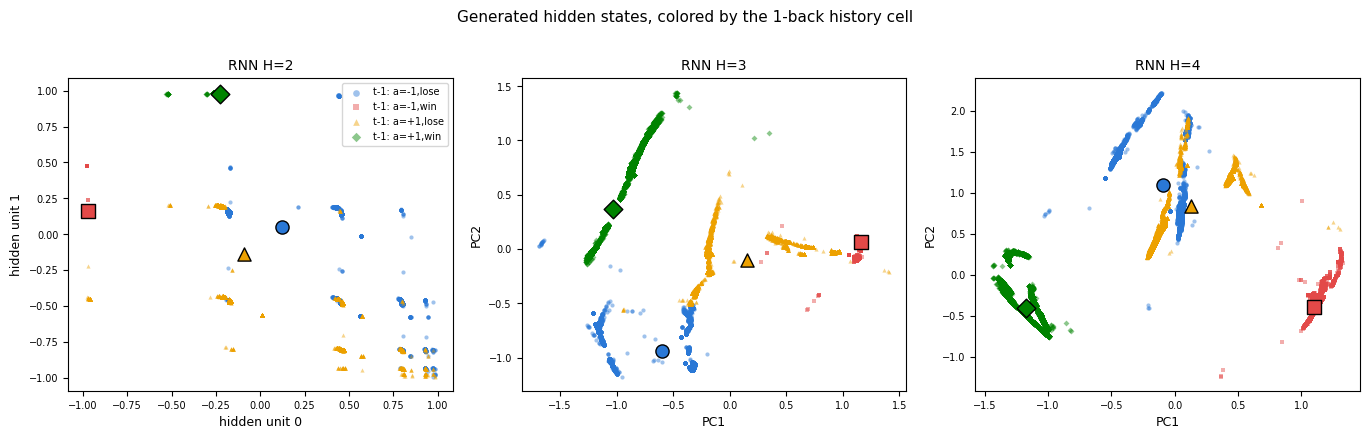

What to look for: how many separated blobs each panel has. The FSC answers this same
question with 3 states, and the two 'lose' cells above are the ones where its answer is
split rather than a single state -- so a matching RNN should show those cells sitting
apart from the two 'win' cells, in a place the deeper history decides.


In [201]:
# --- 10.3b -- The same hidden states as a cloud, colored by history cell ---------------
# Why a second picture: the bars above summarise each unit one at a time, and a mean hides
# shape. If a cell's trials are really two groups sitting at -0.9 and +0.9, the bar reads 0.0,
# a value the unit is never at. The cloud shows the groups; the bar cannot.
#
# Two dimensions per model: the raw units when H=2, the first two PCs otherwise (see
# `cloud_coords`). Each panel is in its OWN model's coordinates, so compare structure across
# panels (how many blobs, which colors sit together), never positions.
#
# Color means HISTORY CELL here, not unit (10.3 used the palette slots for units). Different
# slots are used on purpose, and the marker shape varies too, so nothing rests on hue alone.
CELL_COLORS  = [PALETTE[0], PALETTE[5], PALETTE[2], PALETTE[3]]
CELL_MARKERS = ["o", "s", "^", "D"]
CELL_LABELS  = [f"t-1: {pair_name(c)}" for c in range(NCOMBO)]

fig, axes = plt.subplots(1, len(GEN_SIZES), figsize=(4.6 * len(GEN_SIZES), 4.3))
for ax, H in zip(np.atleast_1d(axes), GEN_SIZES):
    cR, hR, aR = rnn_cells(gen[f"RNN H={H}"], K1)
    XY, (xl, yl) = cloud_coords(hR)
    cloud_panel(ax, XY, [cR == c for c in range(NCOMBO)], CELL_COLORS, CELL_MARKERS,
                CELL_LABELS, legend=True)
    ax.set_title(f"RNN H={H}", fontsize=10)
    ax.set_xlabel(xl, fontsize=9); ax.set_ylabel(yl, fontsize=9)
axes[0].legend(fontsize=7, markerscale=1.6, loc="best")
fig.suptitle("Generated hidden states, colored by the 1-back history cell", y=1.01, fontsize=11)
plt.tight_layout(); plt.show()

print("What to look for: how many separated blobs each panel has. The FSC answers this same\n"
      "question with 3 states, and the two 'lose' cells above are the ones where its answer is\n"
      "split rather than a single state -- so a matching RNN should show those cells sitting\n"
      "apart from the two 'win' cells, in a place the deeper history decides.")

### 10.4 Two trials back

Same panels as §10.3, with one row added per possible second-to-last trial. Columns are still
the four 1-back cells, and the top row is still §10.3's answer, repeated in every panel below
it as the dashed outline so each panel carries its own before/after.

**Reading down a column is the point.** It asks what changes once you also know the trial before
the last one. "Resolving" means the spread inside a cell shrinks: the FSC's occupancy bar stops
being split across two states, and the RNN's whiskers get shorter. Where that happens, the model
was never uncertain. The 1-back cell was pooling histories it treats differently, and naming the
earlier trial pulls them apart.

That is exactly what §10.1b implies for the FSC: its transitions are deterministic, so a split
bar can only ever be pooling. The open question is whether the RNN's clouds split in the same
cells and the same way, which is what would make the two models comparable rather than merely
similar.

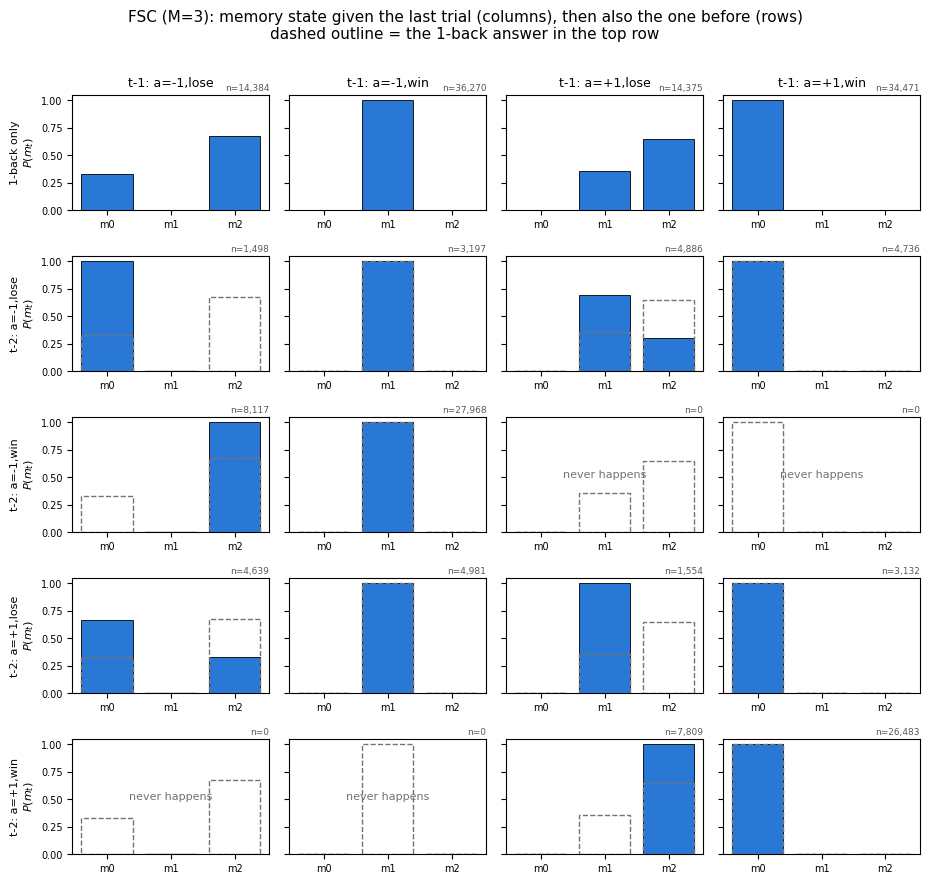

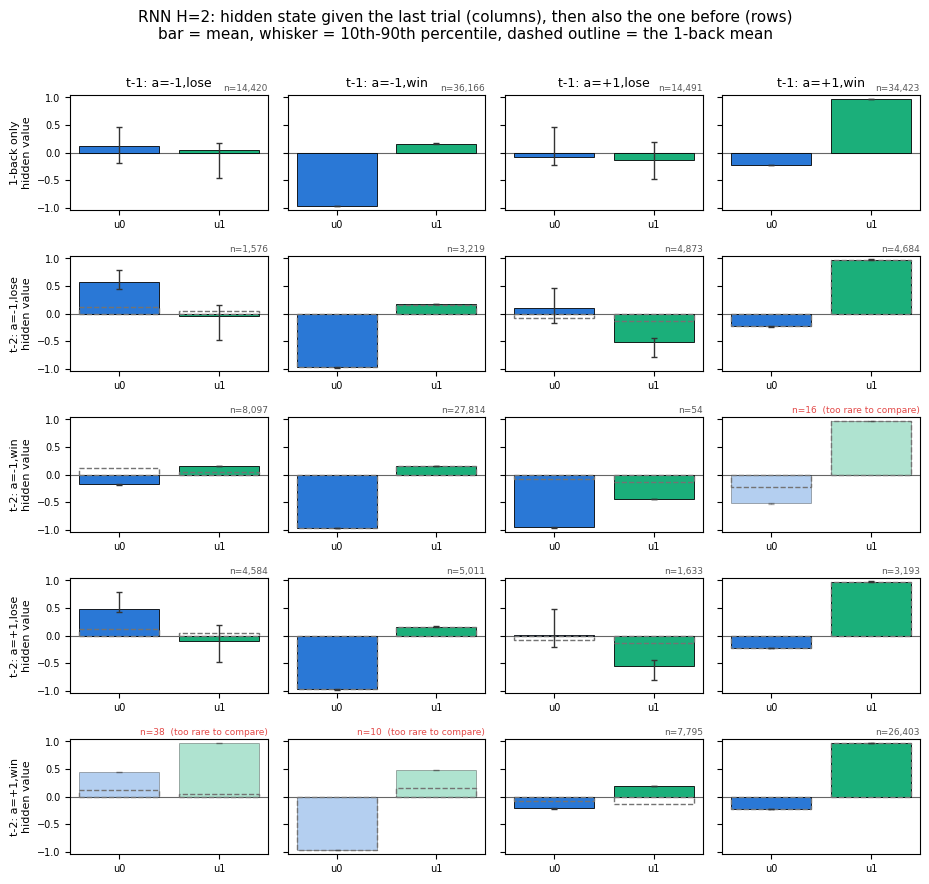

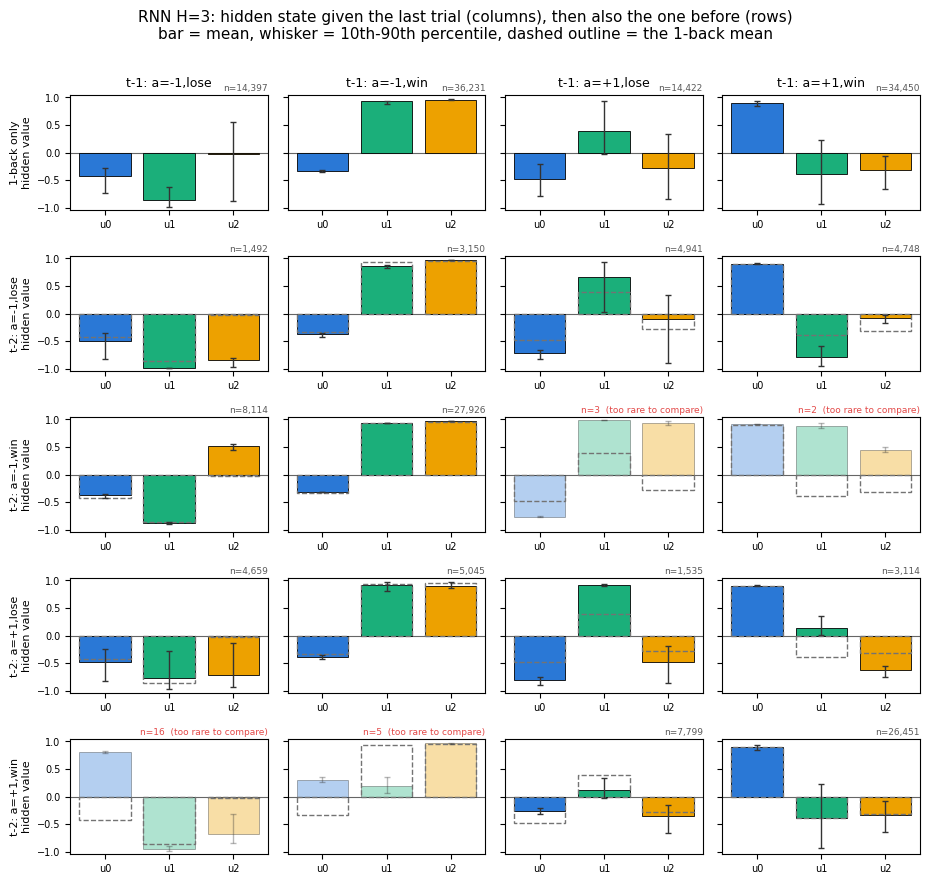

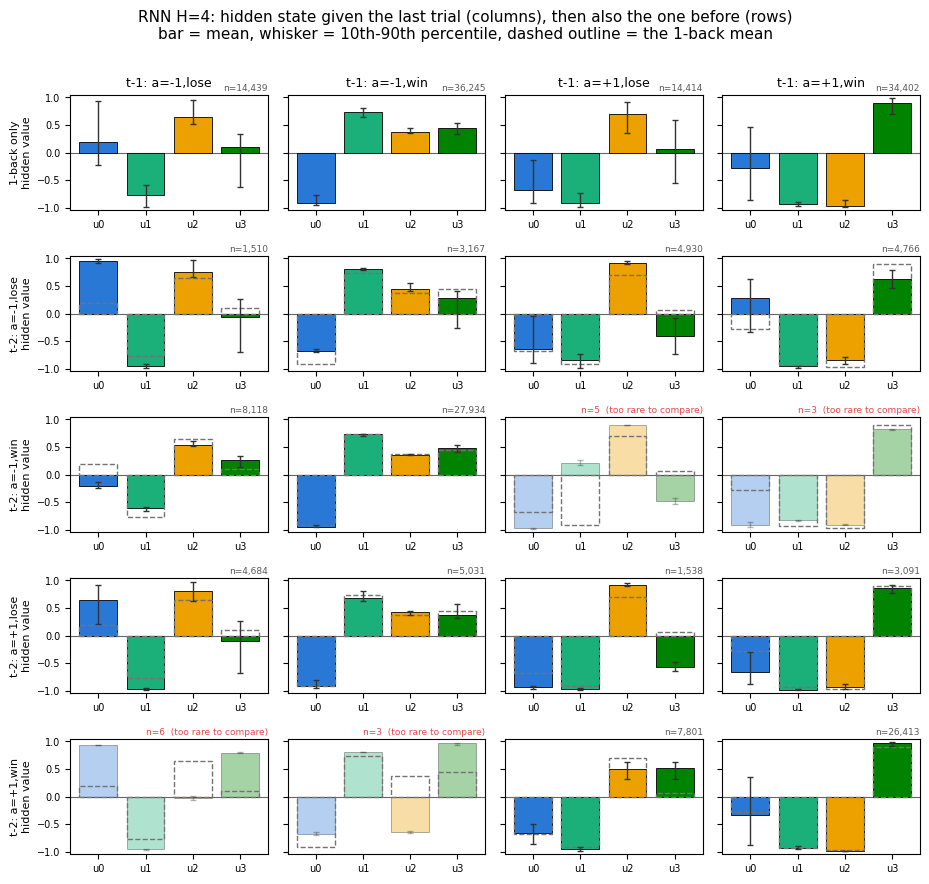

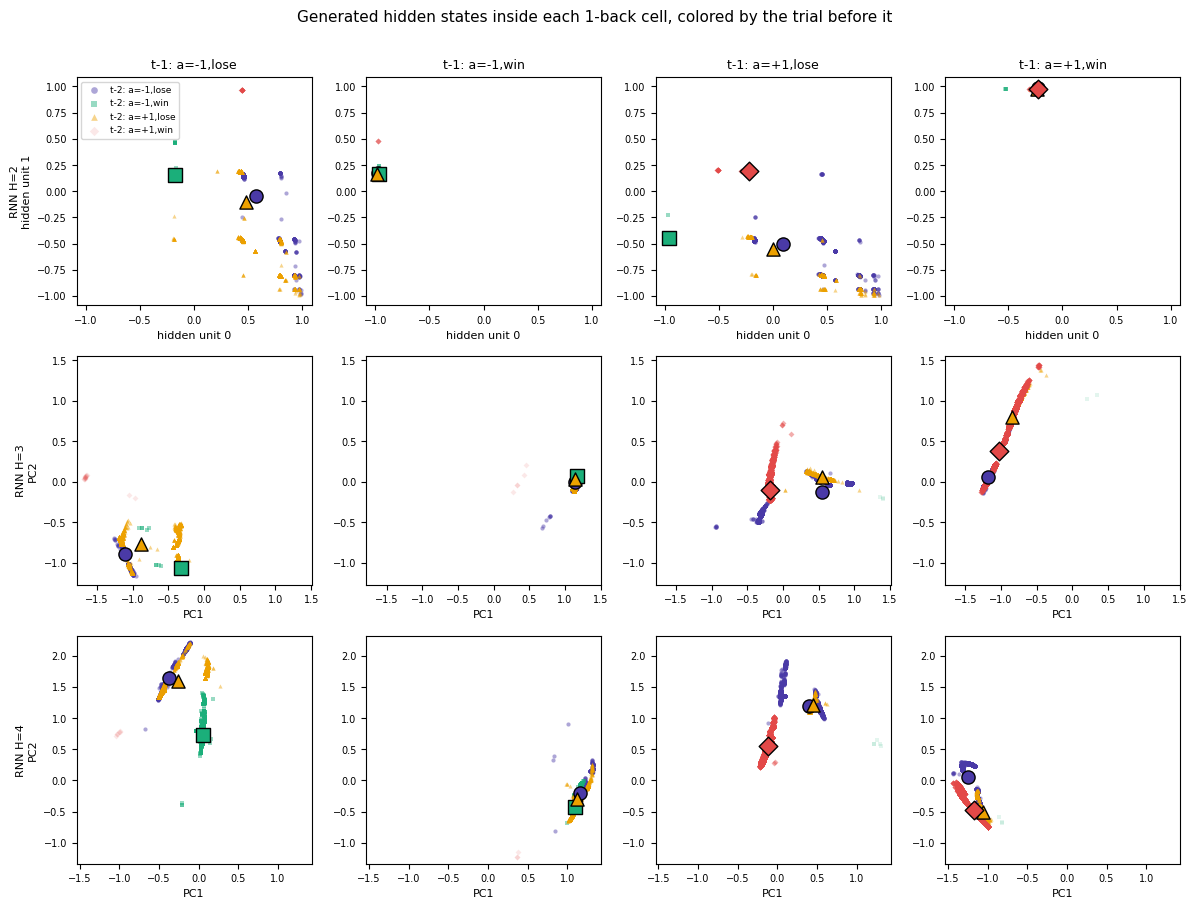

How much of the 1-back spread does the second trial back remove?

last trial (t-1)        FSC entropy (bits)        H=2 band width        H=3 band width        H=4 band width
a=-1,lose                   0.914 -> 0.298        0.641 -> 0.225        0.746 -> 0.289        0.741 -> 0.270
a=-1,win                    0.000 -> 0.000        0.011 -> 0.003        0.041 -> 0.025        0.161 -> 0.090
a=+1,lose                   0.937 -> 0.304        0.676 -> 0.230        0.913 -> 0.475        0.690 -> 0.307
a=+1,win                    0.000 -> 0.000        0.006 -> 0.003        0.615 -> 0.512        0.462 -> 0.336

A large drop means the second trial was carrying the missing information: the model was
never uncertain, the 1-back cell was just pooling histories it treats differently. A cell
that starts near 0 and stays there is one the last trial already decided on its own.
What matters for the comparison is not the numbers themselves but WHICH cells drop --
the FSC and every RNN size should resol

In [202]:
# --- 10.4 -- 2-back history: the same panels as §10.3, one row per second-to-last trial ---
# LAYOUT (all three figures below share it, and §10.5 reuses it):
#   columns  = the LAST trial (t-1), the same four cells §10.3 already showed
#   top row  = §10.3's answer again, pooled over everything before t-1
#   rows 2-5 = that column split by the SECOND-TO-LAST trial (t-2)
# Reading DOWN a column is the point: it asks what changes once the trial before the last one
# is also fixed. The top row is repeated in every panel below as the dashed outline, so each
# panel carries its own before/after rather than needing two figures side by side.
K2 = 2
keep2, counts2 = usable_cells(gen, K2)

cF2, mF2, aF2 = fsc_cells(gen[FSC_NAME], K2)
F2, nF2 = occupancy_matrix(cF2, mF2, NCOMBO ** K2, M_STAR)

code2 = lambda older, recent: older * NCOMBO + recent      # digit order is oldest-first

# §10.6 walks the usable cells as a flat list, ordered by the FSC state that dominates each one
# (so cells the FSC calls the same thing sit together). Built here, used there.
cells2 = np.where(keep2)[0]
cells2 = cells2[np.lexsort((-F2[cells2].max(axis=1), F2[cells2].argmax(axis=1)))]

# (a) FSC ------------------------------------------------------------------------------
fig, axes = plt.subplots(1 + NCOMBO, NCOMBO, figsize=(2.35 * NCOMBO, 1.75 * (1 + NCOMBO)),
                         sharey=True)
for col in range(NCOMBO):
    bar_panel_fsc(axes[0, col], F1[col] if nF1[col] else None, nF1[col])
    axes[0, col].set_title(f"t-1: {pair_name(col)}", fontsize=9)
    for row in range(NCOMBO):
        c = code2(row, col)
        bar_panel_fsc(axes[1 + row, col], F2[c] if nF2[c] else None, nF2[c], ghost=F1[col])
axes[0, 0].set_ylabel("1-back only\n$P(m_t)$", fontsize=8)
for row in range(NCOMBO):
    axes[1 + row, 0].set_ylabel(f"t-2: {pair_name(row)}\n$P(m_t)$", fontsize=8)
fig.suptitle(f"{FSC_NAME}: memory state given the last trial (columns), then also the one before "
             f"(rows)\ndashed outline = the 1-back answer in the top row", y=1.005, fontsize=11)
plt.tight_layout(); plt.show()

# (b) RNN, one figure per size ---------------------------------------------------------
rnn_2back = {}
for H in GEN_SIZES:
    m1, l1, h1, n1 = rnn_1back[H]                       # computed in §10.3
    cR, hR, aR = rnn_cells(gen[f"RNN H={H}"], K2)
    m2, l2, h2, n2 = hidden_summary(cR, hR, NCOMBO ** K2)
    rnn_2back[H] = (m2, l2, h2, n2)

    fig, axes = plt.subplots(1 + NCOMBO, NCOMBO, figsize=(2.35 * NCOMBO, 1.75 * (1 + NCOMBO)),
                             sharey=True)
    for col in range(NCOMBO):
        bar_panel_rnn(axes[0, col], m1[col] if n1[col] else None, l1[col], h1[col], H, n1[col])
        axes[0, col].set_title(f"t-1: {pair_name(col)}", fontsize=9)
        for row in range(NCOMBO):
            c = code2(row, col)
            bar_panel_rnn(axes[1 + row, col], m2[c] if n2[c] else None, l2[c], h2[c], H, n2[c],
                          ghost=m1[col])
    axes[0, 0].set_ylabel("1-back only\nhidden value", fontsize=8)
    for row in range(NCOMBO):
        axes[1 + row, 0].set_ylabel(f"t-2: {pair_name(row)}\nhidden value", fontsize=8)
    fig.suptitle(f"RNN H={H}: hidden state given the last trial (columns), then also the one "
                 f"before (rows)\nbar = mean, whisker = 10th-90th percentile, dashed outline = "
                 f"the 1-back mean", y=1.005, fontsize=11)
    plt.tight_layout(); plt.show()

# (c) The clouds, split the same way ----------------------------------------------------
# §10.3b again, except each 1-back cell is now colored by WHICH t-2 trial preceded it. If the
# extra trial is what the RNN is holding, the colors inside a panel sit apart.
# NOTE the color key changed again: here a color is a t-2 (action, outcome) pair. The big
# outlined markers are group centroids, easier to read than the overlapping points.
OLDER_COLORS  = [PALETTE[4], PALETTE[1], PALETTE[2], PALETTE[5]]
OLDER_MARKERS = ["o", "s", "^", "D"]
OLDER_LABELS  = [f"t-2: {pair_name(i)}" for i in range(NCOMBO)]

fig, axes = plt.subplots(len(GEN_SIZES), NCOMBO, figsize=(3.0 * NCOMBO, 3.0 * len(GEN_SIZES)))
axes = np.atleast_2d(axes)
for row, H in enumerate(GEN_SIZES):
    cR, hR, aR = rnn_cells(gen[f"RNN H={H}"], K2)
    XY, (xl, yl) = cloud_coords(hR)
    for col in range(NCOMBO):
        ax = axes[row, col]
        cloud_panel(ax, XY, [cR == code2(i, col) for i in range(NCOMBO)],
                    OLDER_COLORS, OLDER_MARKERS, OLDER_LABELS, legend=(row == 0 and col == 0))
        ax.set_xlim(XY[:, 0].min() - 0.1, XY[:, 0].max() + 0.1)
        ax.set_ylim(XY[:, 1].min() - 0.1, XY[:, 1].max() + 0.1)
        if row == 0:
            ax.set_title(f"t-1: {pair_name(col)}", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"RNN H={H}\n{yl}", fontsize=8)
        ax.set_xlabel(xl, fontsize=8)
axes[0, 0].legend(fontsize=6.5, markerscale=1.6, loc="best")
fig.suptitle("Generated hidden states inside each 1-back cell, colored by the trial before it",
             y=1.005, fontsize=11)
plt.tight_layout(); plt.show()

# --- What the second trial resolves, as numbers ---------------------------------------
# Left of each arrow: how spread out the internal state is when only the last trial is known.
# Right: the same spread after t-2 is also fixed, averaged over the four t-2 groups and
# weighted by how often each occurs. The drop IS the resolution.
#   FSC: entropy of P(m | cell), in bits. 0 = one state for certain, 1 = a coin flip between two.
#   RNN: mean 10-90 band width over units, in hidden-value units. 0 = the same vector every time.
print("How much of the 1-back spread does the second trial back remove?\n")
print(f"{'last trial (t-1)':<20}{'FSC entropy (bits)':>22}" +
      "".join(f"{'H=' + str(H) + ' band width':>22}" for H in GEN_SIZES))
for col in range(NCOMBO):
    subs = np.array([code2(r, col) for r in range(NCOMBO)])
    w = np.array([nF2[c] for c in subs], float)
    e1 = entropy_bits(F1[col])
    e2 = float(np.average([entropy_bits(F2[c]) for c in subs], weights=w)) if w.sum() else np.nan
    row = f"{pair_name(col):<20}" + f"{f'{e1:.3f} -> {e2:.3f}':>22}"
    for H in GEN_SIZES:
        m2, l2, h2, n2 = rnn_2back[H]
        _, l1, h1, _ = rnn_1back[H]
        b1 = band_width(l1[col], h1[col])
        wr = np.array([n2[c] for c in subs], float); ok = wr > 0
        b2 = float(np.average([band_width(l2[c], h2[c]) for c in subs[ok]], weights=wr[ok]))
        row += f"{f'{b1:.3f} -> {b2:.3f}':>22}"
    print(row)
print("\nA large drop means the second trial was carrying the missing information: the model was\n"
      "never uncertain, the 1-back cell was just pooling histories it treats differently. A cell\n"
      "that starts near 0 and stays there is one the last trial already decided on its own.\n"
      "What matters for the comparison is not the numbers themselves but WHICH cells drop --\n"
      "the FSC and every RNN size should resolve in the same places if they encode the same thing.")

### 10.5 Splitting each cell by the action that was taken

Same layout once more, with the rows now being the choice the model made at $t$ rather than the
trial before $t$. Inside one history cell the models still make a choice, and $P(a_t)$ is not 0
or 1 in the cells that matter.

Reading down a column asks whether the internal state is what decided that choice. If it is, the
two lower panels sit in different places and the pooled answer (the dashed outline) sits between
them. If the state is the same either way, the choice was made downstream of it, by the sampling
at the readout. The FSC gives a concrete reason to expect the second answer in part: its state
$m_2$ has $\pi(a \mid m_2) = 0.5$, so wherever the FSC sits in $m_2$ the choice is a coin flip
that the state does not settle.

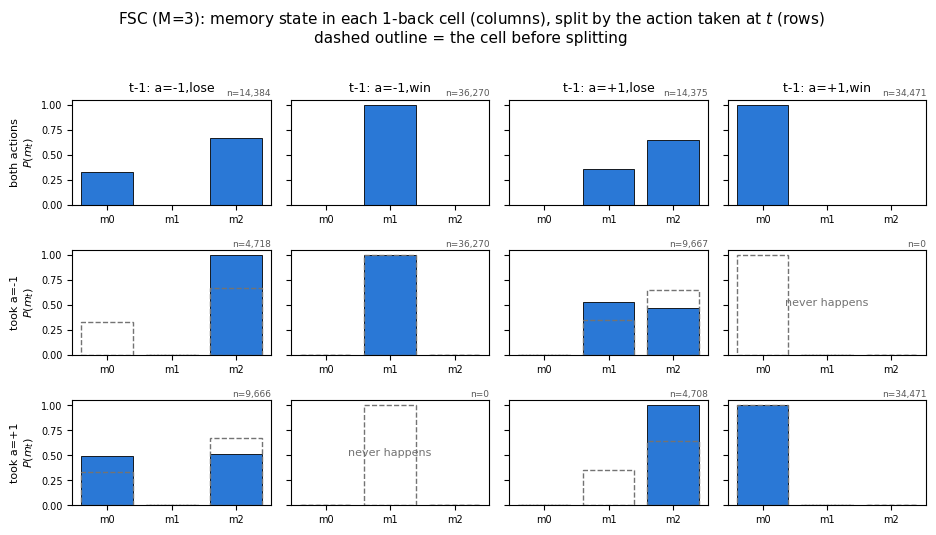

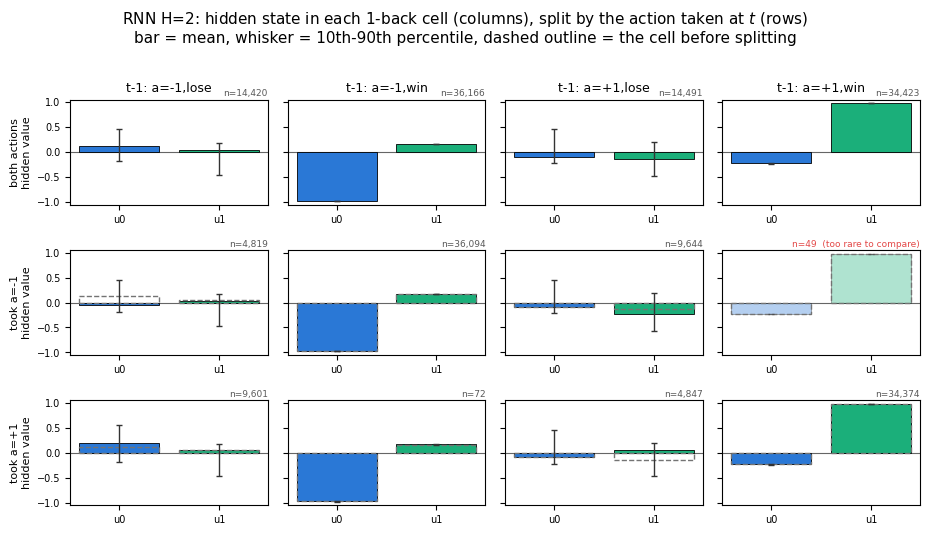

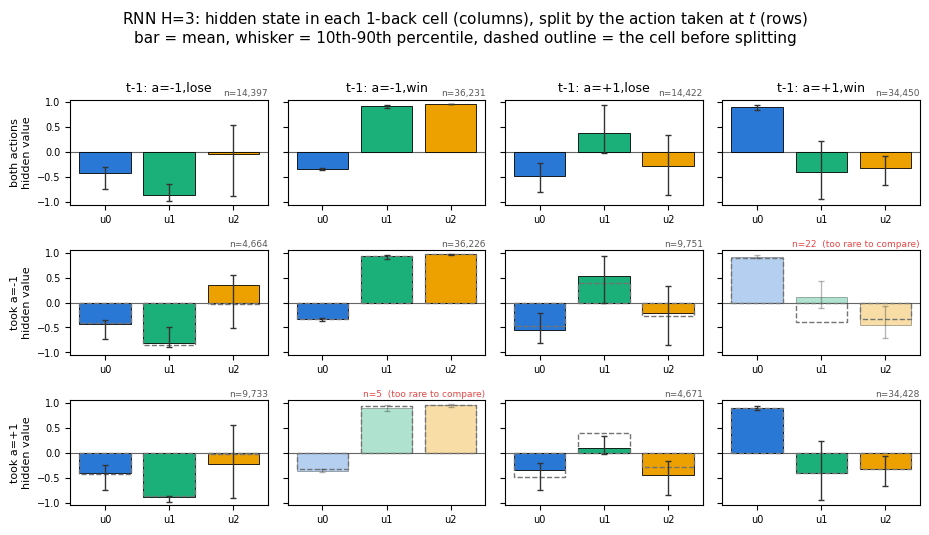

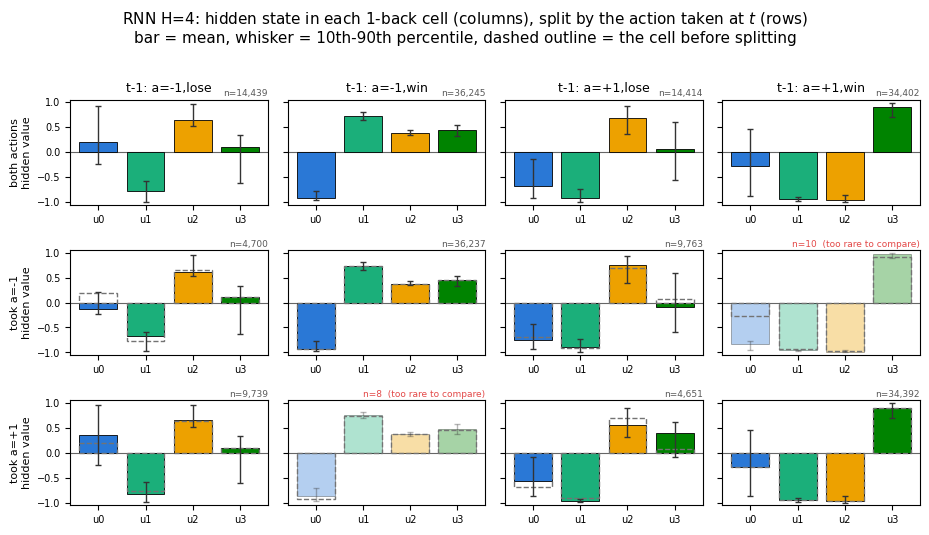

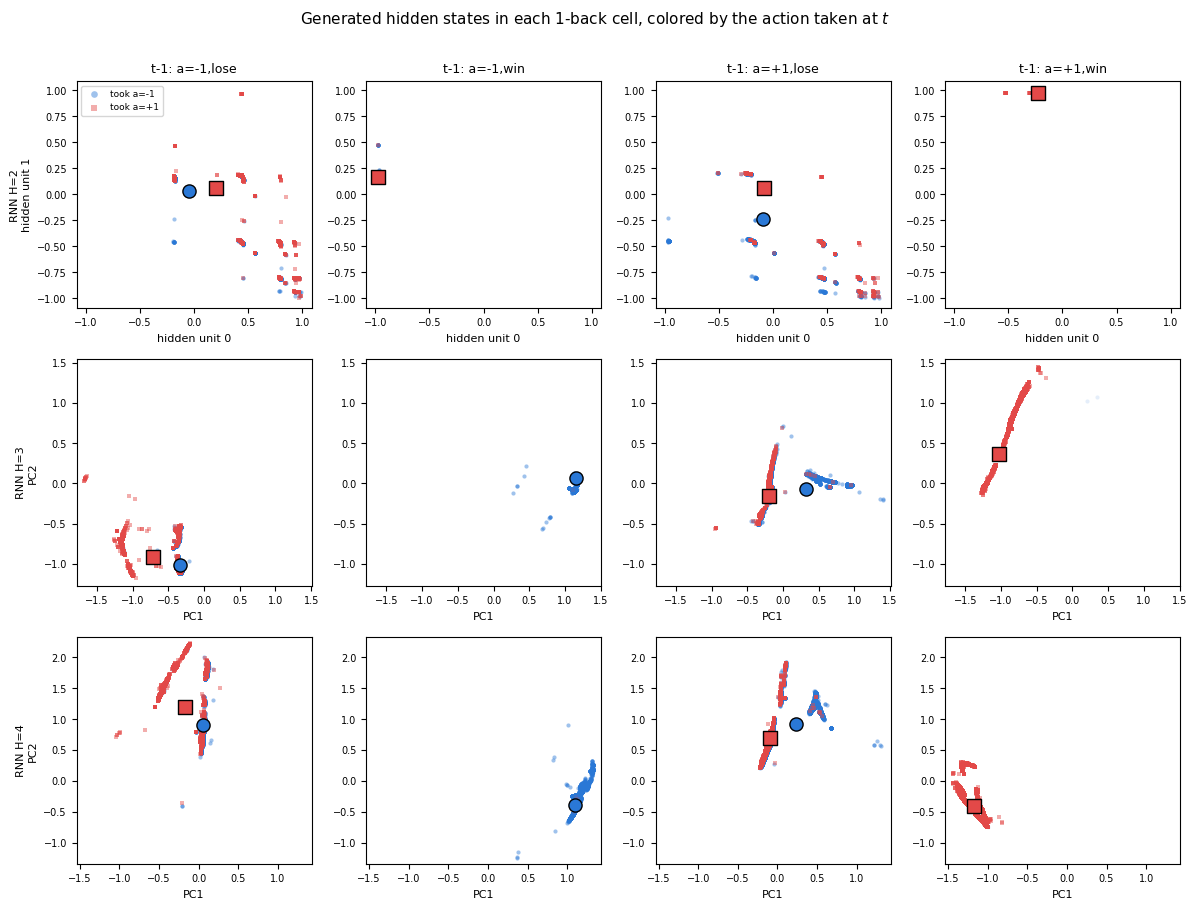

Per 1-back cell: what the model chose, and how far the two choices sit apart internally

last trial (t-1)        P(a=-1), P(a=+1)   FSC TV gap     H=2 gap/spread     H=3 gap/spread     H=4 gap/spread
a=-1,lose                0.328,    0.672        0.489     0.252 /  0.662     0.570 /  0.652     0.514 /  0.653
a=-1,win                 1.000,    0.000          n/a     0.005 /  0.011                n/a                n/a
a=+1,lose                0.672,    0.328        0.525     0.295 /  0.694     0.537 /  0.725     0.549 /  0.574
a=+1,win                 0.000,    1.000          n/a                n/a                n/a                n/a

'n/a' = one of the two actions essentially never happens in that cell, so there is no
split to make. That is the win cells: P(stay | win) = 1, the choice is forced, and the
state has nothing left to decide. The loss cells are where the choice is live.

Read the gap against the spread. A gap much LARGER than the spread means the state
decides the choice.

In [203]:
# --- 10.5 -- 1-back history x the action actually taken -------------------------------
# Same layout as §10.4, with the rows now being the choice the model made at t rather than the
# trial before t:
#   columns = the 1-back cell, top row = §10.3's answer pooled over both actions
#   rows below = that same cell split by the action taken at t
# Reading down a column asks whether the internal state is what decided the choice. If it is,
# the two lower panels differ and the dashed outline (the pooled cell) sits between them.

def group_masks(codes, acts, c):
    """The trials of cell `c`, split by the action taken at t."""
    return [(codes == c) & (acts == a) for a in range(A)]

# (a) FSC ------------------------------------------------------------------------------
fsc_by_act = {}      # (cell, action) -> (P(m | .), n)
for c in range(NCOMBO ** K1):
    for a, sel in enumerate(group_masks(cF1, aF1, c)):
        n = int(sel.sum())
        fsc_by_act[(c, a)] = (np.bincount(mF1[sel], minlength=M_STAR) / n if n else None, n)

fig, axes = plt.subplots(1 + A, NCOMBO, figsize=(2.35 * NCOMBO, 1.75 * (1 + A)), sharey=True)
for col in range(NCOMBO):
    bar_panel_fsc(axes[0, col], F1[col] if nF1[col] else None, nF1[col])
    axes[0, col].set_title(f"t-1: {pair_name(col)}", fontsize=9)
    for a in range(A):
        dist, n = fsc_by_act[(col, a)]
        bar_panel_fsc(axes[1 + a, col], dist, n, ghost=F1[col])
axes[0, 0].set_ylabel("both actions\n$P(m_t)$", fontsize=8)
for a in range(A):
    axes[1 + a, 0].set_ylabel(f"took {ACT_NAME[a]}\n$P(m_t)$", fontsize=8)
fig.suptitle(f"{FSC_NAME}: memory state in each 1-back cell (columns), split by the action taken "
             f"at $t$ (rows)\ndashed outline = the cell before splitting", y=1.01, fontsize=11)
plt.tight_layout(); plt.show()

# (b) RNN, one figure per size ---------------------------------------------------------
rnn_by_act = {}      # H -> {(cell, action): (mean, lo, hi, n)}
for H in GEN_SIZES:
    m1, l1, h1, n1 = rnn_1back[H]                       # computed in §10.3
    cR, hR, aR = rnn_cells(gen[f"RNN H={H}"], K1)
    tab = {}
    for c in range(NCOMBO ** K1):
        for a, sel in enumerate(group_masks(cR, aR, c)):
            n = int(sel.sum())
            if n:
                lo, hi = np.percentile(hR[sel], [10, 90], axis=0)
                tab[(c, a)] = (hR[sel].mean(axis=0), lo, hi, n)
            else:
                tab[(c, a)] = (None, None, None, 0)
    rnn_by_act[H] = tab

    fig, axes = plt.subplots(1 + A, NCOMBO, figsize=(2.35 * NCOMBO, 1.75 * (1 + A)), sharey=True)
    for col in range(NCOMBO):
        bar_panel_rnn(axes[0, col], m1[col] if n1[col] else None, l1[col], h1[col], H, n1[col])
        axes[0, col].set_title(f"t-1: {pair_name(col)}", fontsize=9)
        for a in range(A):
            mean, lo, hi, n = tab[(col, a)]
            bar_panel_rnn(axes[1 + a, col], mean, lo, hi, H, n, ghost=m1[col])
    axes[0, 0].set_ylabel("both actions\nhidden value", fontsize=8)
    for a in range(A):
        axes[1 + a, 0].set_ylabel(f"took {ACT_NAME[a]}\nhidden value", fontsize=8)
    fig.suptitle(f"RNN H={H}: hidden state in each 1-back cell (columns), split by the action "
                 f"taken at $t$ (rows)\nbar = mean, whisker = 10th-90th percentile, dashed "
                 f"outline = the cell before splitting", y=1.01, fontsize=11)
    plt.tight_layout(); plt.show()

# (c) The clouds, colored by the action taken -------------------------------------------
# The cleanest version of the question: inside one history cell, does the hidden state sit in
# two different places depending on what the model then did? Color = the action at t.
ACT_COLORS  = [PALETTE[0], PALETTE[5]]
ACT_MARKERS = ["o", "s"]
ACT_LABELS  = [f"took {ACT_NAME[a]}" for a in range(A)]

fig, axes = plt.subplots(len(GEN_SIZES), NCOMBO, figsize=(3.0 * NCOMBO, 3.0 * len(GEN_SIZES)))
axes = np.atleast_2d(axes)
for row, H in enumerate(GEN_SIZES):
    cR, hR, aR = rnn_cells(gen[f"RNN H={H}"], K1)
    XY, (xl, yl) = cloud_coords(hR)
    for col in range(NCOMBO):
        ax = axes[row, col]
        cloud_panel(ax, XY, group_masks(cR, aR, col), ACT_COLORS, ACT_MARKERS, ACT_LABELS,
                    legend=(row == 0 and col == 0))
        ax.set_xlim(XY[:, 0].min() - 0.1, XY[:, 0].max() + 0.1)
        ax.set_ylim(XY[:, 1].min() - 0.1, XY[:, 1].max() + 0.1)
        if row == 0:
            ax.set_title(f"t-1: {pair_name(col)}", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"RNN H={H}\n{yl}", fontsize=8)
        ax.set_xlabel(xl, fontsize=8)
axes[0, 0].legend(fontsize=6.5, markerscale=1.6, loc="best")
fig.suptitle("Generated hidden states in each 1-back cell, colored by the action taken at $t$",
             y=1.005, fontsize=11)
plt.tight_layout(); plt.show()

# --- How far apart the two halves sit --------------------------------------------------
# FSC gap = total-variation distance between the two memory distributions (0 = identical,
# 1 = they never share a state). RNN gap = distance between the two mean hidden vectors,
# printed next to the typical within-group spread so it reads as wide or narrow rather than
# as a bare number.
print("Per 1-back cell: what the model chose, and how far the two choices sit apart internally\n")
print(f"{'last trial (t-1)':<20}{'P(a=-1), P(a=+1)':>20}{'FSC TV gap':>13}" +
      "".join(f"{'H=' + str(H) + ' gap/spread':>19}" for H in GEN_SIZES))
for c in cells1:
    ns = [fsc_by_act[(c, a)][1] for a in range(A)]
    p = np.array(ns, float) / max(sum(ns), 1)
    both = all(n >= MIN_COUNT for n in ns)
    gap = (f"{np.abs(fsc_by_act[(c, 0)][0] - fsc_by_act[(c, 1)][0]).sum() / 2:>13.3f}"
           if both else f"{'n/a':>13}")
    row = f"{pair_name(c):<20}{p[0]:>10.3f},{p[1]:>9.3f}{gap}"
    for H in GEN_SIZES:
        tab = rnn_by_act[H]
        if all(tab[(c, a)][3] >= MIN_COUNT for a in range(A)):
            d = float(np.linalg.norm(tab[(c, 0)][0] - tab[(c, 1)][0]))
            spread = np.mean([band_width(tab[(c, a)][1], tab[(c, a)][2]) for a in range(A)])
            row += f"{d:>10.3f} /{spread:>7.3f}"
        else:
            row += f"{'n/a':>19}"
    print(row)
print("\n'n/a' = one of the two actions essentially never happens in that cell, so there is no\n"
      "split to make. That is the win cells: P(stay | win) = 1, the choice is forced, and the\n"
      "state has nothing left to decide. The loss cells are where the choice is live.\n"
      "\nRead the gap against the spread. A gap much LARGER than the spread means the state\n"
      "decides the choice. A gap SMALLER than the spread means it does not, and the choice was\n"
      "made downstream by the sampling at the readout. Expect the second answer here in part:\n"
      f"the FSC's m2 has pi(a | m2) = 0.5 (see §10.1b), so wherever the FSC sits in m2 the state\n"
      "is genuinely indifferent, and a matching RNN has to be indifferent in the same cells.")

### 10.6 The converter

The object this whole section was building toward: **a map that takes an RNN's hidden vector
and returns the FSC memory state it corresponds to**, and the same map run backwards. If that
map exists and works, the RNN is the FSC written in different coordinates. If it doesn't, the
two models found different strategies.

Two cells. **10.6a** asks the coarse version with no labels at all: cluster the hidden states
into $M^*$ groups and see whether those groups line up with the FSC's states cell by cell.
**10.6b** is the map itself.

**Why it is fit inside one history cell, never pooled.** Over all trials at once the job is
trivial and proves nothing: win trials and lose trials sit far apart in hidden space, and the
FSC is in different states there too, so any rule scores about 0.99 by detecting "did it just
win". That is a fact about the last trial, which §10.3 already showed by eye. Holding the
recent history fixed removes it. Inside one cell every trial shares the same recent past, so
anything the map still recovers has to come from further back, which is exactly the memory
§10.4 showed the FSC carries and the 1-back picture cannot see.

Only cells where the FSC uses more than one state can be tested. In the others there is a
single right answer and nothing to convert, which is itself the §10.4 result restated.


1-back cells -- FSC state vs matched RNN cluster (weighted mean TV distance)
   H=2: clusters [np.int64(0), np.int64(2), np.int64(1)] -> states [0, 1, 2]   mean TV = 0.0975   worst cell TV = 0.3488 (t-1: a=+1,lose)
   H=3: clusters [np.int64(0), np.int64(1), np.int64(2)] -> states [0, 1, 2]   mean TV = 0.0563   worst cell TV = 0.3277 (t-1: a=-1,lose)
   H=4: clusters [np.int64(0), np.int64(1), np.int64(2)] -> states [0, 1, 2]   mean TV = 0.0985   worst cell TV = 0.3529 (t-1: a=+1,lose)

2-back cells -- FSC state vs matched RNN cluster (weighted mean TV distance)
   H=2: clusters [np.int64(0), np.int64(2), np.int64(1)] -> states [0, 1, 2]   mean TV = 0.0967   worst cell TV = 1.0000 (t-2: a=-1,lose | t-1: a=-1,lose)
   H=3: clusters [np.int64(0), np.int64(1), np.int64(2)] -> states [0, 1, 2]   mean TV = 0.0558   worst cell TV = 1.0000 (t-2: a=-1,lose | t-1: a=-1,lose)
   H=4: clusters [np.int64(0), np.int64(1), np.int64(2)] -> states [0, 1, 2]   mean TV = 0.0965   worst cell TV = 1.0000

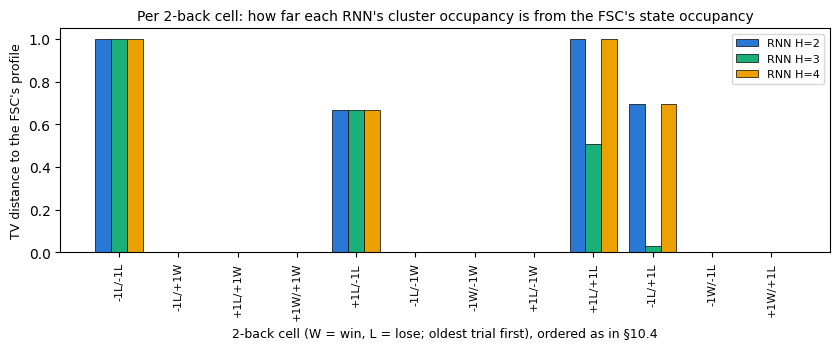

A cell at 0 means the RNN's clusters and the FSC's states pick out the same trials there.
Cells near 1 are cells where the unsupervised split disagrees outright -- read them
against §10.6b, which asks the same question with the labels supplied.


In [204]:
# --- 10.6a -- Discrete: k-means clusters in hidden space, matched to FSC states --------
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

def cluster_profiles(sess_list, k, K, seed=0):
    """k-means the generated hidden states into K groups, then P(cluster | history cell).
    K = M* here: we are asking whether the hidden space splits the way the FSC's state set
    does, so the number of groups is the FSC's, not one chosen to fit the RNN."""
    hid   = np.concatenate([s["hidden"] for s in sess_list], axis=0)
    codes = np.concatenate([history_codes(s["actions"], s["observations"], k) for s in sess_list])
    with quiet_blas():
        km = KMeans(n_clusters=K, n_init=10, random_state=seed).fit(hid)
    lab = km.labels_[codes >= 0]; codes = codes[codes >= 0]
    C = NCOMBO ** k
    D = np.zeros((C, K)); n = np.zeros(C, int)
    for c in range(C):
        sel = codes == c; n[c] = sel.sum()
        if n[c]:
            D[c] = np.bincount(lab[sel], minlength=K) / n[c]
    return D, n, km

def match_to_fsc(F, D, cells, weights):
    """Permutation of clusters onto FSC states minimising the weighted L1 profile mismatch."""
    K = D.shape[1]
    cost = np.zeros((F.shape[1], K))
    for i in range(F.shape[1]):
        for j in range(K):
            cost[i, j] = (weights * np.abs(F[cells][:, i] - D[cells][:, j])).sum()
    ri, ci = linear_sum_assignment(cost)
    perm = np.zeros(F.shape[1], int); perm[ri] = ci
    return perm

match = {}
for k, F, cells, nF in ((K1, F1, cells1, nF1), (K2, F2, cells2, nF2)):
    w = nF[cells] / nF[cells].sum()
    print(f"\n{k}-back cells -- FSC state vs matched RNN cluster (weighted mean TV distance)")
    for H in GEN_SIZES:
        D, nR, km = cluster_profiles(gen[f"RNN H={H}"], k, M_STAR)
        perm = match_to_fsc(F, D, cells, w)
        Dm = D[:, perm]
        tv = 0.5 * np.abs(F[cells] - Dm[cells]).sum(axis=1)
        match[(k, H)] = (Dm, perm, tv, cells)
        print(f"   H={H}: clusters {list(perm)} -> states {list(range(M_STAR))}   "
              f"mean TV = {(w * tv).sum():.4f}   worst cell TV = {tv.max():.4f} "
              f"({code_label(cells[tv.argmax()], k)})")

# Cell-by-cell, 1-back: the two profiles side by side.
print("\n1-back, cell by cell:")
for i, c in enumerate(cells1):
    line = f"   {code_label(c, K1):<26} FSC {np.round(F1[c], 3)}"
    for H in GEN_SIZES:
        line += f"   H={H} {np.round(match[(K1, H)][0][c], 3)}"
    print(line)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
x = np.arange(len(cells2)); width = 0.8 / len(GEN_SIZES)
tv_by_cell = {H: dict(zip(match[(K2, H)][3], match[(K2, H)][2])) for H in GEN_SIZES}
for i, H in enumerate(GEN_SIZES):
    ax.bar(x + i * width - 0.4 + width / 2, [tv_by_cell[H][c] for c in cells2], width,
           color=PALETTE[i], edgecolor="k", linewidth=0.5, label=f"RNN H={H}")
ax.set_xticks(x)
ax.set_xticklabels([code_label_short(c, K2) for c in cells2], fontsize=8, rotation=90)
ax.set_xlabel("2-back cell (W = win, L = lose; oldest trial first), ordered as in §10.4", fontsize=9)
ax.set_ylabel("TV distance to the FSC's profile", fontsize=9)
ax.set_title("Per 2-back cell: how far each RNN's cluster occupancy is from the FSC's state occupancy",
             fontsize=10)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("A cell at 0 means the RNN's clusters and the FSC's states pick out the same trials there.\n"
      "Cells near 1 are cells where the unsupervised split disagrees outright -- read them\n"
      "against §10.6b, which asks the same question with the labels supplied.")

The converter, written out. score = w . h + b, and the sign of the score is the answer.

  t-1: a=-1,lose
     H=2: score = -14.06*h0 + -10.36*h1 +4.31      score<0 -> m0,  score>0 -> m2
     H=3: score = -4.25*h0 + +7.48*h1 + +7.92*h2 +7.83      score<0 -> m0,  score>0 -> m2
     H=4: score = -10.38*h0 + +2.17*h1 + +1.39*h2 + -2.72*h3 +5.77      score<0 -> m0,  score>0 -> m2
  t-1: a=+1,lose
     H=2: score = +10.50*h0 + +14.79*h1 +4.79      score<0 -> m1,  score>0 -> m2
     H=3: score = +7.09*h0 + -8.75*h1 + -2.98*h2 +7.91      score<0 -> m1,  score>0 -> m2
     H=4: score = +7.90*h0 + -3.15*h1 + -3.56*h2 + +7.14*h3 +6.53      score<0 -> m1,  score>0 -> m2

  t-2: a=-1,lose | t-1: a=+1,lose
     H=2: score = +10.38*h0 + +11.78*h1 +3.03      score<0 -> m1,  score>0 -> m2
     H=3: score = +0.78*h0 + -7.07*h1 + -3.55*h2 +1.67      score<0 -> m1,  score>0 -> m2
     H=4: score = +8.45*h0 + -2.22*h1 + -0.15*h2 + +3.88*h3 +2.88      score<0 -> m1,  score>0 -> m2
  t-2: a=+1,lose | t-1: a

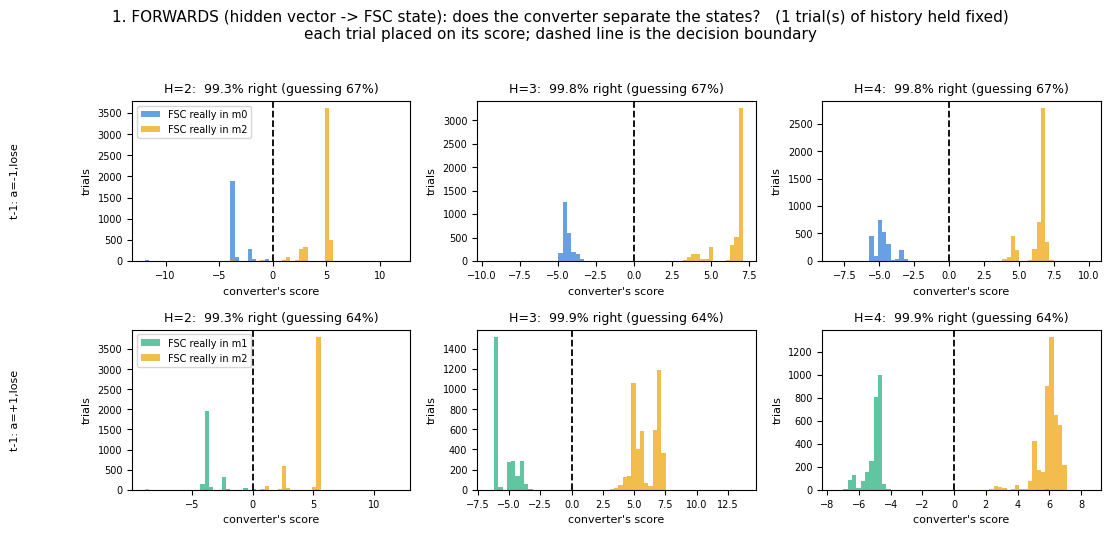

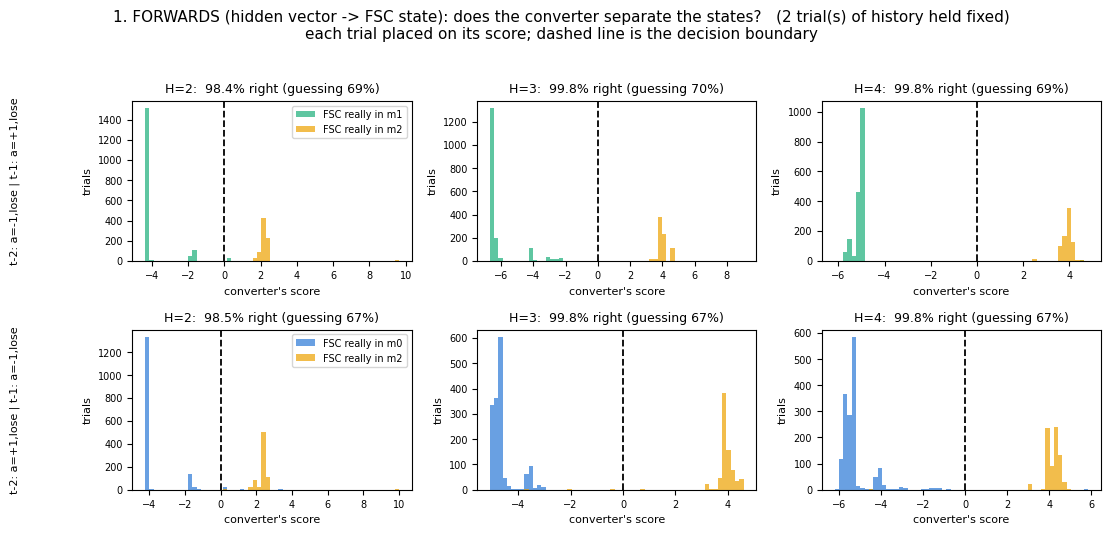

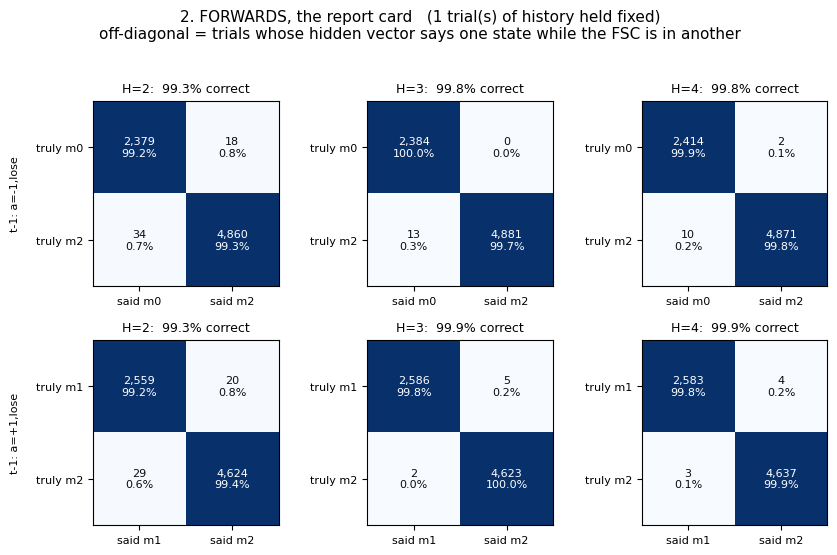

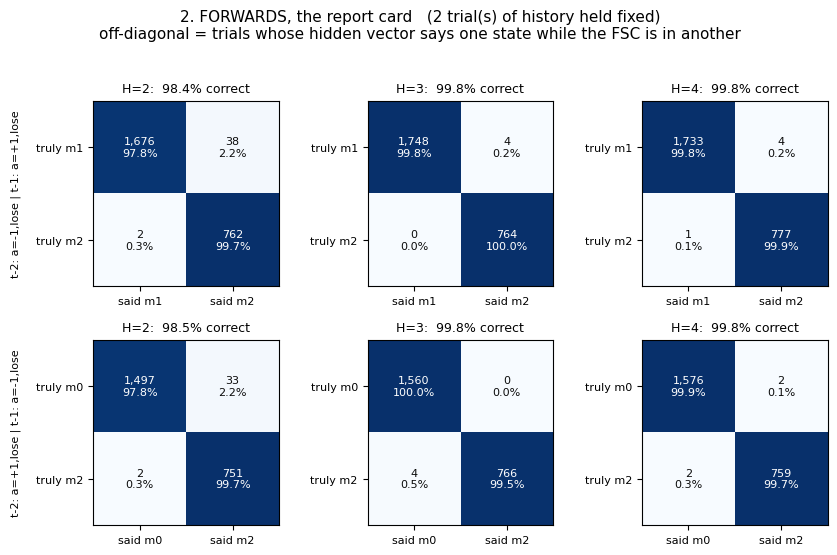

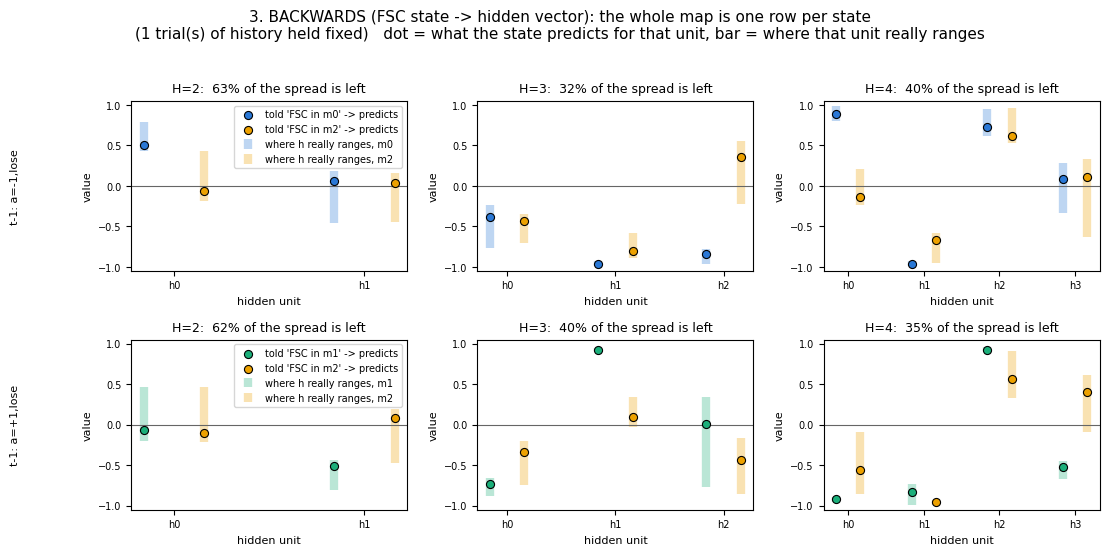

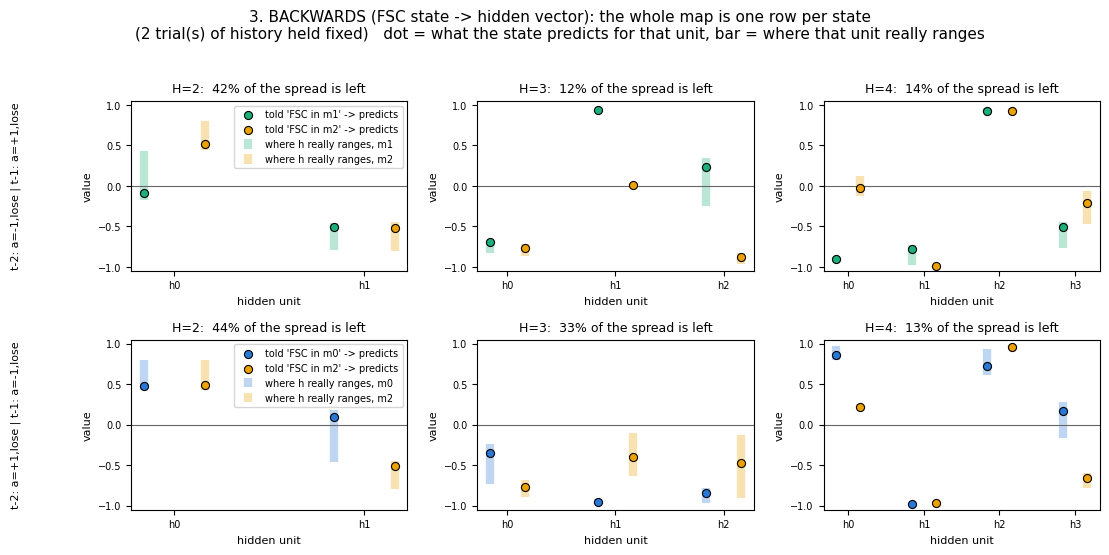

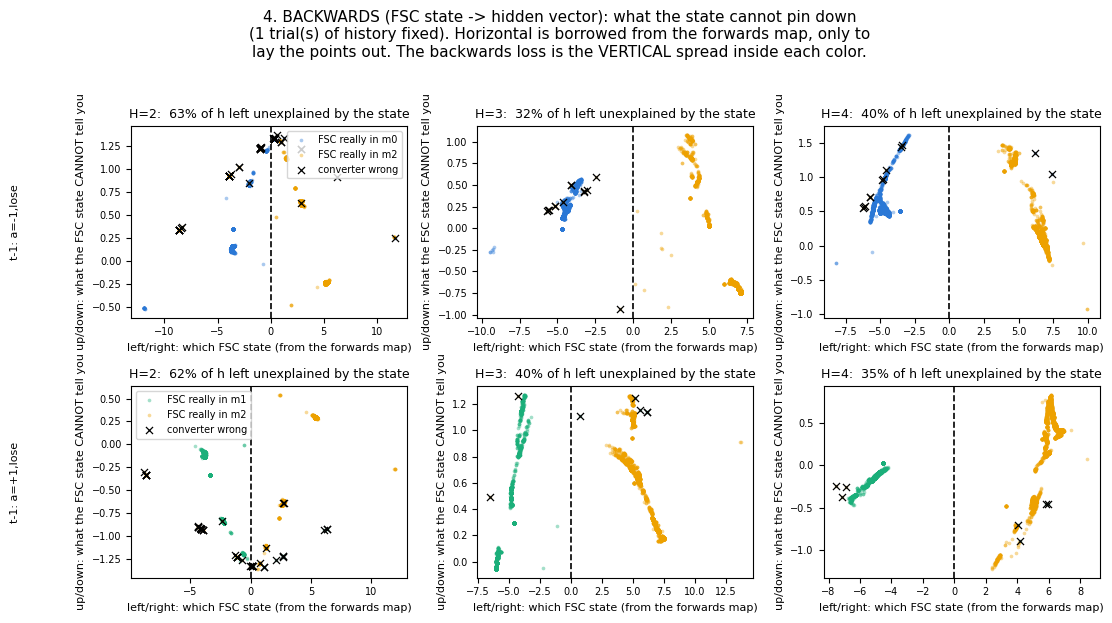

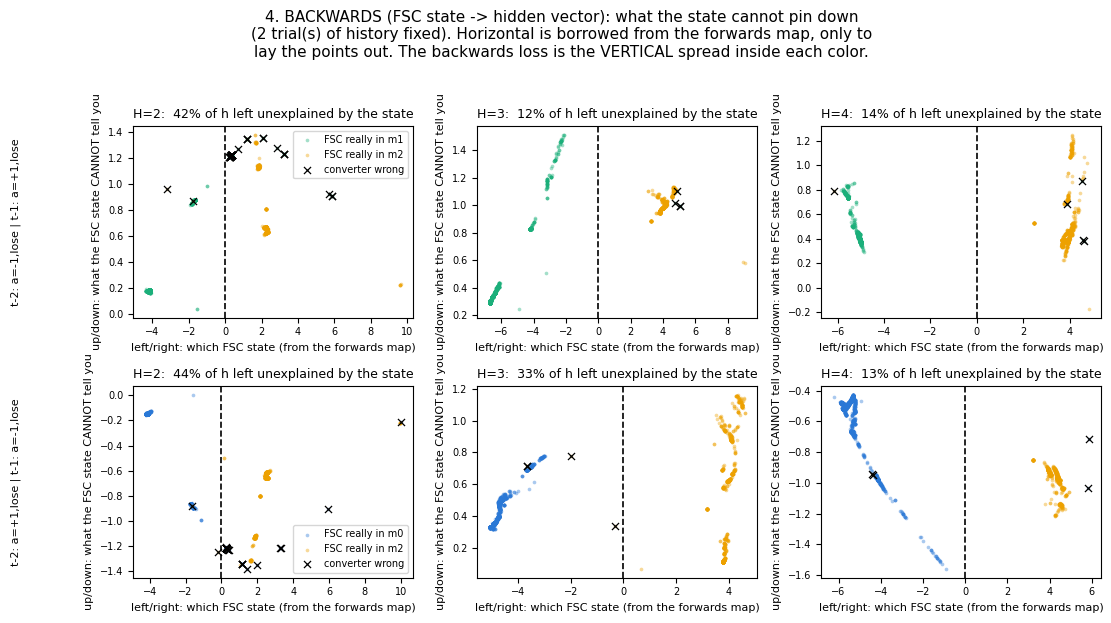


1 trial(s) of history fixed: the converter beats guessing in 6 of 6 (cell, size) combinations
   forwards  (hidden vector -> FSC state): 99.3% to 99.9% correct
   backwards (FSC state -> hidden vector): 32.5% to 62.5% of the hidden vector left unexplained

2 trial(s) of history fixed: the converter beats guessing in 6 of 6 (cell, size) combinations
   forwards  (hidden vector -> FSC state): 98.4% to 99.8% correct
   backwards (FSC state -> hidden vector): 12.4% to 43.6% of the hidden vector left unexplained

Both directions are run on the same held-out trials. Forwards is a classification, so it
is scored as 'how often correct'. Backwards is a reconstruction, so it is scored as 'how
much is left over'. The asymmetry is the result, not a flaw: the FSC's state is fully
present inside the RNN, and the RNN holds graded detail on top of it.


In [206]:
# --- 10.6b -- The converter: hidden vector <-> FSC state, one history cell at a time ----
# THIS IS THE OBJECT THE SECTION IS FOR. Not a score: an actual map you can apply. Given an
# RNN's hidden vector, which FSC memory state does it correspond to, and back the other way.
#
# It is fit and reported INSIDE a single history cell, never pooled. Pooled, the job is trivial
# and meaningless: win trials and lose trials sit far apart in hidden space and the FSC is in
# different states there, so anything scores ~0.99 by detecting "did it just win", which §10.3
# already showed by eye. Inside a cell every trial shares the same recent past, so that
# shortcut is gone and the map has to work off what the models remember from FURTHER back --
# the memory §10.4 showed the FSC keeps.
#
# Trials are matched between the models: the FSC's own belief filter is run over the RNN's OWN
# generated (action, observation) sequence, so "the FSC state" and "the hidden vector" describe
# the same trial of the same history. Fit on even sessions, every number below is from the odd
# ones. Splitting by session (not by trial) keeps neighbouring trials from leaking across.
from sklearn.linear_model import LogisticRegression, Ridge

STATE_COLORS = {0: PALETTE[0], 1: PALETTE[1], 2: PALETTE[2]}
MIN_PER_STATE = 100      # a state the FSC visits fewer times than this in a cell cannot be
                         # fit or scored on, so it is dropped and the cell is judged on the rest

def build_converters(H, k):
    """Fit one converter per history cell. Returns everything needed to SHOW the map, not just
    score it: the fitted rule, the held-out points, what it said, and what was true."""
    sess = gen[f"RNN H={H}"]
    B, Hh, grp, codes = [], [], [], []
    for i, s in enumerate(sess):
        b = decode_fsc_belief_states(best_fsc, s["actions"], s["observations"])[:-1]
        B.append(b.argmax(1)); Hh.append(s["hidden"]); grp.append(np.full(len(b), i))
        codes.append(history_codes(s["actions"], s["observations"], k))
    B = np.concatenate(B); Hh = np.concatenate(Hh)
    grp = np.concatenate(grp); codes = np.concatenate(codes)

    out = {}
    for c in np.unique(codes[codes >= 0]):
        sel = codes == c
        y, X, g = B[sel], Hh[sel], grp[sel]
        cls, cnt = np.unique(y, return_counts=True)
        keep = cls[cnt >= MIN_PER_STATE]
        room = np.isin(y, keep)
        y, X, g = y[room], X[room], g[room]
        tr, te = g % 2 == 0, g % 2 == 1
        if len(keep) < 2 or te.sum() == 0 or len(np.unique(y[tr])) < 2:
            out[int(c)] = dict(n=int(sel.sum()), states=cls, ok=False)
            continue
        with quiet_blas():
            clf = LogisticRegression(max_iter=2000).fit(X[tr], y[tr])
            said = clf.predict(X[te])
            # the reverse map: FSC state -> hidden vector. With one-hot input this is just
            # "the average hidden vector of that state", which is the best any 3-state machine
            # can do. What it misses is the leftover reported as `left`.
            oh = np.zeros((len(y), M_STAR)); oh[np.arange(len(y)), y] = 1.0
            back = Ridge(alpha=1e-3).fit(oh[tr], X[tr]).predict(oh[te])
        sse = ((X[te] - back) ** 2).sum(); sst = ((X[te] - X[te].mean(0)) ** 2).sum()
        out[int(c)] = dict(n=int(sel.sum()), states=keep, ok=True, clf=clf,
                           X=X[te], y=y[te], said=said, back=back,
                           acc=(said == y[te]).mean(),
                           chance=np.bincount(y[te]).max() / te.sum(),
                           left=float(sse / sst))
    return out

conv = {(k, H): build_converters(H, k) for k in (K1, K2) for H in GEN_SIZES}

def map_coords(d):
    """Put the held-out points on the axis the CONVERTER itself uses, at any H.
    Two classes -> one number, the decision score (0 is the boundary, sign is the answer).
    Three classes -> the 2D plane the three decision rules span."""
    W = d["clf"].coef_
    with quiet_blas():                       # Accelerate BLAS false alarms, as in §5.2
        if W.shape[0] == 1:
            return d["X"] @ W[0] + d["clf"].intercept_[0], None
        basis = np.linalg.svd(W - W.mean(0), full_matrices=False)[2][:2]
        return d["X"] @ basis[0], d["X"] @ basis[1]

# --- WHAT THE CONVERTER ACTUALLY IS ----------------------------------------------------
# For a cell with two FSC states the fitted rule is one line of arithmetic:
#
#       score = w . h + b          (w is a vector of H numbers, b is one number)
#       score < 0  ->  "the FSC is in the first state"
#       score > 0  ->  "the FSC is in the second state"
#
# So the converter is a single direction through hidden space. Sliding along that direction is
# what "changing FSC state" means to the RNN. The score is just how far along it a trial sits:
# the sign is the answer, the size is how far from the boundary. Nothing else is in the rule.
print("The converter, written out. score = w . h + b, and the sign of the score is the answer.\n")
for k in (K1, K2):
    for c in [c for c in conv[(k, GEN_SIZES[0])] if conv[(k, GEN_SIZES[0])][c]["ok"]]:
        print(f"  {code_label(c, k)}")
        for H in GEN_SIZES:
            d = conv[(k, H)][c]
            if not d["ok"]:
                print(f"     H={H}: one state too rare in this cell to fit"); continue
            if len(d["states"]) == 2:
                w = d["clf"].coef_[0]; b = d["clf"].intercept_[0]
                lo, hi = d["states"]
                terms = " + ".join(f"{w[u]:+.2f}*h{u}" for u in range(len(w)))
                print(f"     H={H}: score = {terms} {b:+.2f}      "
                      f"score<0 -> m{lo},  score>0 -> m{hi}")
            else:
                print(f"     H={H}: {len(d['states'])} states, so the rule is "
                      f"{len(d['states'])} such scores and the largest wins")
    print()

def split_axes(d):
    """The converter's own direction, and the biggest direction it does NOT use.
    Horizontal = what decides the FSC state. Vertical = what the FSC state cannot see."""
    W = d["clf"].coef_
    with quiet_blas():                        # Accelerate BLAS false alarms, as in §5.2
        if W.shape[0] == 1:
            u_dir = W[0] / np.linalg.norm(W[0])
            u = d["X"] @ W[0] + d["clf"].intercept_[0]
        else:
            basis = np.linalg.svd(W - W.mean(0), full_matrices=False)[2][:2]
            u_dir = basis[0]; u = d["X"] @ u_dir
        if d["X"].shape[1] < 2:
            return u, None
        Xr = d["X"] - np.outer(d["X"] @ u_dir, u_dir)          # strip the converter's direction
        v_dir = np.linalg.svd(Xr - Xr.mean(0), full_matrices=False)[2][0]
        return u, d["X"] @ v_dir

def cell_rows(k):
    return [c for c in conv[(k, GEN_SIZES[0])] if conv[(k, GEN_SIZES[0])][c]["ok"]]

def row_label(ax, text):
    ax.text(-0.42, 0.5, text, transform=ax.transAxes, rotation=90,
            va="center", ha="center", fontsize=8)

# --- FIGURE 1: does the converter separate the two states? ------------------------------
# Every held-out trial placed on its score, colored by the state the FSC is REALLY in. Two
# separated piles on opposite sides of the dashed line = the map works. Overlap across the
# line = the trials it gets wrong.
for k in (K1, K2):
    live = cell_rows(k)
    if not live:
        continue
    fig, axes = plt.subplots(len(live), len(GEN_SIZES),
                             figsize=(3.7 * len(GEN_SIZES), 2.6 * len(live)), squeeze=False)
    for r, c in enumerate(live):
        for cc, H in enumerate(GEN_SIZES):
            ax = axes[r, cc]; d = conv[(k, H)][c]
            if not d["ok"]:
                ax.text(0.5, 0.5, "one state too rare\nin this cell", ha="center", va="center",
                        fontsize=8, color="0.45", transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([]); continue
            u, _ = split_axes(d)
            bins = np.linspace(u.min(), u.max(), 60)
            for s in d["states"]:
                ax.hist(u[d["y"] == s], bins=bins, alpha=0.7, color=STATE_COLORS[s],
                        label=f"FSC really in m{s}")
            ax.axvline(0, color="k", lw=1.3, ls="--")
            ax.set_xlabel("converter's score", fontsize=8)
            ax.set_ylabel("trials", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.set_title(f"H={H}:  {d['acc']:.1%} right (guessing {d['chance']:.0%})", fontsize=9)
            if cc == 0:
                ax.legend(fontsize=7)
        row_label(axes[r, 0], code_label(c, k))
    fig.suptitle(f"1. FORWARDS (hidden vector -> FSC state): does the converter separate the states?   "
                 f"({k} trial(s) of history held fixed)\n"
                 f"each trial placed on its score; dashed line is the decision boundary",
                 y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()

# --- FIGURE 2: the report card -----------------------------------------------------------
# Rows are the state the FSC is really in, columns are what the converter said. Everything on
# the diagonal means the map is exact. Shading is the row percentage, so rows are comparable
# even when one state is far more common; the raw counts are printed inside.
for k in (K1, K2):
    live = cell_rows(k)
    if not live:
        continue
    fig, axes = plt.subplots(len(live), len(GEN_SIZES),
                             figsize=(2.9 * len(GEN_SIZES), 2.7 * len(live)), squeeze=False)
    for r, c in enumerate(live):
        for cc, H in enumerate(GEN_SIZES):
            ax = axes[r, cc]; d = conv[(k, H)][c]
            if not d["ok"]:
                ax.text(0.5, 0.5, "one state too rare\nin this cell", ha="center", va="center",
                        fontsize=8, color="0.45", transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([]); continue
            st = list(d["states"])
            cm = np.array([[int(((d["y"] == a) & (d["said"] == b)).sum()) for b in st] for a in st])
            pct = cm / cm.sum(axis=1, keepdims=True)
            ax.imshow(pct, cmap="Blues", vmin=0, vmax=1)
            for i in range(len(st)):
                for j in range(len(st)):
                    ax.text(j, i, f"{cm[i, j]:,}\n{pct[i, j]:.1%}", ha="center", va="center",
                            fontsize=8, color="white" if pct[i, j] > 0.5 else "#0b0b0b")
            ax.set_xticks(range(len(st))); ax.set_xticklabels([f"said m{s}" for s in st], fontsize=8)
            ax.set_yticks(range(len(st))); ax.set_yticklabels([f"truly m{s}" for s in st], fontsize=8)
            ax.set_title(f"H={H}:  {d['acc']:.1%} correct", fontsize=9)
        row_label(axes[r, 0], code_label(c, k))
    fig.suptitle(f"2. FORWARDS, the report card   ({k} trial(s) of history held fixed)\n"
                 f"off-diagonal = trials whose hidden vector says one state while the FSC is in another",
                 y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()

# --- FIGURE 3: the other direction, FSC state -> hidden vector --------------------------
# The backwards map has only M* possible inputs, so all it can output is one hidden vector per
# state: the average of that state's trials. Dots are what it predicts, per unit. The bars are
# where that unit's values ACTUALLY range (10th to 90th percentile) over the trials it is
# predicting. A dot with a short bar means the state pins that unit down. A dot with a long bar
# means the state gives you the average and nothing more, which is the sense in which the map
# is one-to-many going this way.
for k in (K1, K2):
    live = cell_rows(k)
    if not live:
        continue
    fig, axes = plt.subplots(len(live), len(GEN_SIZES),
                             figsize=(3.7 * len(GEN_SIZES), 2.7 * len(live)), squeeze=False)
    for r, c in enumerate(live):
        for cc, H in enumerate(GEN_SIZES):
            ax = axes[r, cc]; d = conv[(k, H)][c]
            if not d["ok"]:
                ax.text(0.5, 0.5, "one state too rare\nin this cell", ha="center", va="center",
                        fontsize=8, color="0.45", transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([]); continue
            off = np.linspace(-0.16, 0.16, len(d["states"]))
            for si, s_ in enumerate(d["states"]):
                m = d["y"] == s_
                pred = d["back"][m][0]                       # constant within a state
                lo, hi = np.percentile(d["X"][m], [10, 90], axis=0)
                x = np.arange(H) + off[si]
                ax.errorbar(x, pred, yerr=[pred - lo, hi - pred], fmt="none",
                            ecolor=STATE_COLORS[s_], elinewidth=6, alpha=0.3, capsize=0,
                            label=f"where h really ranges, m{s_}")
                ax.scatter(x, pred, s=34, color=STATE_COLORS[s_], edgecolor="k", linewidths=0.8,
                           zorder=5, label=f"told 'FSC in m{s_}' -> predicts")
            ax.axhline(0, color="0.4", lw=0.8)
            ax.set_xticks(range(H)); ax.set_xticklabels([f"h{u}" for u in range(H)], fontsize=8)
            ax.set_ylim(-1.05, 1.05); ax.tick_params(labelsize=7)
            ax.set_xlabel("hidden unit", fontsize=8)
            ax.set_ylabel("value", fontsize=8)
            ax.set_title(f"H={H}:  {d['left']:.0%} of the spread is left", fontsize=9)
            if cc == 0:
                ax.legend(fontsize=7)
        row_label(axes[r, 0], code_label(c, k))
    fig.suptitle(f"3. BACKWARDS (FSC state -> hidden vector): the whole map is one row per state\n"
                 f"({k} trial(s) of history held fixed)   "
                 f"dot = what the state predicts for that unit, bar = where that unit really ranges",
                 y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()

# --- FIGURE 4: the same trials, showing what the FSC state cannot express ---------------
# Horizontal is the converter's direction, so left and right are the two FSC states. Vertical
# is the largest direction the converter does NOT use. The colors separate left to right (the
# map works) and each color still spreads up and down (the FSC state does not fix where a
# trial sits on that axis). That vertical spread IS the "lossy going backwards" number.
for k in (K1, K2):
    live = cell_rows(k)
    if not live:
        continue
    fig, axes = plt.subplots(len(live), len(GEN_SIZES),
                             figsize=(3.7 * len(GEN_SIZES), 3.0 * len(live)), squeeze=False)
    for r, c in enumerate(live):
        for cc, H in enumerate(GEN_SIZES):
            ax = axes[r, cc]; d = conv[(k, H)][c]
            if not d["ok"] or d["X"].shape[1] < 2:
                ax.text(0.5, 0.5, "needs at least 2 units", ha="center", va="center",
                        fontsize=8, color="0.45", transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([]); continue
            u, v = split_axes(d)
            for s in d["states"]:
                m = d["y"] == s
                ax.scatter(u[m], v[m], s=7, alpha=0.4, linewidths=0, color=STATE_COLORS[s],
                           label=f"FSC really in m{s}")
            wrong = d["said"] != d["y"]
            ax.scatter(u[wrong], v[wrong], s=26, marker="x", color="k", linewidths=0.9,
                       label="converter wrong" if cc == 0 else None)
            ax.axvline(0, color="k", lw=1.2, ls="--")
            ax.set_xlabel("left/right: which FSC state (from the forwards map)", fontsize=8)
            ax.set_ylabel("up/down: what the FSC state CANNOT tell you", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.set_title(f"H={H}:  {d['left']:.0%} of h left unexplained by the state", fontsize=9)
            if cc == 0:
                ax.legend(fontsize=7)
        row_label(axes[r, 0], code_label(c, k))
    fig.suptitle(f"4. BACKWARDS (FSC state -> hidden vector): what the state cannot pin down\n"
                 f"({k} trial(s) of history fixed). Horizontal is borrowed from the forwards map, only to\n"
                 f"lay the points out. The backwards loss is the VERTICAL spread inside each color.",
                 y=1.03, fontsize=11)
    plt.tight_layout(); plt.show()

# --- THE VERDICT -------------------------------------------------------------------------
print("=" * 78)
for k in (K1, K2):
    live = cell_rows(k)
    tested = [(c, H) for c in live for H in GEN_SIZES if conv[(k, H)][c]["ok"]]
    works = [(c, H) for c, H in tested
             if conv[(k, H)][c]["acc"] > conv[(k, H)][c]["chance"] + 0.05]
    accs = [conv[(k, H)][c]["acc"] for c, H in works]
    lefts = [conv[(k, H)][c]["left"] for c, H in works]
    print(f"\n{k} trial(s) of history fixed: the converter beats guessing in {len(works)} of "
          f"{len(tested)} (cell, size) combinations")
    if accs:
        print(f"   forwards  (hidden vector -> FSC state): {min(accs):.1%} to {max(accs):.1%} correct")
        print(f"   backwards (FSC state -> hidden vector): {min(lefts):.1%} to {max(lefts):.1%} "
              f"of the hidden vector left unexplained")
    dead = [(c, H) for c, H in tested if (c, H) not in works]
    for c, H in dead:
        print(f"   no better than guessing: {code_label(c, k)}, H={H} "
              f"(that cell is {conv[(k, H)][c]['chance']:.0%} one state, so there was nothing to read)")
print("\nBoth directions are run on the same held-out trials. Forwards is a classification, so it\n"
      "is scored as 'how often correct'. Backwards is a reconstruction, so it is scored as 'how\n"
      "much is left over'. The asymmetry is the result, not a flaw: the FSC's state is fully\n"
      "present inside the RNN, and the RNN holds graded detail on top of it.")

### 10.7 What this section establishes

Read against the numbers printed above, not from expectation.

1. **The FSC's memory is a deterministic function of history** (§10.1b), so
   $P(m_t \mid \text{history cell})$ is spread only because one cell pools several deeper
   histories. One trial back leaves two of the four cells mixed; two trials back resolves most
   of it (§10.4).
2. **The converter works, with the recent history held fixed.** Inside a cell, a linear rule
   turns the hidden vector into the FSC's state at ~0.99 against a guessing rate near 0.65
   (§10.6b). The recent past cannot be doing that work, because it is identical for every trial
   in the cell. So the RNN carries the same deeper memory the FSC's state encodes.
3. **It holds at every size tested.** H = 2, 3 and 4 all convert, and the confusion matrices
   are near-diagonal for all three. The larger sizes are slightly cleaner, not different in
   kind.
4. **It is not the split an unsupervised method finds first.** k-means at $K = M^*$ matches the
   FSC's occupancy in most cells but disagrees outright in a few low-frequency loss cells
   (§10.6a). Both readings hold at once: the FSC's partition is *decodable* from the hidden
   state without being the direction of largest variance in it.
5. **The map is exact one way and lossy the other.** Knowing the FSC state pins down only part
   of the hidden vector even inside a single cell (the "loses X going back" figures). That
   leftover is graded information three discrete states have no slot for, and it is where the
   two models would be expected to diverge off-distribution, which is what §9.2 found.

The open piece is (5): what the leftover encodes. Trial-in-streak and recent win rate are the
obvious candidates, and §9.2's off-manifold probe is the way to test whether it matters
behaviorally.